In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Reshape, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from ctgan import CTGAN
from mpl_toolkits.mplot3d import Axes3D 
from scipy.linalg import sqrtm
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.impute import KNNImputer
from scipy import stats
import warnings
from sdv.single_table.ctgan import CTGAN
import os
import missingno as msno
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

pd.set_option("display.max_rows", None, "display.max_columns", 1000)

In [4]:
data = pd.read_csv("../data/raw/cirrhosis.csv")

data.head(5)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


# Univariate Analysis

### EDA Pre Imputation(EDA before handling of missing values)
--------------

This is the analysis done before the imputation of values for missing values


In [5]:
data_copy = data.copy()
data_copy.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [6]:
# Convert Age from number of dats to years
data_copy['Age'] = (data_copy['Age'] / 365.25).astype(int)
data_copy.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,58,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,56,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,70,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,54,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,38,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [7]:
# Drop ID column as it is not needed for analysis
# ID is a unique identifier and does not contribute to the analysis
data_copy.drop(columns=['ID'], inplace=True)
data_copy.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,58,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,56,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,70,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,54,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,38,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [8]:
data_copy.describe(include="all").T # Descriptive analysis for both numerical and categorical data

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
N_Days,418.0,NaN,NaN,NaN,1917.782297,1104.672992,41.0,1092.75,1730.0,2613.5,4795.0
Status,418,3,C,232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drug,312,2,D-penicillamine,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,418.0,NaN,NaN,NaN,50.294258,10.471934,26.0,42.0,51.0,58.0,78.0
Sex,418,2,F,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ascites,312,2,N,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hepatomegaly,312,2,Y,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Spiders,312,2,N,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edema,418,3,N,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bilirubin,418.0,NaN,NaN,NaN,3.220813,4.407506,0.3,0.8,1.4,3.4,28.0


In [9]:
data_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
N_Days,418.0,1917.782297,1104.672992,41.00,1092.7500,1730.00,2613.50,4795.00
Age,418.0,50.294258,10.471934,26.00,42.0000,51.00,58.00,78.00
Bilirubin,418.0,3.220813,4.407506,0.30,0.8000,1.40,3.40,28.00
Cholesterol,284.0,369.510563,231.944545,120.00,249.5000,309.50,400.00,1775.00
Albumin,418.0,3.497440,0.424972,1.96,3.2425,3.53,3.77,4.64
Copper,310.0,97.648387,85.613920,4.00,41.2500,73.00,123.00,588.00
Alk_Phos,312.0,1982.655769,2140.388824,289.00,871.5000,1259.00,1980.00,13862.40
SGOT,312.0,122.556346,56.699525,26.35,80.6000,114.70,151.90,457.25
Tryglicerides,282.0,124.702128,65.148639,33.00,84.2500,108.00,151.00,598.00
Platelets,407.0,257.024570,98.325585,62.00,188.5000,251.00,318.00,721.00


In [10]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         418 non-null    int64  
 1   Status         418 non-null    object 
 2   Drug           312 non-null    object 
 3   Age            418 non-null    int64  
 4   Sex            418 non-null    object 
 5   Ascites        312 non-null    object 
 6   Hepatomegaly   312 non-null    object 
 7   Spiders        312 non-null    object 
 8   Edema          418 non-null    object 
 9   Bilirubin      418 non-null    float64
 10  Cholesterol    284 non-null    float64
 11  Albumin        418 non-null    float64
 12  Copper         310 non-null    float64
 13  Alk_Phos       312 non-null    float64
 14  SGOT           312 non-null    float64
 15  Tryglicerides  282 non-null    float64
 16  Platelets      407 non-null    float64
 17  Prothrombin    416 non-null    float64
 18  Stage     

In [11]:
df_num = data_copy.select_dtypes(include=['int64', 'float64'])
df_num.head()



,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,58,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,56,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,70,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,54,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,38,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


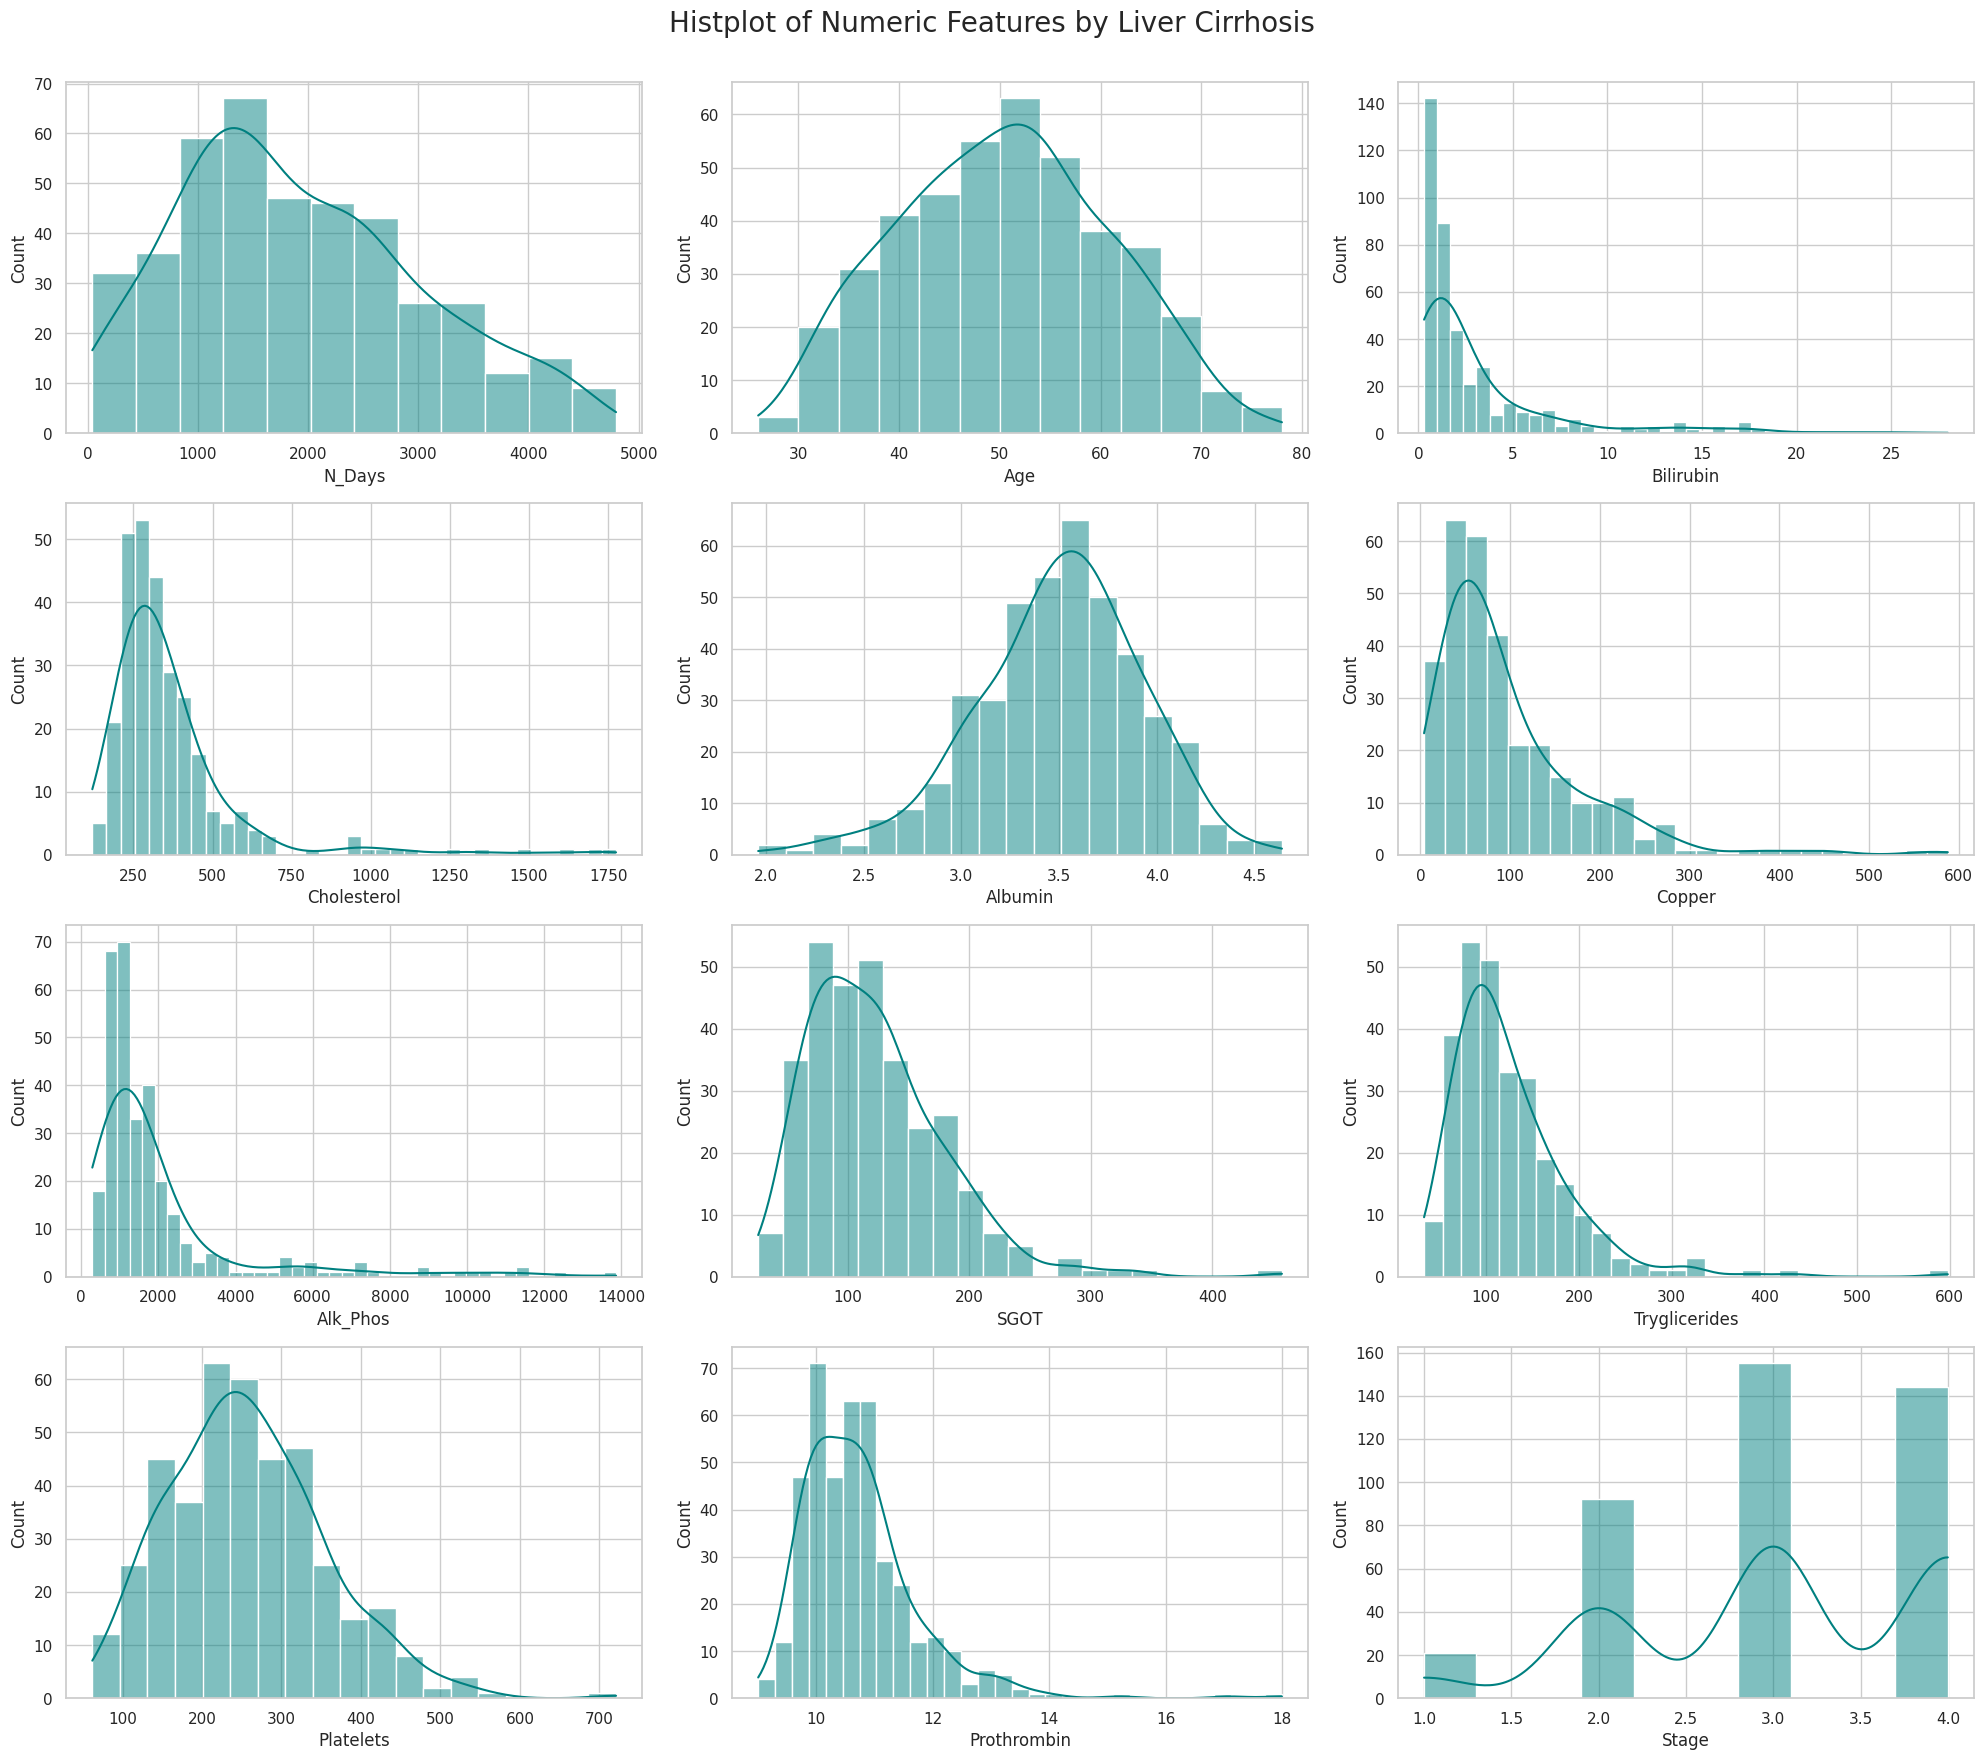

In [12]:
# Plot Histograms of numeric features
plt.figure(figsize=(20, 25))
for i, col in enumerate(df_num):
    plt.subplot(6, 3, i + 1)
    sns.histplot(data=df_num, x=col, palette='viridis', color=(0, 0.5, 0.5), kde=True)
    # plt.title(f'{col} by Stage')
    plt.tight_layout()

plt.suptitle('Histplot of Numeric Features by Liver Cirrhosis', fontsize=20, y=1.02)
plt.show()

In [13]:
cat_df = data_copy.select_dtypes(include=['object'])
cat_df.head()


,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema
0,D,D-penicillamine,F,Y,Y,Y,Y
1,C,D-penicillamine,F,N,Y,Y,N
2,D,D-penicillamine,M,N,N,N,S
3,D,D-penicillamine,F,N,Y,Y,S
4,CL,Placebo,F,N,Y,Y,N


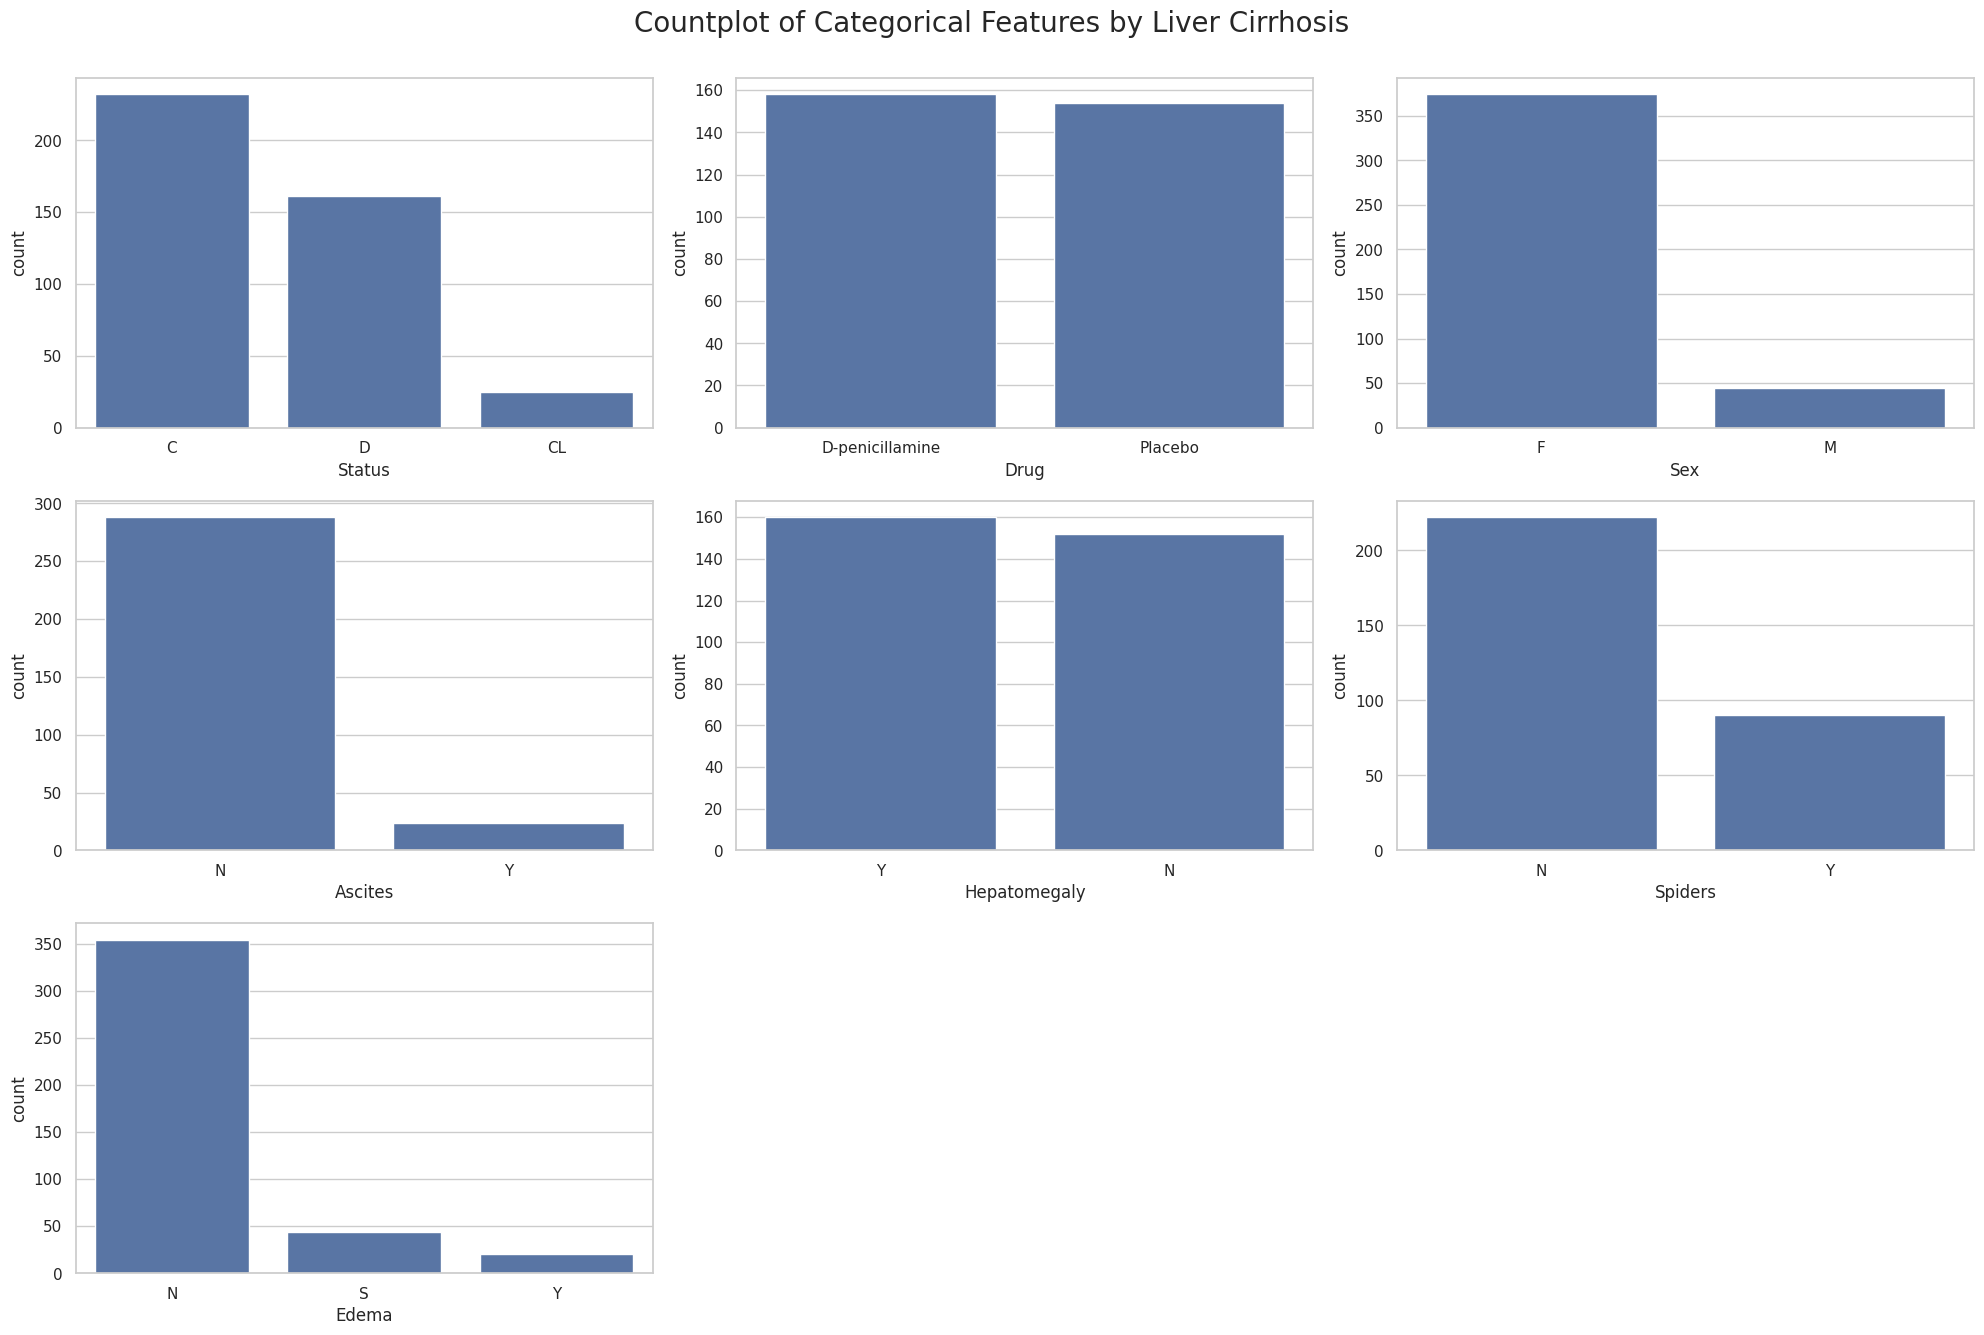

In [14]:
# Bar plot of categorical features
plt.figure(figsize=(20, 25))
for i, col in enumerate(cat_df):
    plt.subplot(6, 3, i + 1)
    sns.countplot(data=cat_df, x=col, order=cat_df[col].value_counts().index)
    # plt.title(f'{col} by Stage')
    plt.tight_layout()

plt.suptitle('Countplot of Categorical Features by Liver Cirrhosis', fontsize=20, y=1.02)
plt.show()

## Working with missingness
1. Pattern of Missing Values
To identify the type of missingness, we first check if missing values occur together or independently. A key observation is that 106 rows have missing values in Drug, Ascites, Hepatomegaly, Spiders, Edema, and Stage simultaneously. Let’s confirm this by analyzing the dataset.

<Axes: >

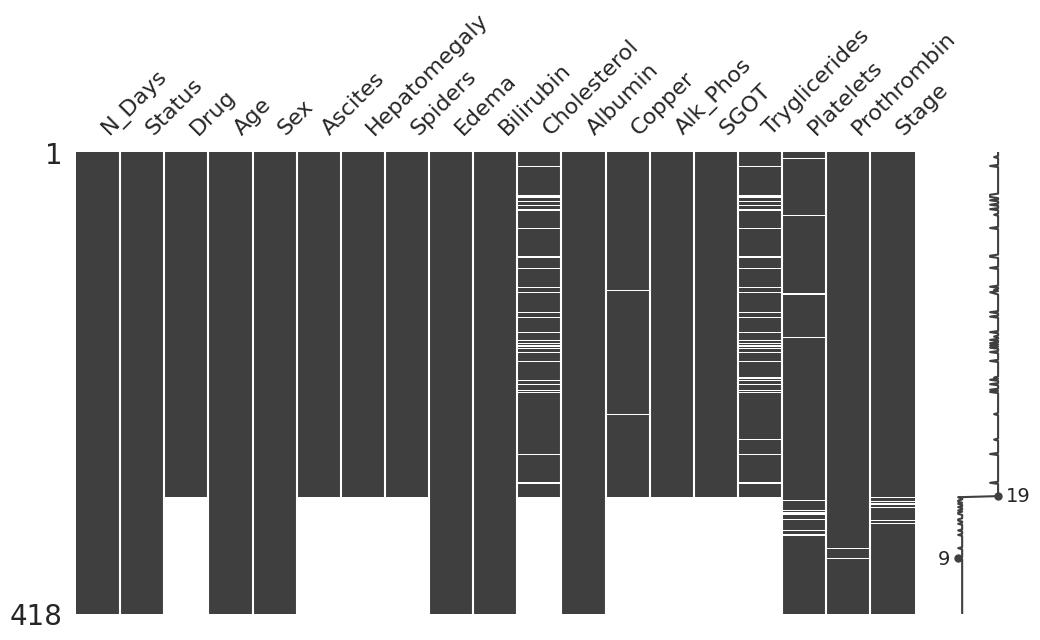

In [15]:
# Visualization of missing data
msno.matrix(data_copy, figsize=(12, 6))

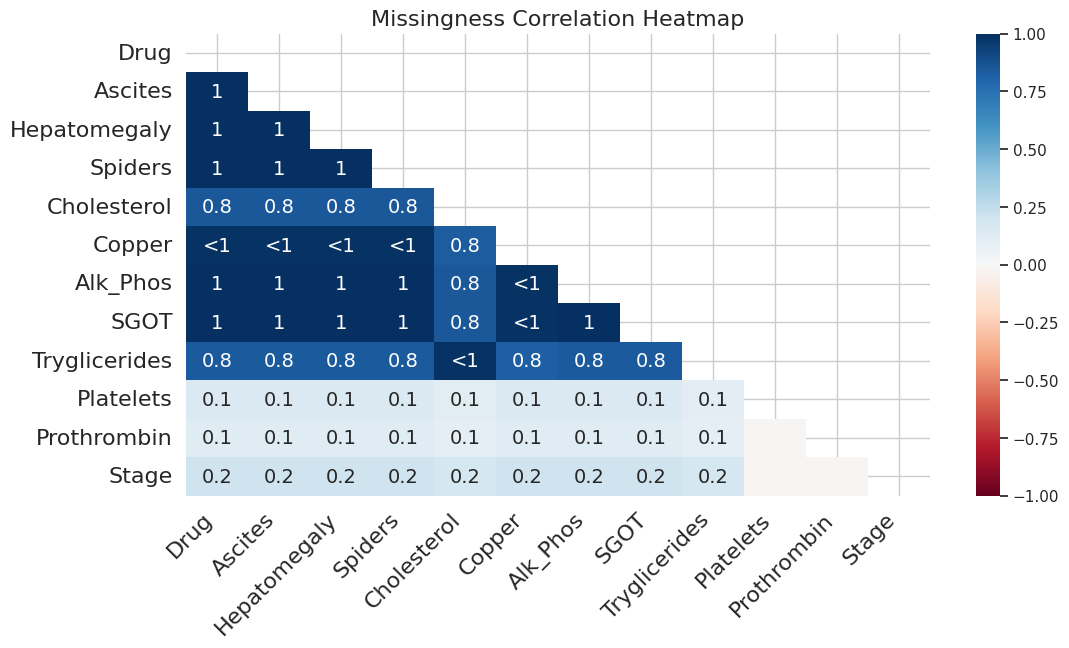

In [16]:
msno.heatmap(data_copy, figsize=(12, 6))
plt.title("Missingness Correlation Heatmap", fontsize=16);

#### 1. Missingness in Drug, Ascites, Hepatomegaly, Spiders, Copper, Alk_Phos, SGOT (106 rows missing all)

In [17]:
df_missingness = data.copy()

# Replace 'NA' with None for proper handling
df_missingness = df_missingness.replace('NA', None)

# Check rows where all specified columns are missing
missing_cols = ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']
rows_missing_all = df_missingness[missing_cols].isnull().all(axis=1)
print(f"Number of rows with all {missing_cols} missing: {rows_missing_all.sum()}")

Number of rows with all ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage'] missing: 0


In [18]:
# Replace 'NA' with None for proper handling
df = df_missingness.replace('NA', None)

# Check missing values in each column
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64


In [19]:
# Replace 'NA' with None for proper handling
df = df_missingness.replace('NA', None)

# Check rows where specific columns are missing together
missing_cols = ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Copper', 'Alk_Phos', 'SGOT']
rows_missing_all = df[missing_cols].isnull().all(axis=1)
print(f"Number of rows with all {missing_cols} missing: {rows_missing_all.sum()}")

# Check rows with at least one missing value in these columns
rows_missing_any = df[missing_cols].isnull().any(axis=1)
print(f"Number of rows with at least one missing value in {missing_cols}: {rows_missing_any.sum()}")

# Check if Stage missingness overlaps with these columns
rows_missing_stage = df['Stage'].isnull()
overlap_stage = df[rows_missing_stage & rows_missing_any].shape[0]
print(f"Number of rows with missing Stage and missing {missing_cols}: {overlap_stage}")

# Check missingness patterns
missing_pattern = df[missing_cols + ['Stage', 'Cholesterol', 'Tryglicerides']].isnull()
print("\nMissing Value Patterns (first 10 rows):")
print(missing_pattern.head(10))
print("\nCount of rows by number of missing columns:")
print(missing_pattern.sum(axis=1).value_counts())

Number of rows with all ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Copper', 'Alk_Phos', 'SGOT'] missing: 106
Number of rows with at least one missing value in ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Copper', 'Alk_Phos', 'SGOT']: 108
Number of rows with missing Stage and missing ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Copper', 'Alk_Phos', 'SGOT']: 6

Missing Value Patterns (first 10 rows):
    Drug  Ascites  Hepatomegaly  Spiders  Copper  Alk_Phos   SGOT  Stage  \
0  False    False         False    False   False     False  False  False   
1  False    False         False    False   False     False  False  False   
2  False    False         False    False   False     False  False  False   
3  False    False         False    False   False     False  False  False   
4  False    False         False    False   False     False  False  False   
5  False    False         False    False   False     False  False  False   
6  False    False         False    False   False     Fa

In [20]:
# Compare Bilirubin and Status in rows with/without missing Drug
rows_missing_block = df[missing_cols].isnull().all(axis=1)
print("Mean Bilirubin for missing block:", df[rows_missing_block]['Bilirubin'].mean())
print("Mean Bilirubin for non-missing block:", df[~rows_missing_block]['Bilirubin'].mean())
print("\nStatus distribution for missing block:")
print(df[rows_missing_block]['Status'].value_counts())
print("\nStatus distribution for non-missing block:")
print(df[~rows_missing_block]['Status'].value_counts())

Mean Bilirubin for missing block: 3.1169811320754715
Mean Bilirubin for non-missing block: 3.256089743589744

Status distribution for missing block:
Status
C     64
D     36
CL     6
Name: count, dtype: int64

Status distribution for non-missing block:
Status
C     168
D     125
CL     19
Name: count, dtype: int64


In [21]:
print("Mean Age for missing block:", df[rows_missing_block]['Age'].mean())
print("Mean Age for non-missing block:", df[~rows_missing_block]['Age'].mean())

Mean Age for missing block: 19310.14150943396
Mean Age for non-missing block: 18269.44230769231


### 2. Missingness in ```Stage``` (6 rows missing)
Higher Bilirubin or more Status=D in these 6 rows would confirm MNAR.


In [22]:
print("Mean Bilirubin for missing Stage:", df[df['Stage'].isnull()]['Bilirubin'].mean())
print("Mean Bilirubin for non-missing Stage:", df[df['Stage'].notnull()]['Bilirubin'].mean())
print("\nStatus distribution for missing Stage:")
print(df[df['Stage'].isnull()]['Status'].value_counts())

Mean Bilirubin for missing Stage: 2.75
Mean Bilirubin for non-missing Stage: 3.2276699029126217

Status distribution for missing Stage:
Status
D    4
C    2
Name: count, dtype: int64


### 3. Missingness in Cholesterol (134) and Tryglicerides (136)


In [23]:
print("Mean Age for missing Tryglicerides:", df[df['Tryglicerides'].isnull()]['Age'].mean())
print("Mean Age for non-missing Tryglicerides:", df[df['Tryglicerides'].notnull()]['Age'].mean())

Mean Age for missing Tryglicerides: 19130.117647058825
Mean Age for non-missing Tryglicerides: 18245.54964539007


# Bivariate Analysis

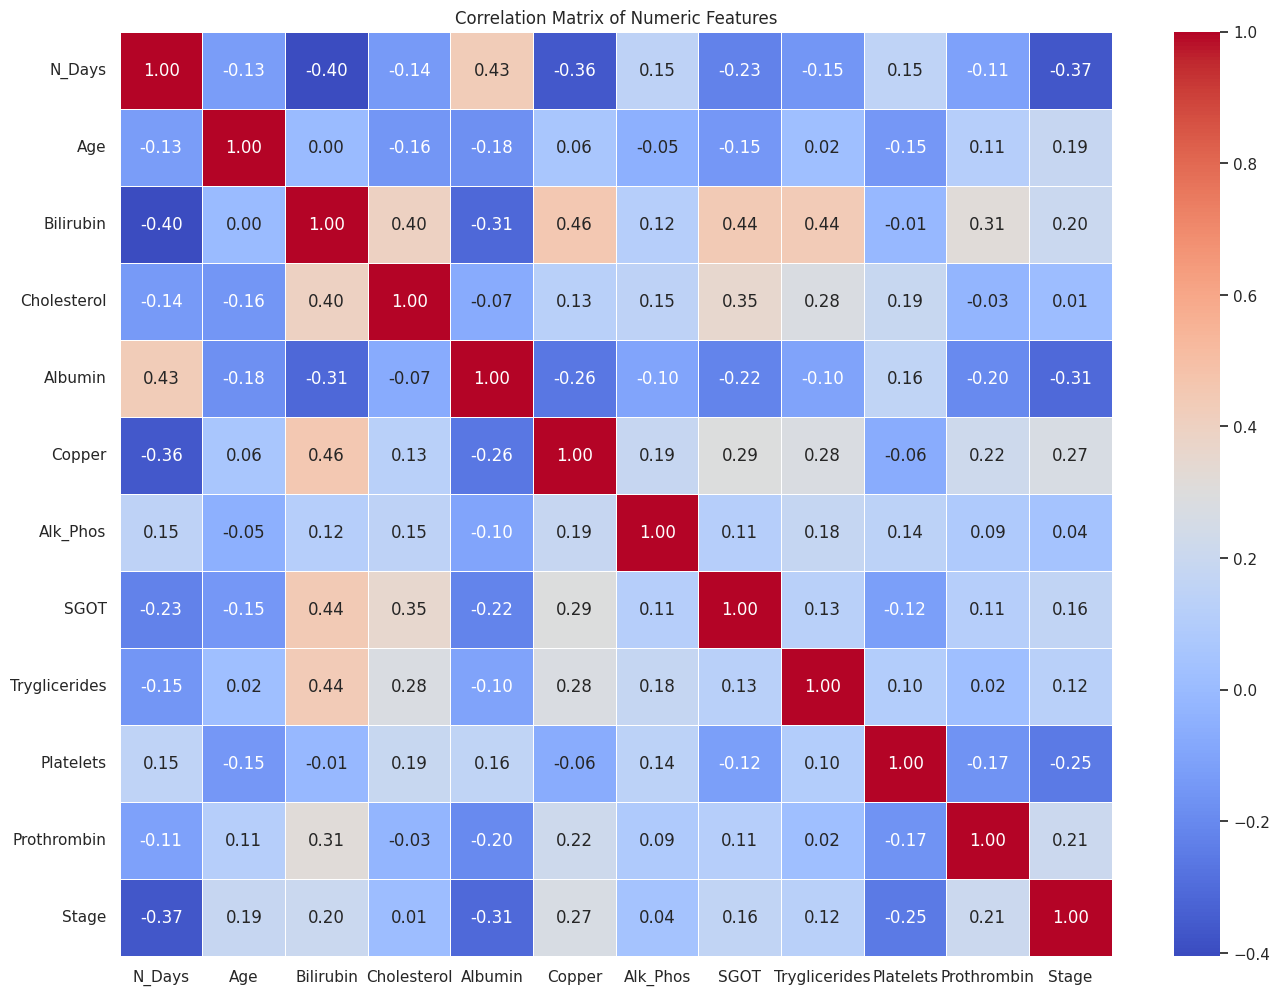

In [24]:
# Compute the correlation matrix for numeric columns
plt.figure(figsize=(16, 12))
corr = df_num.corr()

# Create a heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [25]:
corr

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
N_Days,1.000000,-0.126868,-0.403953,-0.138236,0.430829,-0.364809,0.149269,-0.225492,-0.153000,0.151361,-0.111470,-0.366193
Age,-0.126868,1.000000,0.000246,-0.155939,-0.178980,0.059867,-0.049337,-0.150934,0.021122,-0.147654,0.113684,0.186208
Bilirubin,-0.403953,0.000246,1.000000,0.397129,-0.314177,0.456918,0.116984,0.441730,0.436748,-0.013435,0.314894,0.200731
Cholesterol,-0.138236,-0.155939,0.397129,1.000000,-0.069733,0.126115,0.149473,0.353246,0.276830,0.191710,-0.030811,0.011164
Albumin,0.430829,-0.178980,-0.314177,-0.069733,1.000000,-0.264771,-0.101456,-0.220047,-0.103417,0.158659,-0.200592,-0.305296
Copper,-0.364809,0.059867,0.456918,0.126115,-0.264771,1.000000,0.187357,0.293829,0.279852,-0.064403,0.218224,0.269400
Alk_Phos,0.149269,-0.049337,0.116984,0.149473,-0.101456,0.187357,1.000000,0.112217,0.180082,0.143733,0.089384,0.041273
SGOT,-0.225492,-0.150934,0.441730,0.353246,-0.220047,0.293829,0.112217,1.000000,0.126119,-0.120147,0.112174,0.164945
Tryglicerides,-0.153000,0.021122,0.436748,0.276830,-0.103417,0.279852,0.180082,0.126119,1.000000,0.103212,0.020122,0.123899
Platelets,0.151361,-0.147654,-0.013435,0.191710,0.158659,-0.064403,0.143733,-0.120147,0.103212,1.000000,-0.167331,-0.253523


In [26]:
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


# 3D plots for pre missing data analysis

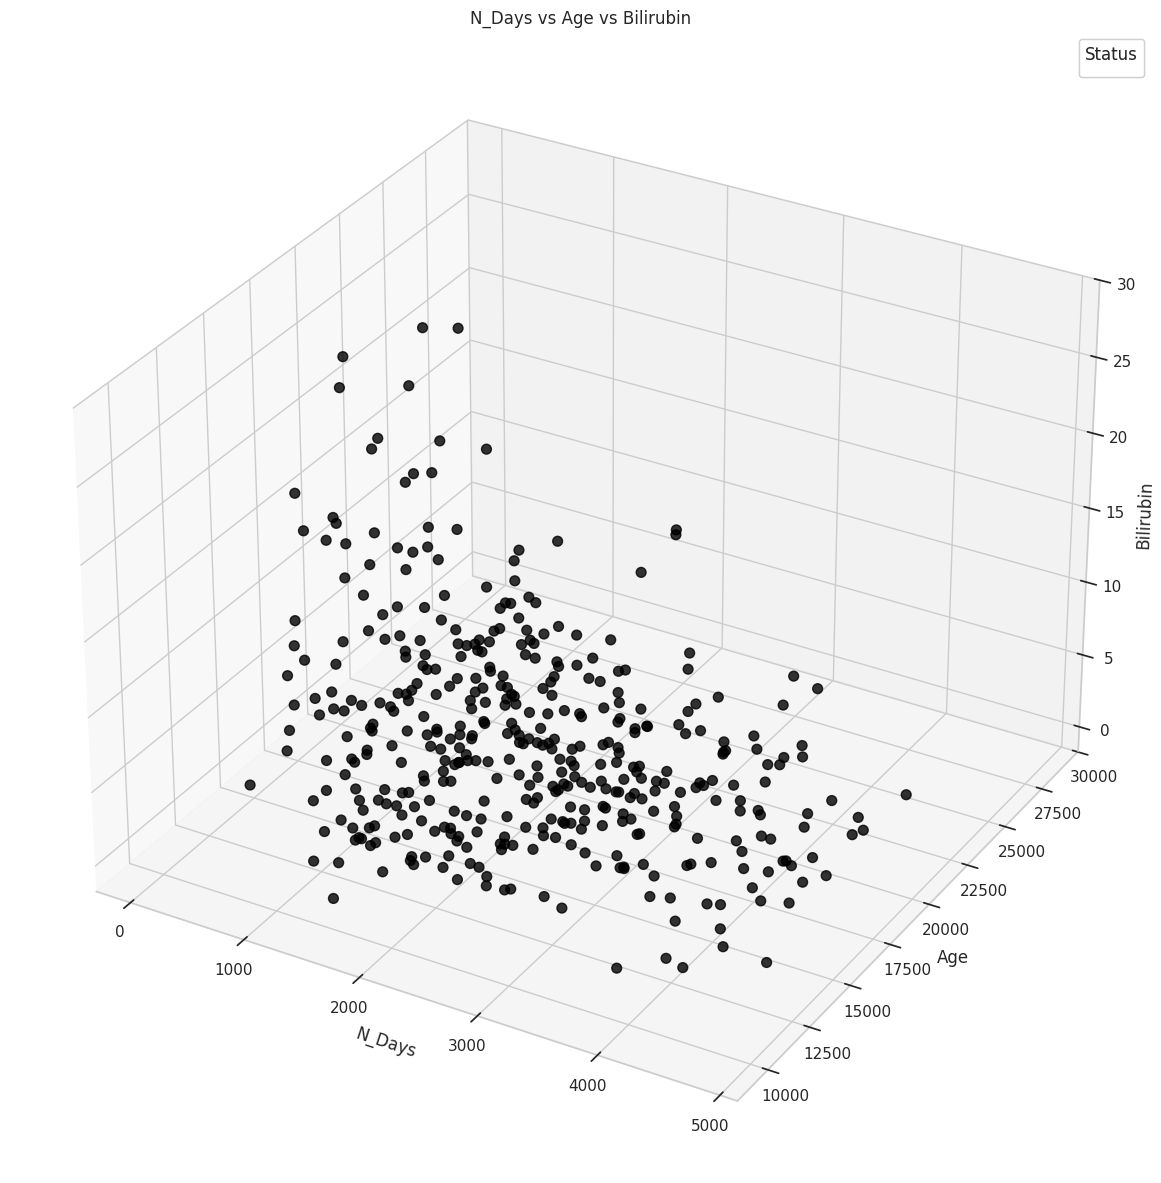

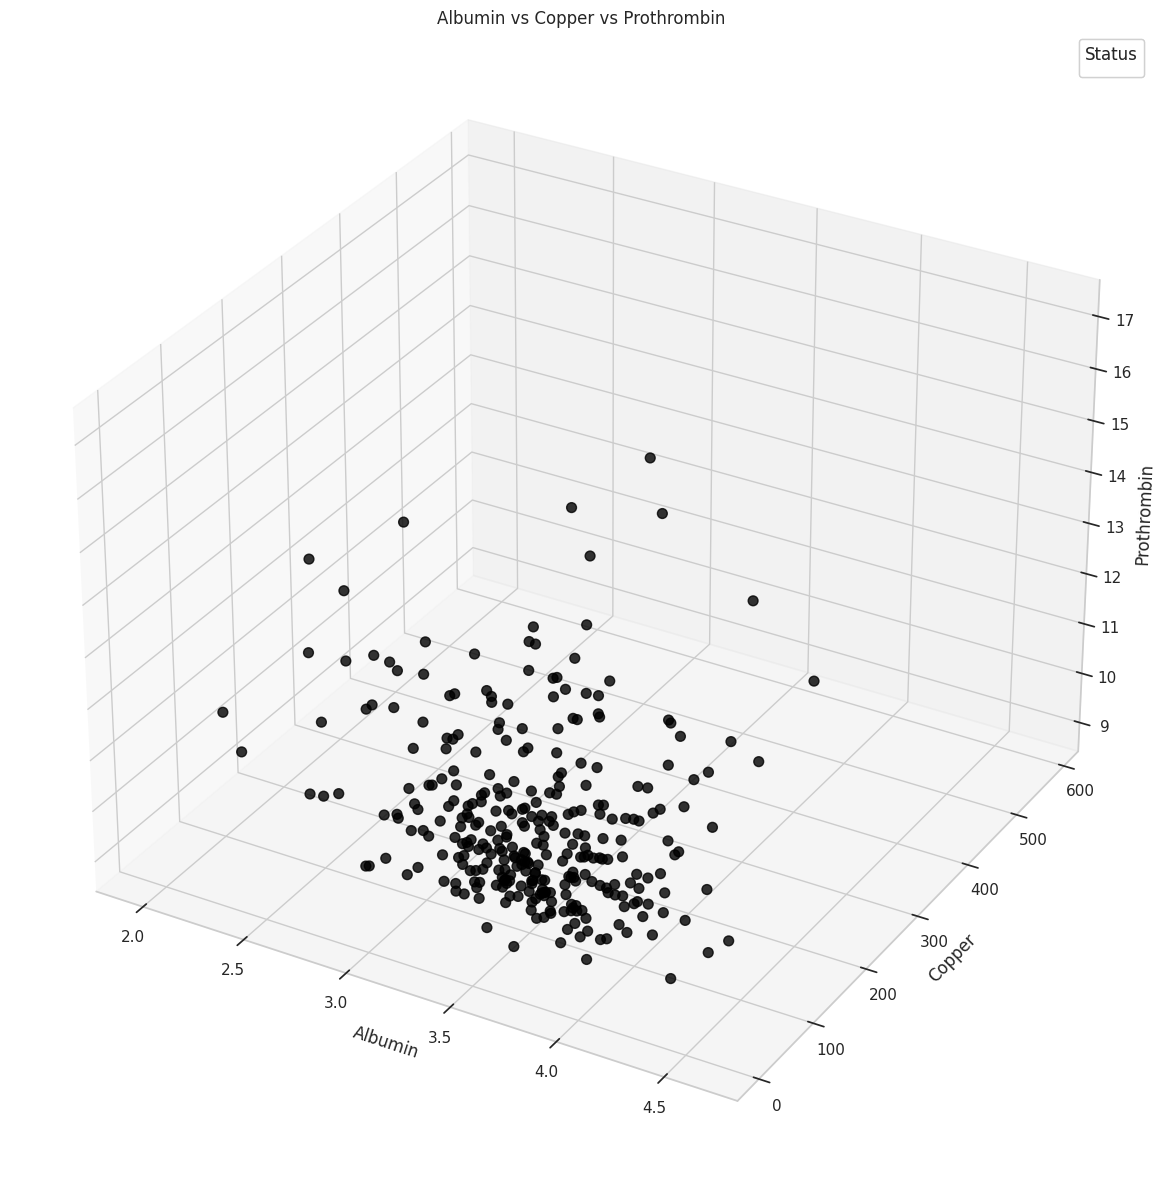

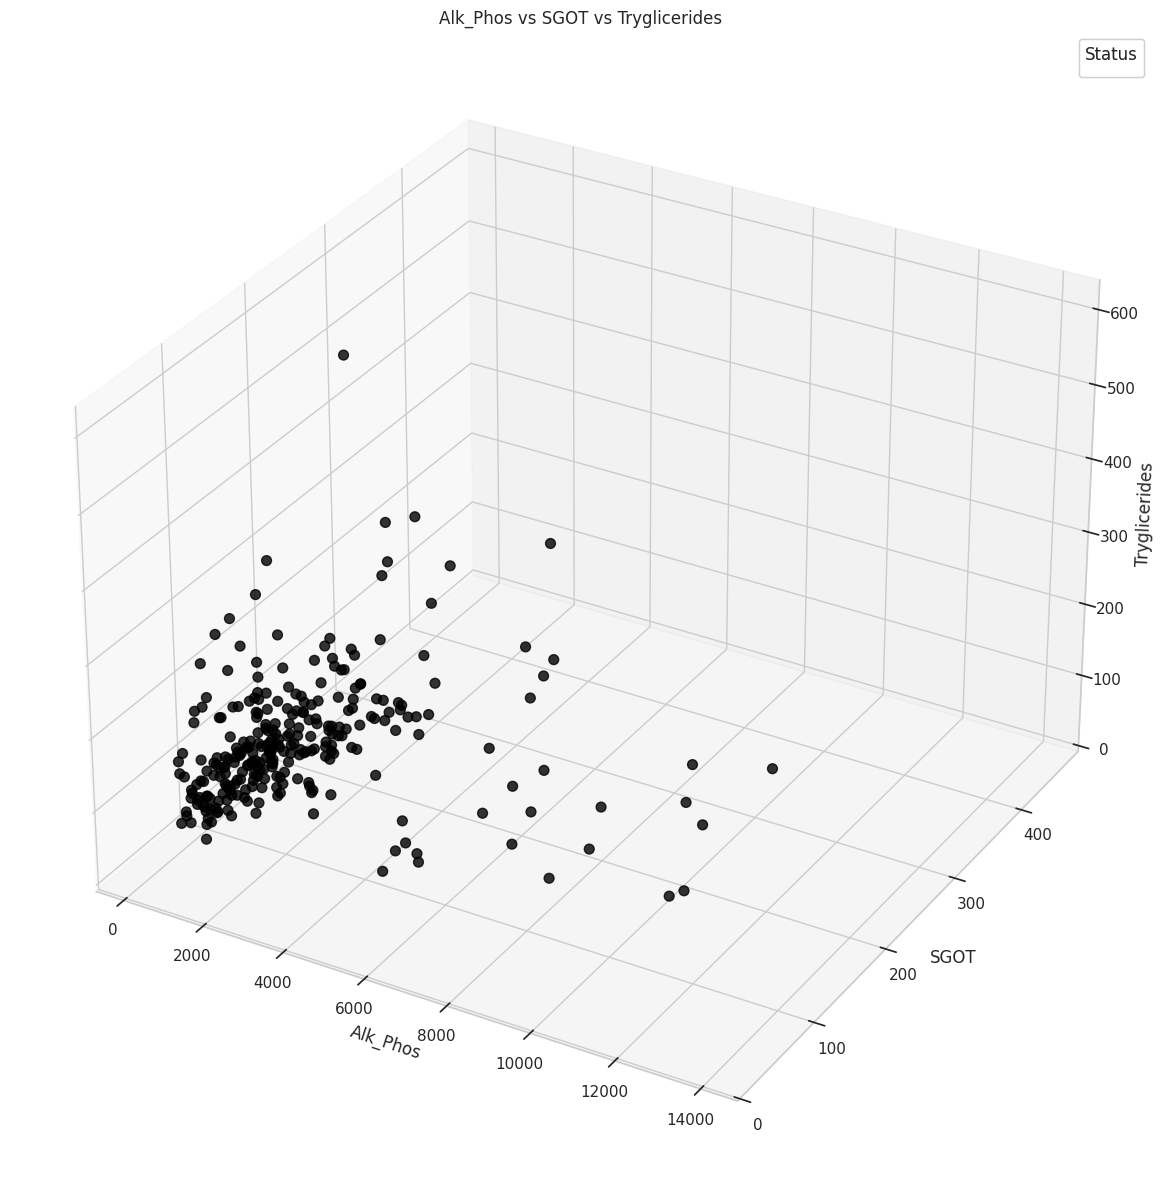

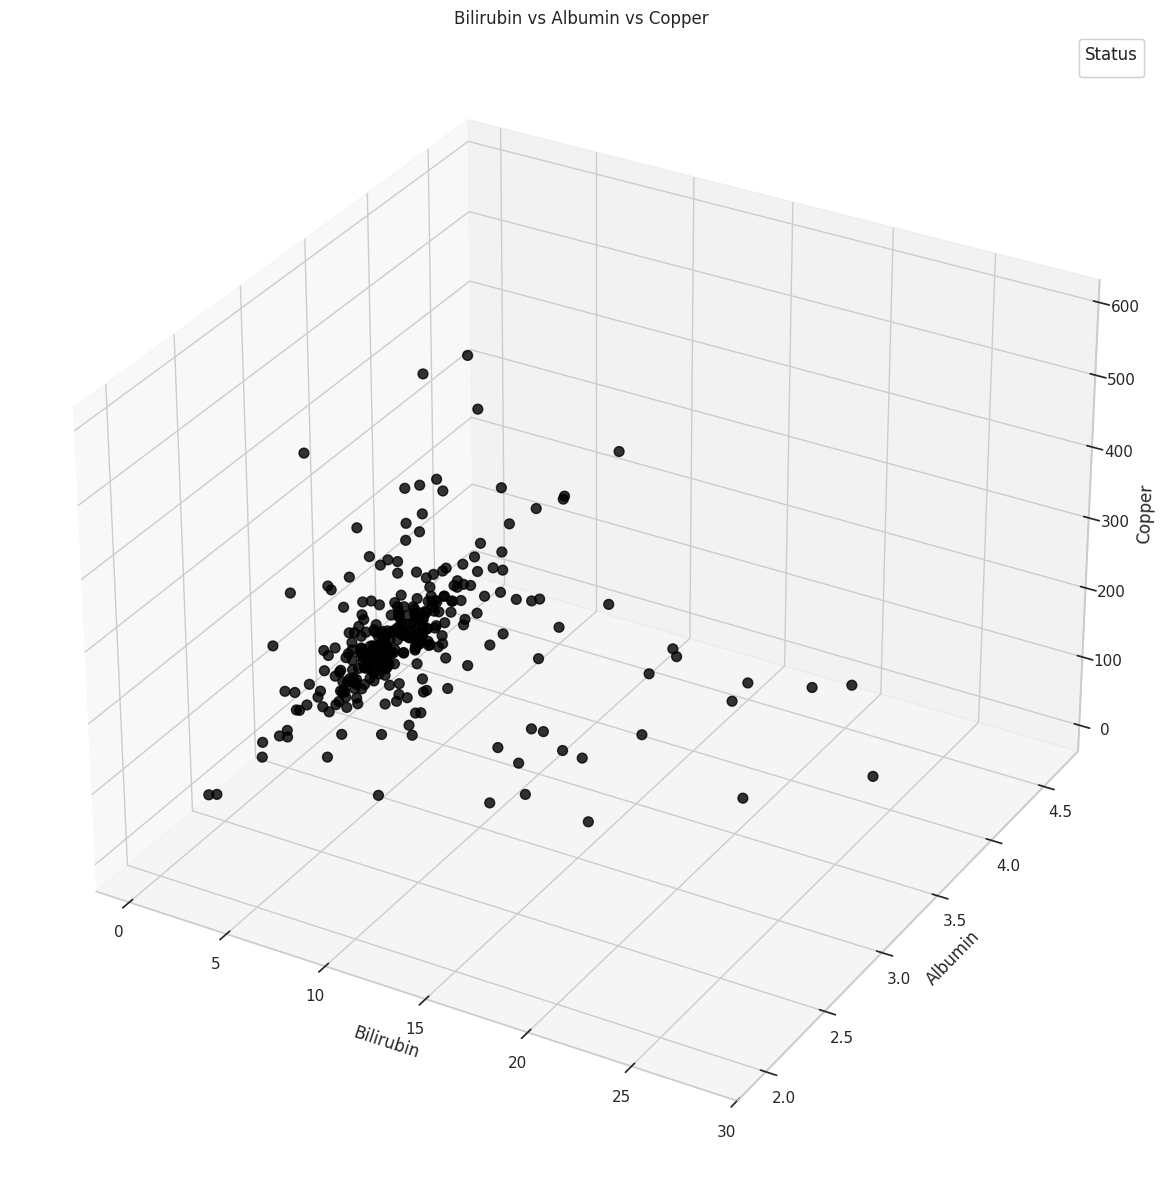

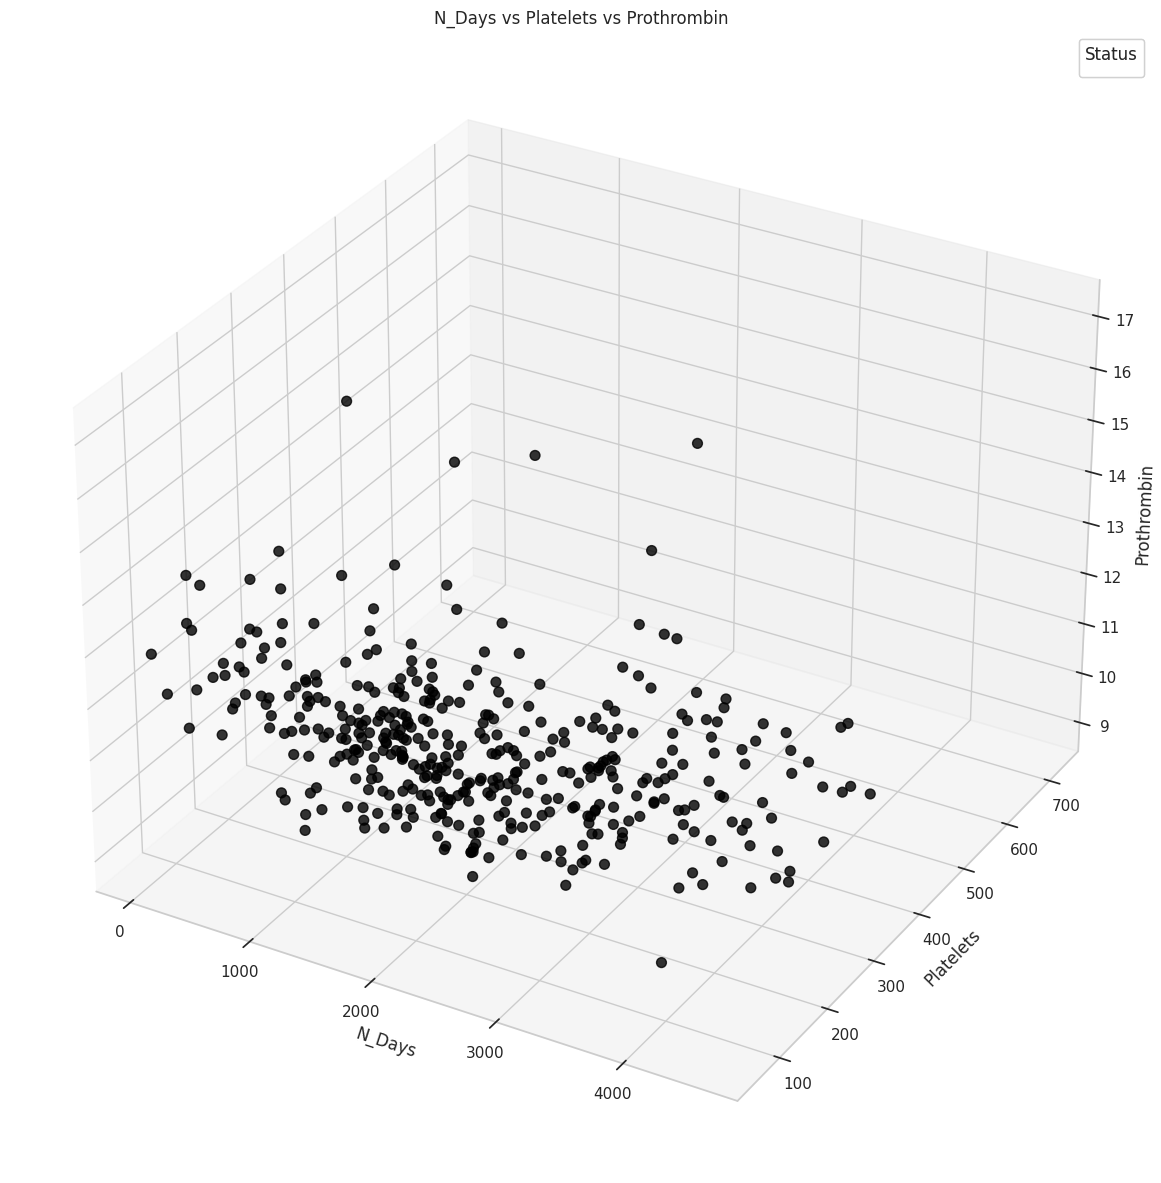

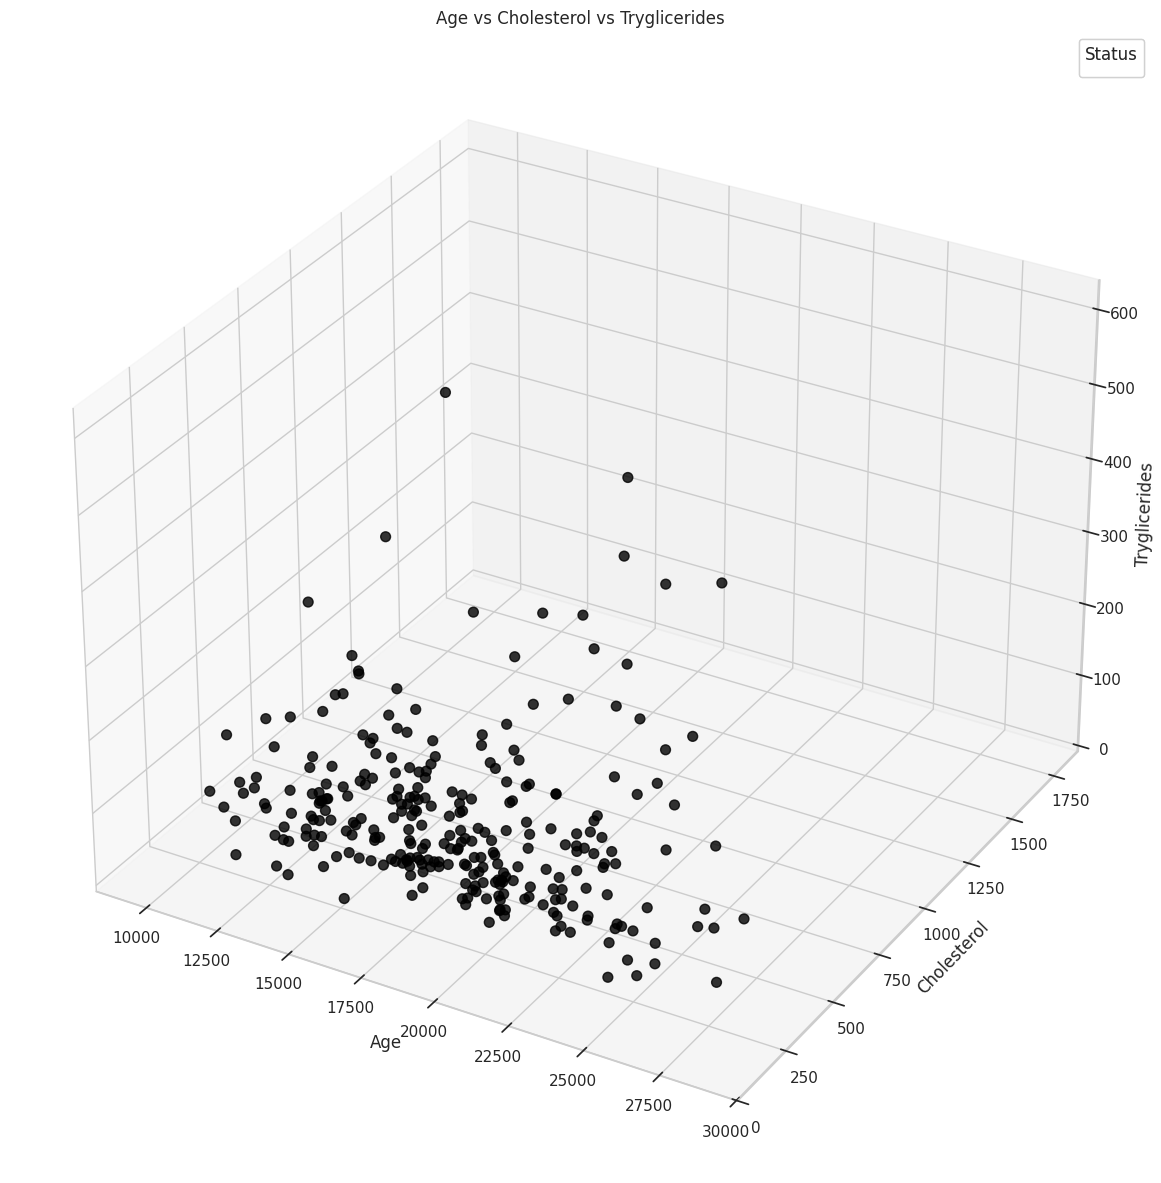

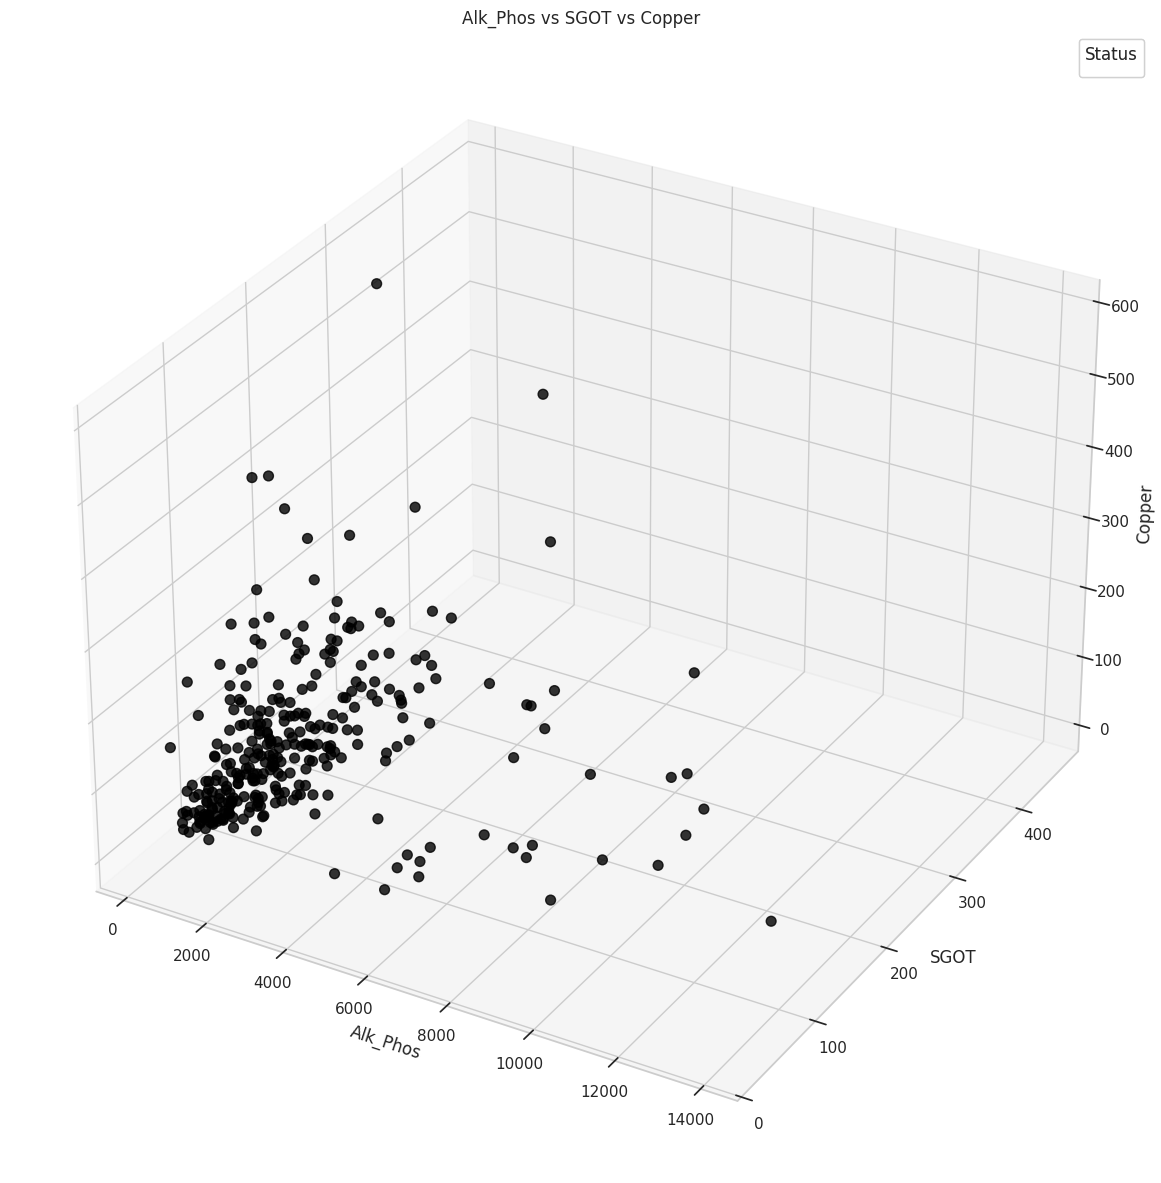

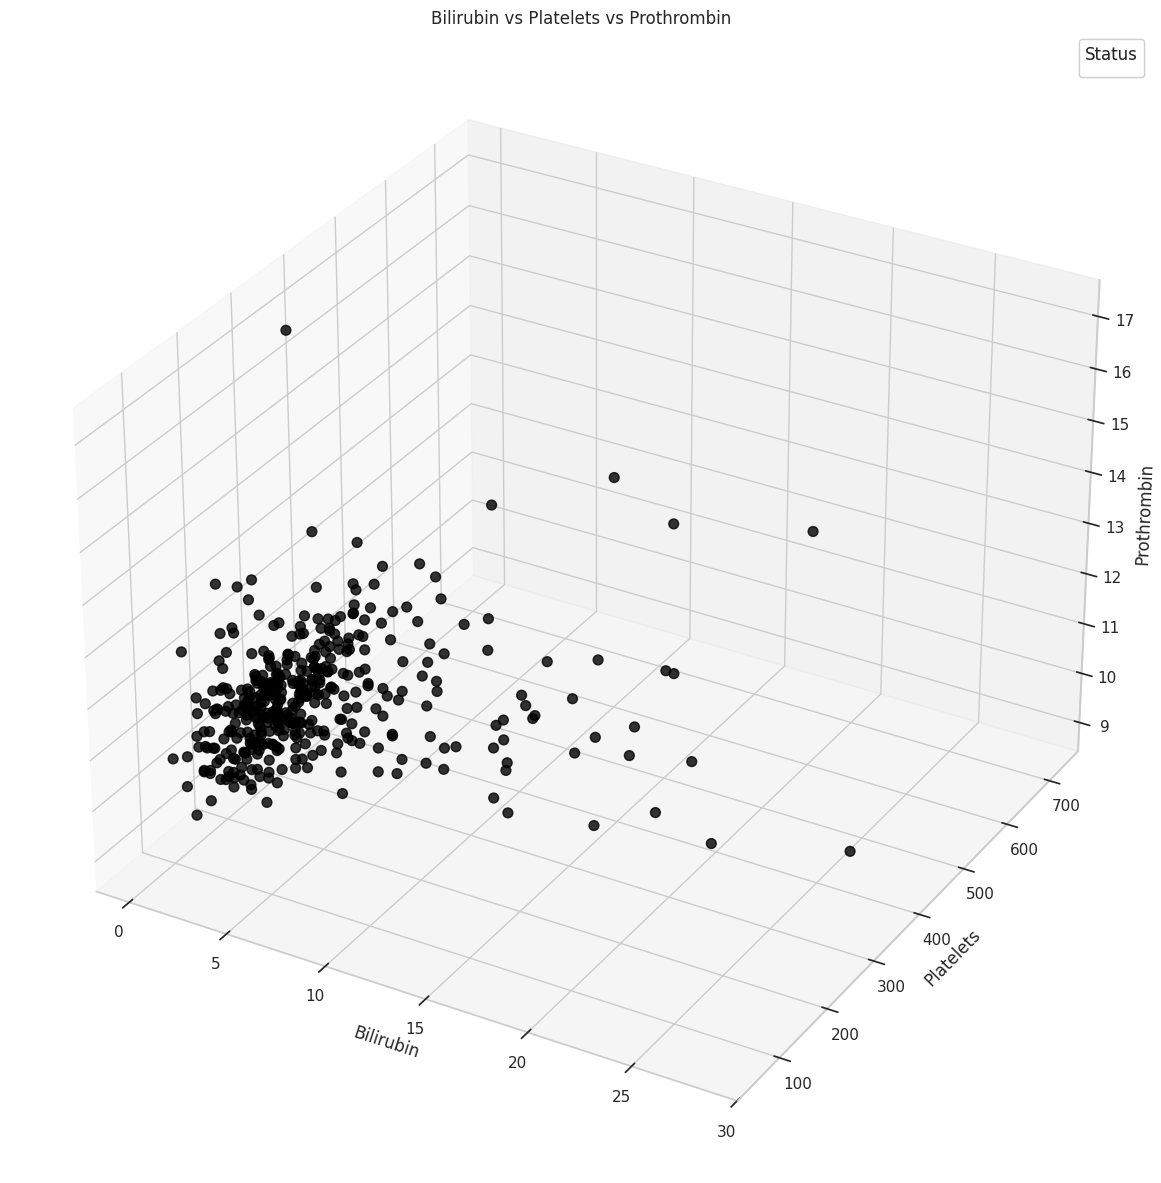

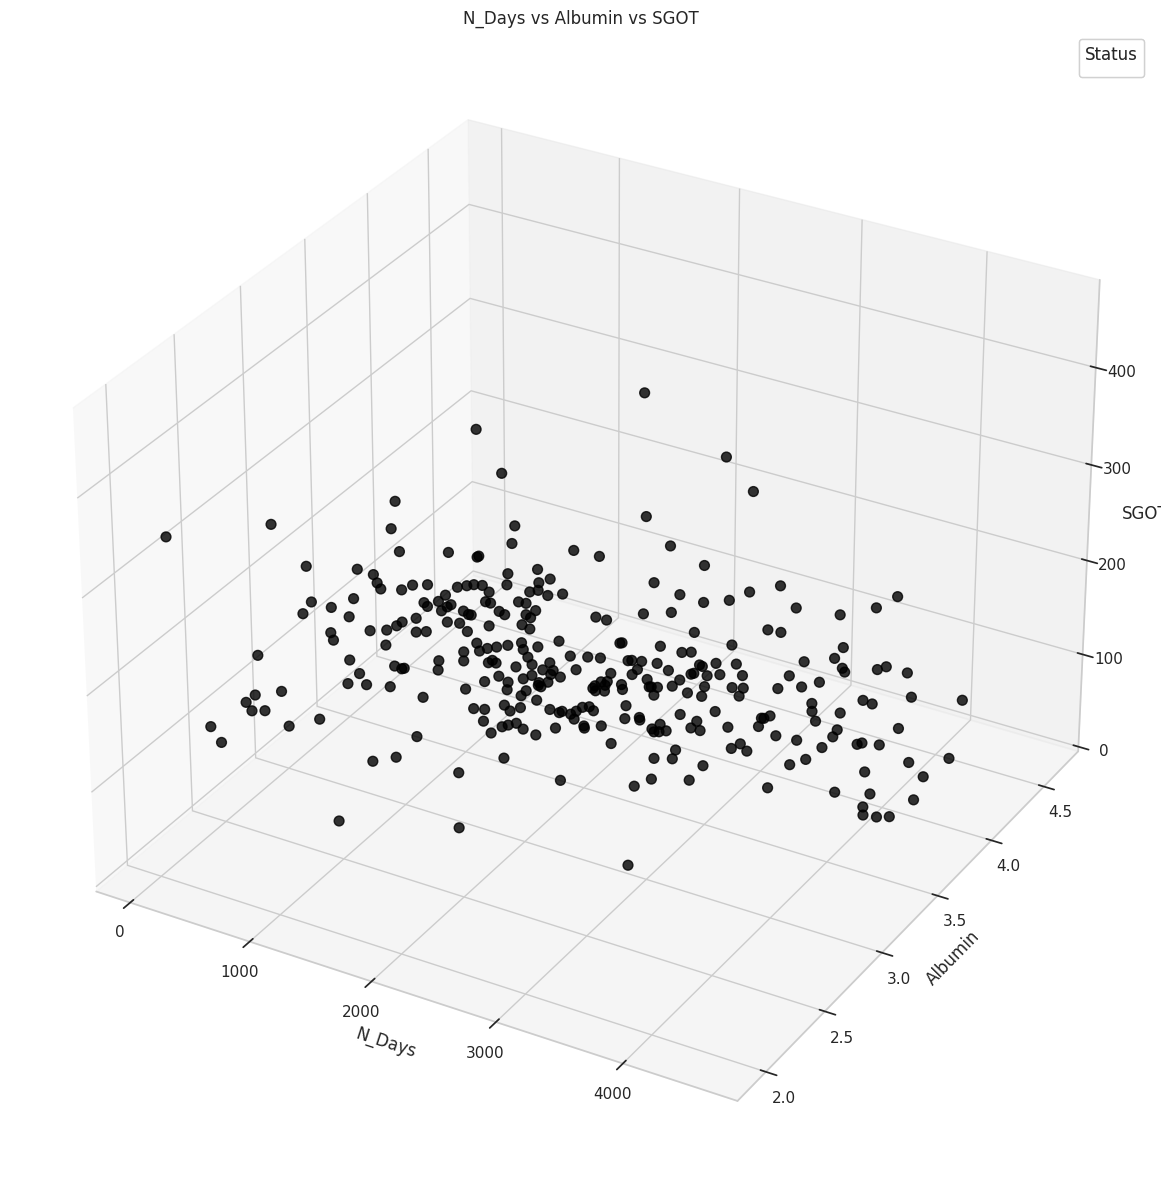

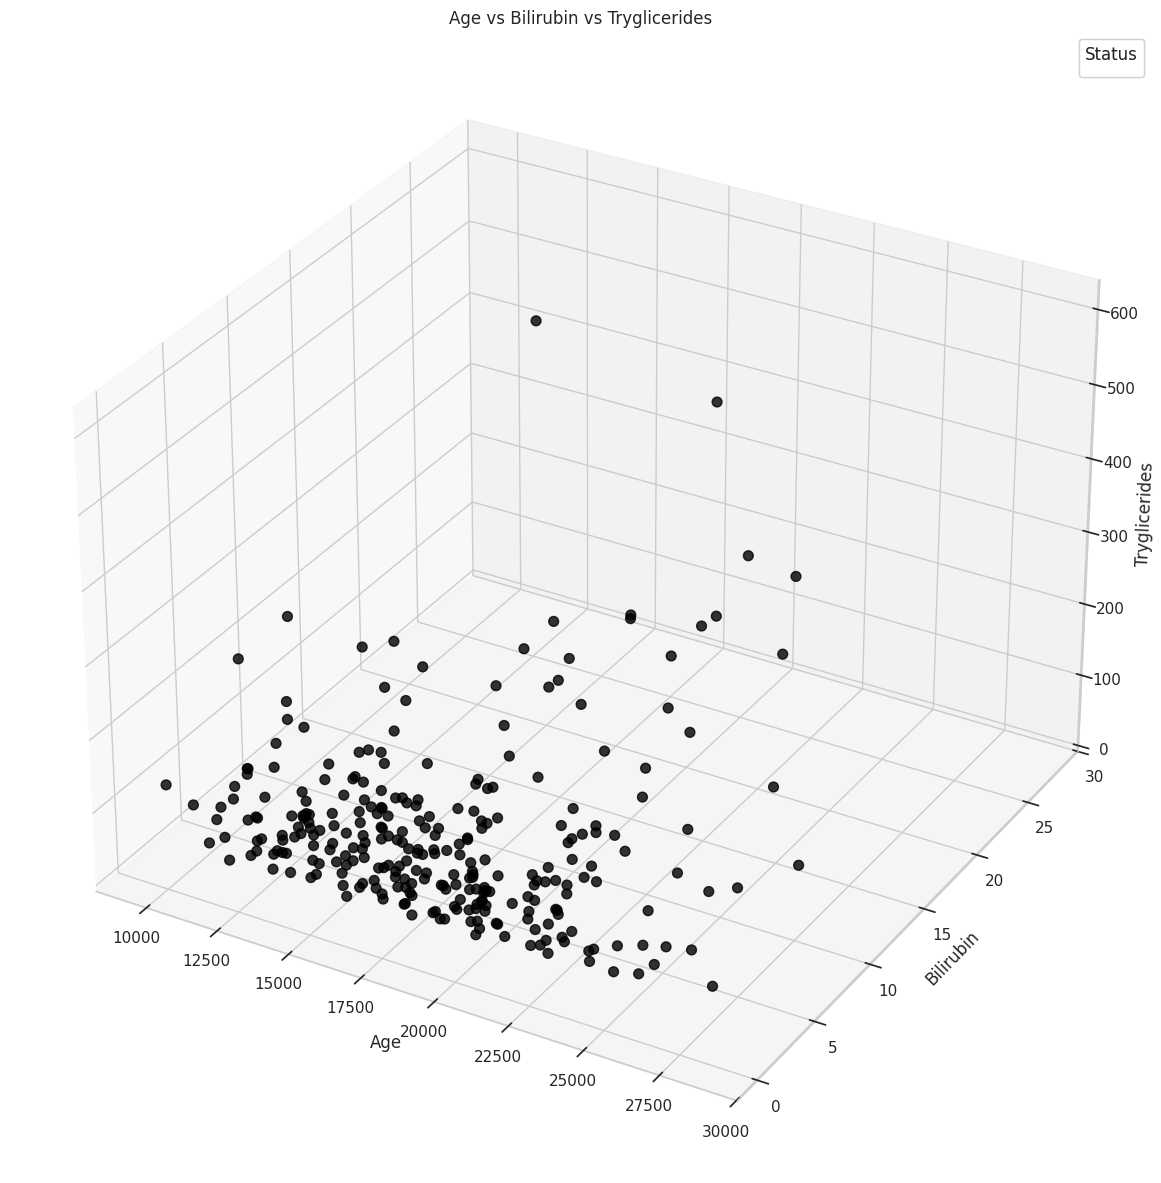

In [27]:
# Prepare data (handle missing values)
df_plot = df[['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Status']]

# List of combinations
combinations = [
    (['N_Days', 'Age', 'Bilirubin'], 'N_Days vs Age vs Bilirubin'),
    (['Albumin', 'Copper', 'Prothrombin'], 'Albumin vs Copper vs Prothrombin'),
    (['Alk_Phos', 'SGOT', 'Tryglicerides'], 'Alk_Phos vs SGOT vs Tryglicerides'),
    (['Bilirubin', 'Albumin', 'Copper'], 'Bilirubin vs Albumin vs Copper'),
    (['N_Days', 'Platelets', 'Prothrombin'], 'N_Days vs Platelets vs Prothrombin'),
    (['Age', 'Cholesterol', 'Tryglicerides'], 'Age vs Cholesterol vs Tryglicerides'),
    (['Alk_Phos', 'SGOT', 'Copper'], 'Alk_Phos vs SGOT vs Copper'),
    (['Bilirubin', 'Platelets', 'Prothrombin'], 'Bilirubin vs Platelets vs Prothrombin'),
    (['N_Days', 'Albumin', 'SGOT'], 'N_Days vs Albumin vs SGOT'),
    (['Age', 'Bilirubin', 'Tryglicerides'], 'Age vs Bilirubin vs Tryglicerides')
]

# Generate 3D plots
for cols, title in combinations:
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    # Choose 3 features to visualize
    x = df_plot[cols[0]]
    y = df_plot[cols[1]]
    z = df_plot[cols[2]]
    c = df_plot['Status']  # Color by Status (0=Censored, 1=CL, 2=Dead)

    # Map Status values to RGB colors
    color_map = {0: (1, 0, 0), 1: (0, 1, 0), 2: (0, 0, 1)}  # Red, Green, Blue
    colors = [color_map.get(stat_val, (0, 0, 0)) for stat_val in c]  # Default to black if out of range
    
    # 3D Scatter
    sc = ax.scatter(x, y, z, c=colors, s=50, alpha=0.8)
    ax.set_xlabel(cols[0])
    ax.set_ylabel(cols[1])
    ax.set_zlabel(cols[2])
    ax.set_title(title)
    
    
    # Add legend
    legend1 = ax.legend(*sc.legend_elements(), title="Status")
    ax.add_artist(legend1)
    
    plt.tight_layout()
    plt.show()

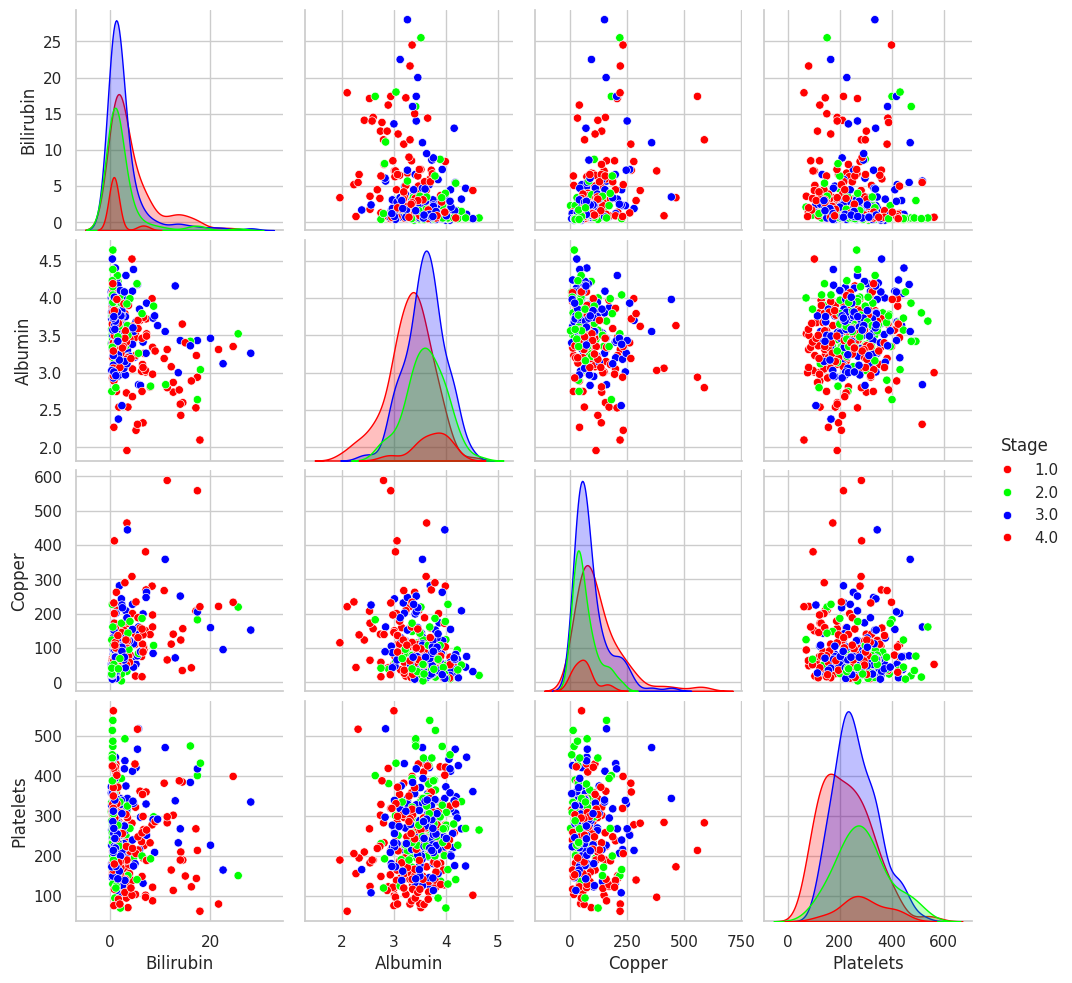

In [28]:
selected = ['Bilirubin', 'Albumin', 'Copper', 'Platelets', 'Stage']
sns.pairplot(data_copy[selected], hue='Stage', palette=[(1, 0, 0), (0, 1, 0), (0, 0, 1)])
plt.show()


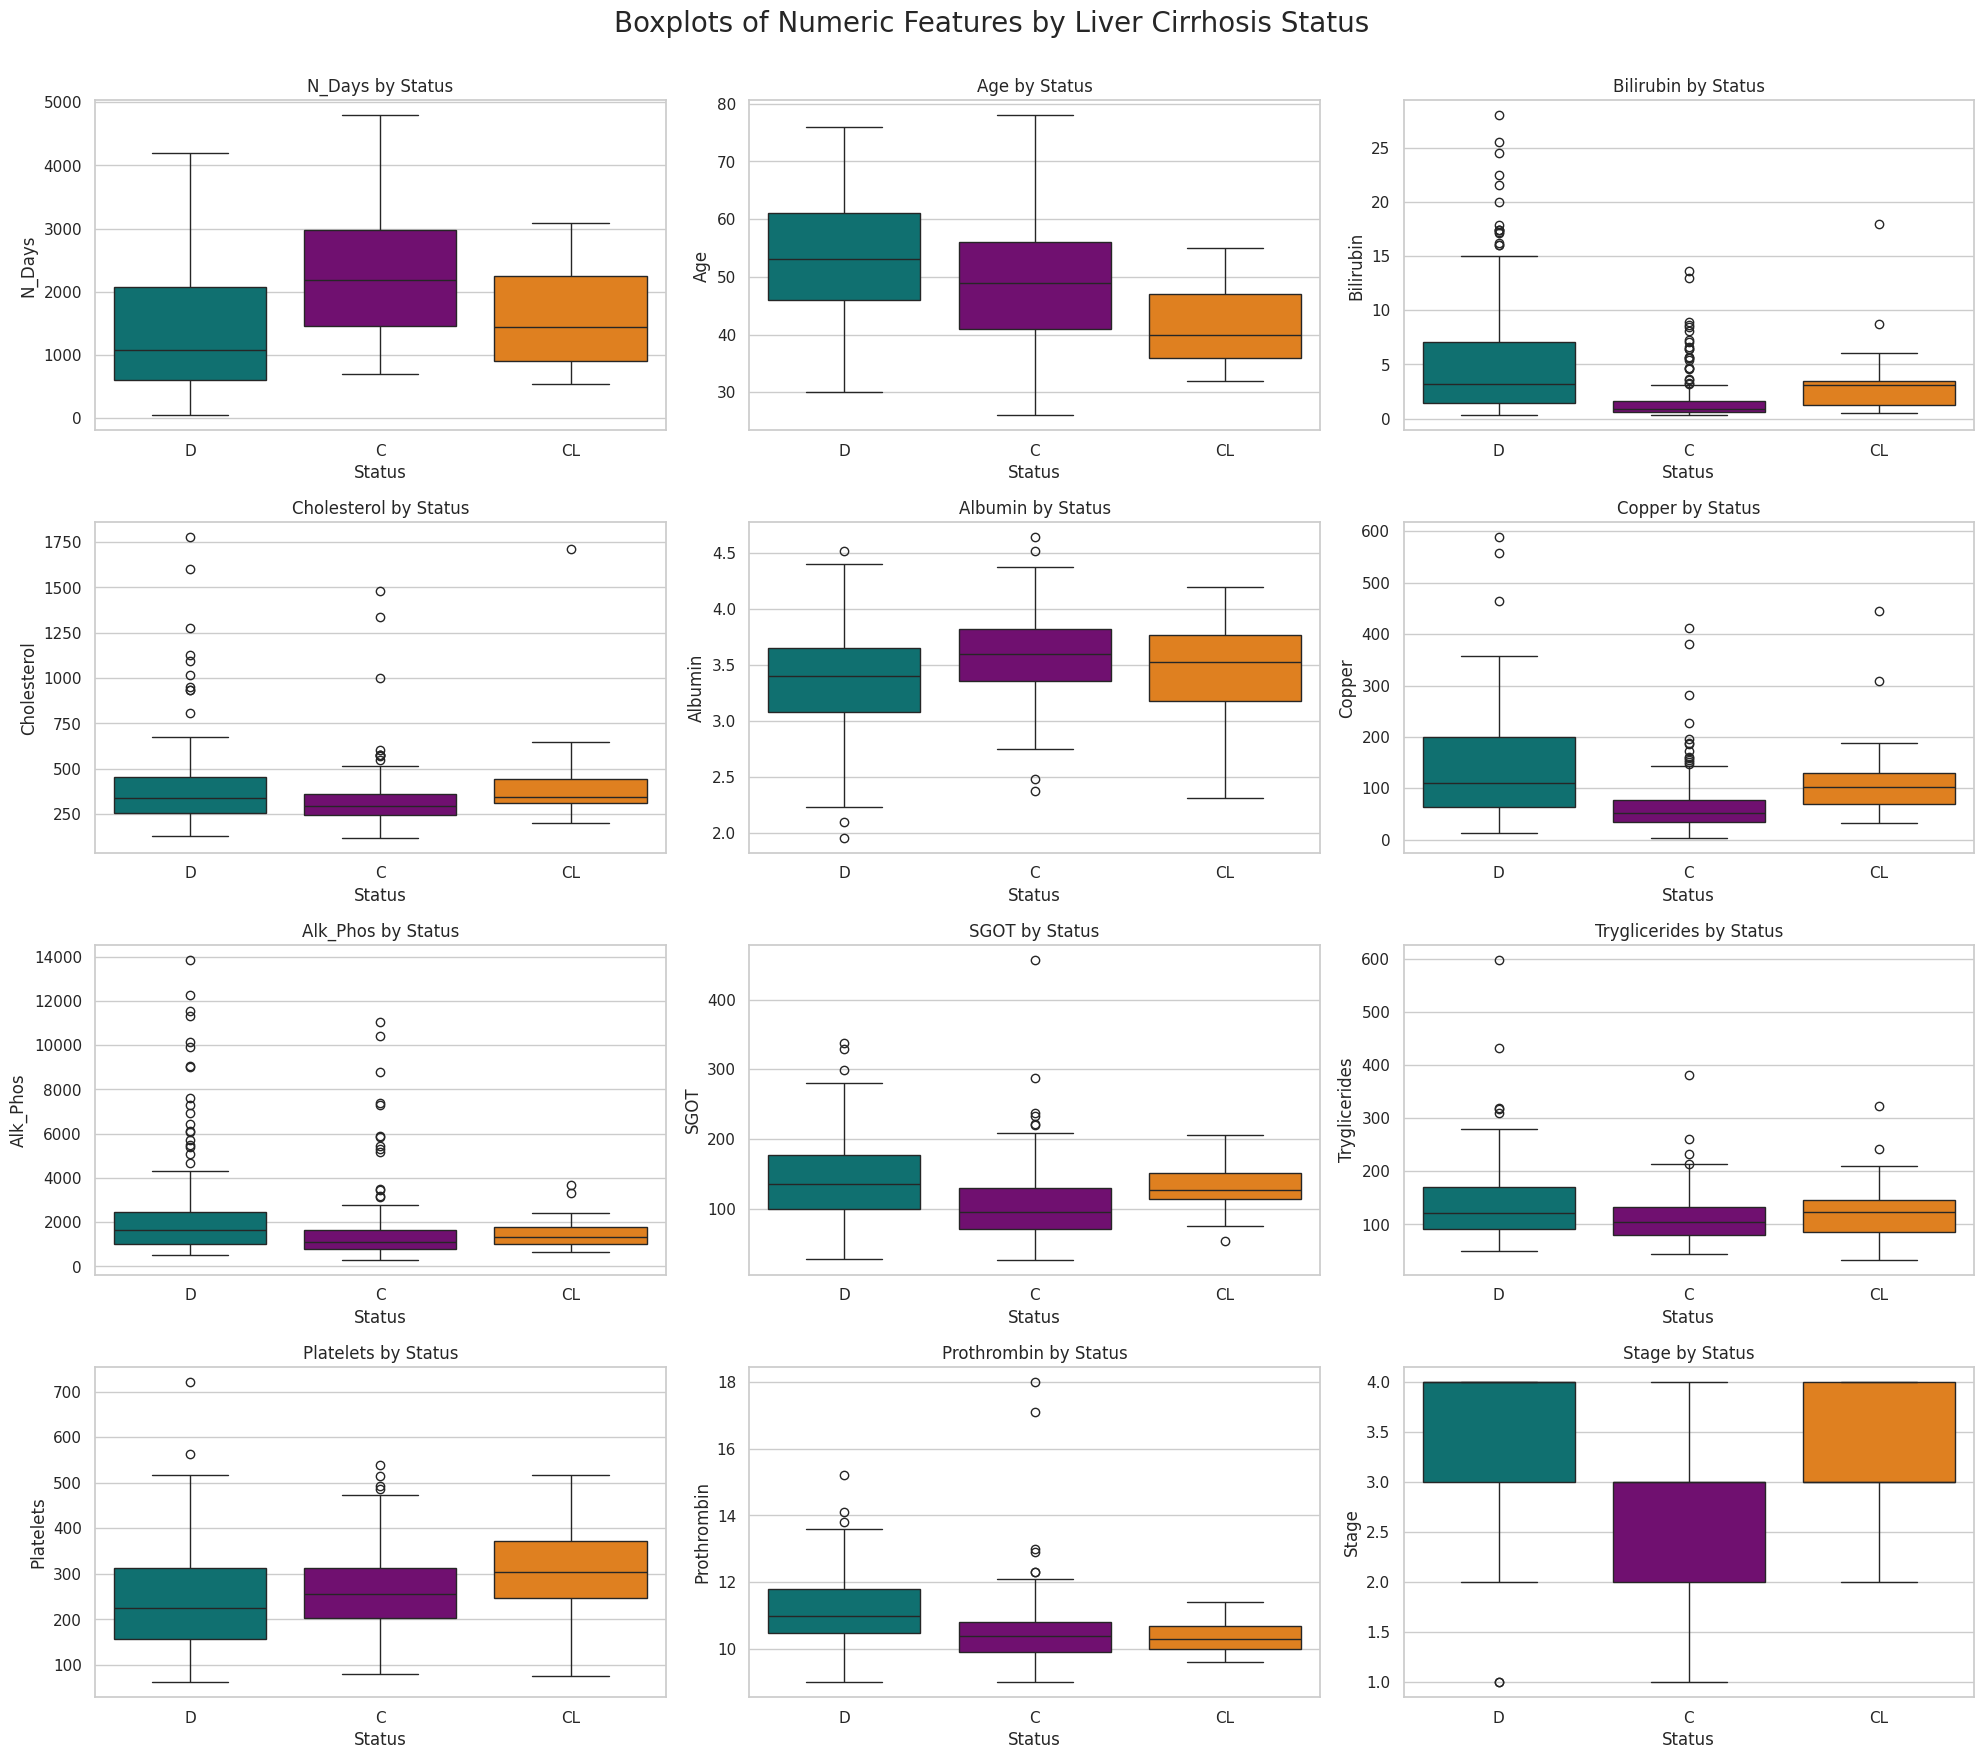

In [29]:
# Plot boxplots of numeric features grouped by 'Status'
plt.figure(figsize=(20, 25))
for i, col in enumerate(df_num):
    plt.subplot(6, 3, i + 1)
    sns.boxplot(data=df_num, x=data_copy['Status'], y=col, palette=[(0, 0.5, 0.5), (0.5, 0, 0.5), (1, 0.5, 0)])
    plt.title(f'{col} by Status')
    plt.tight_layout()

plt.suptitle('Boxplots of Numeric Features by Liver Cirrhosis Status', fontsize=20, y=1.02)
plt.show()

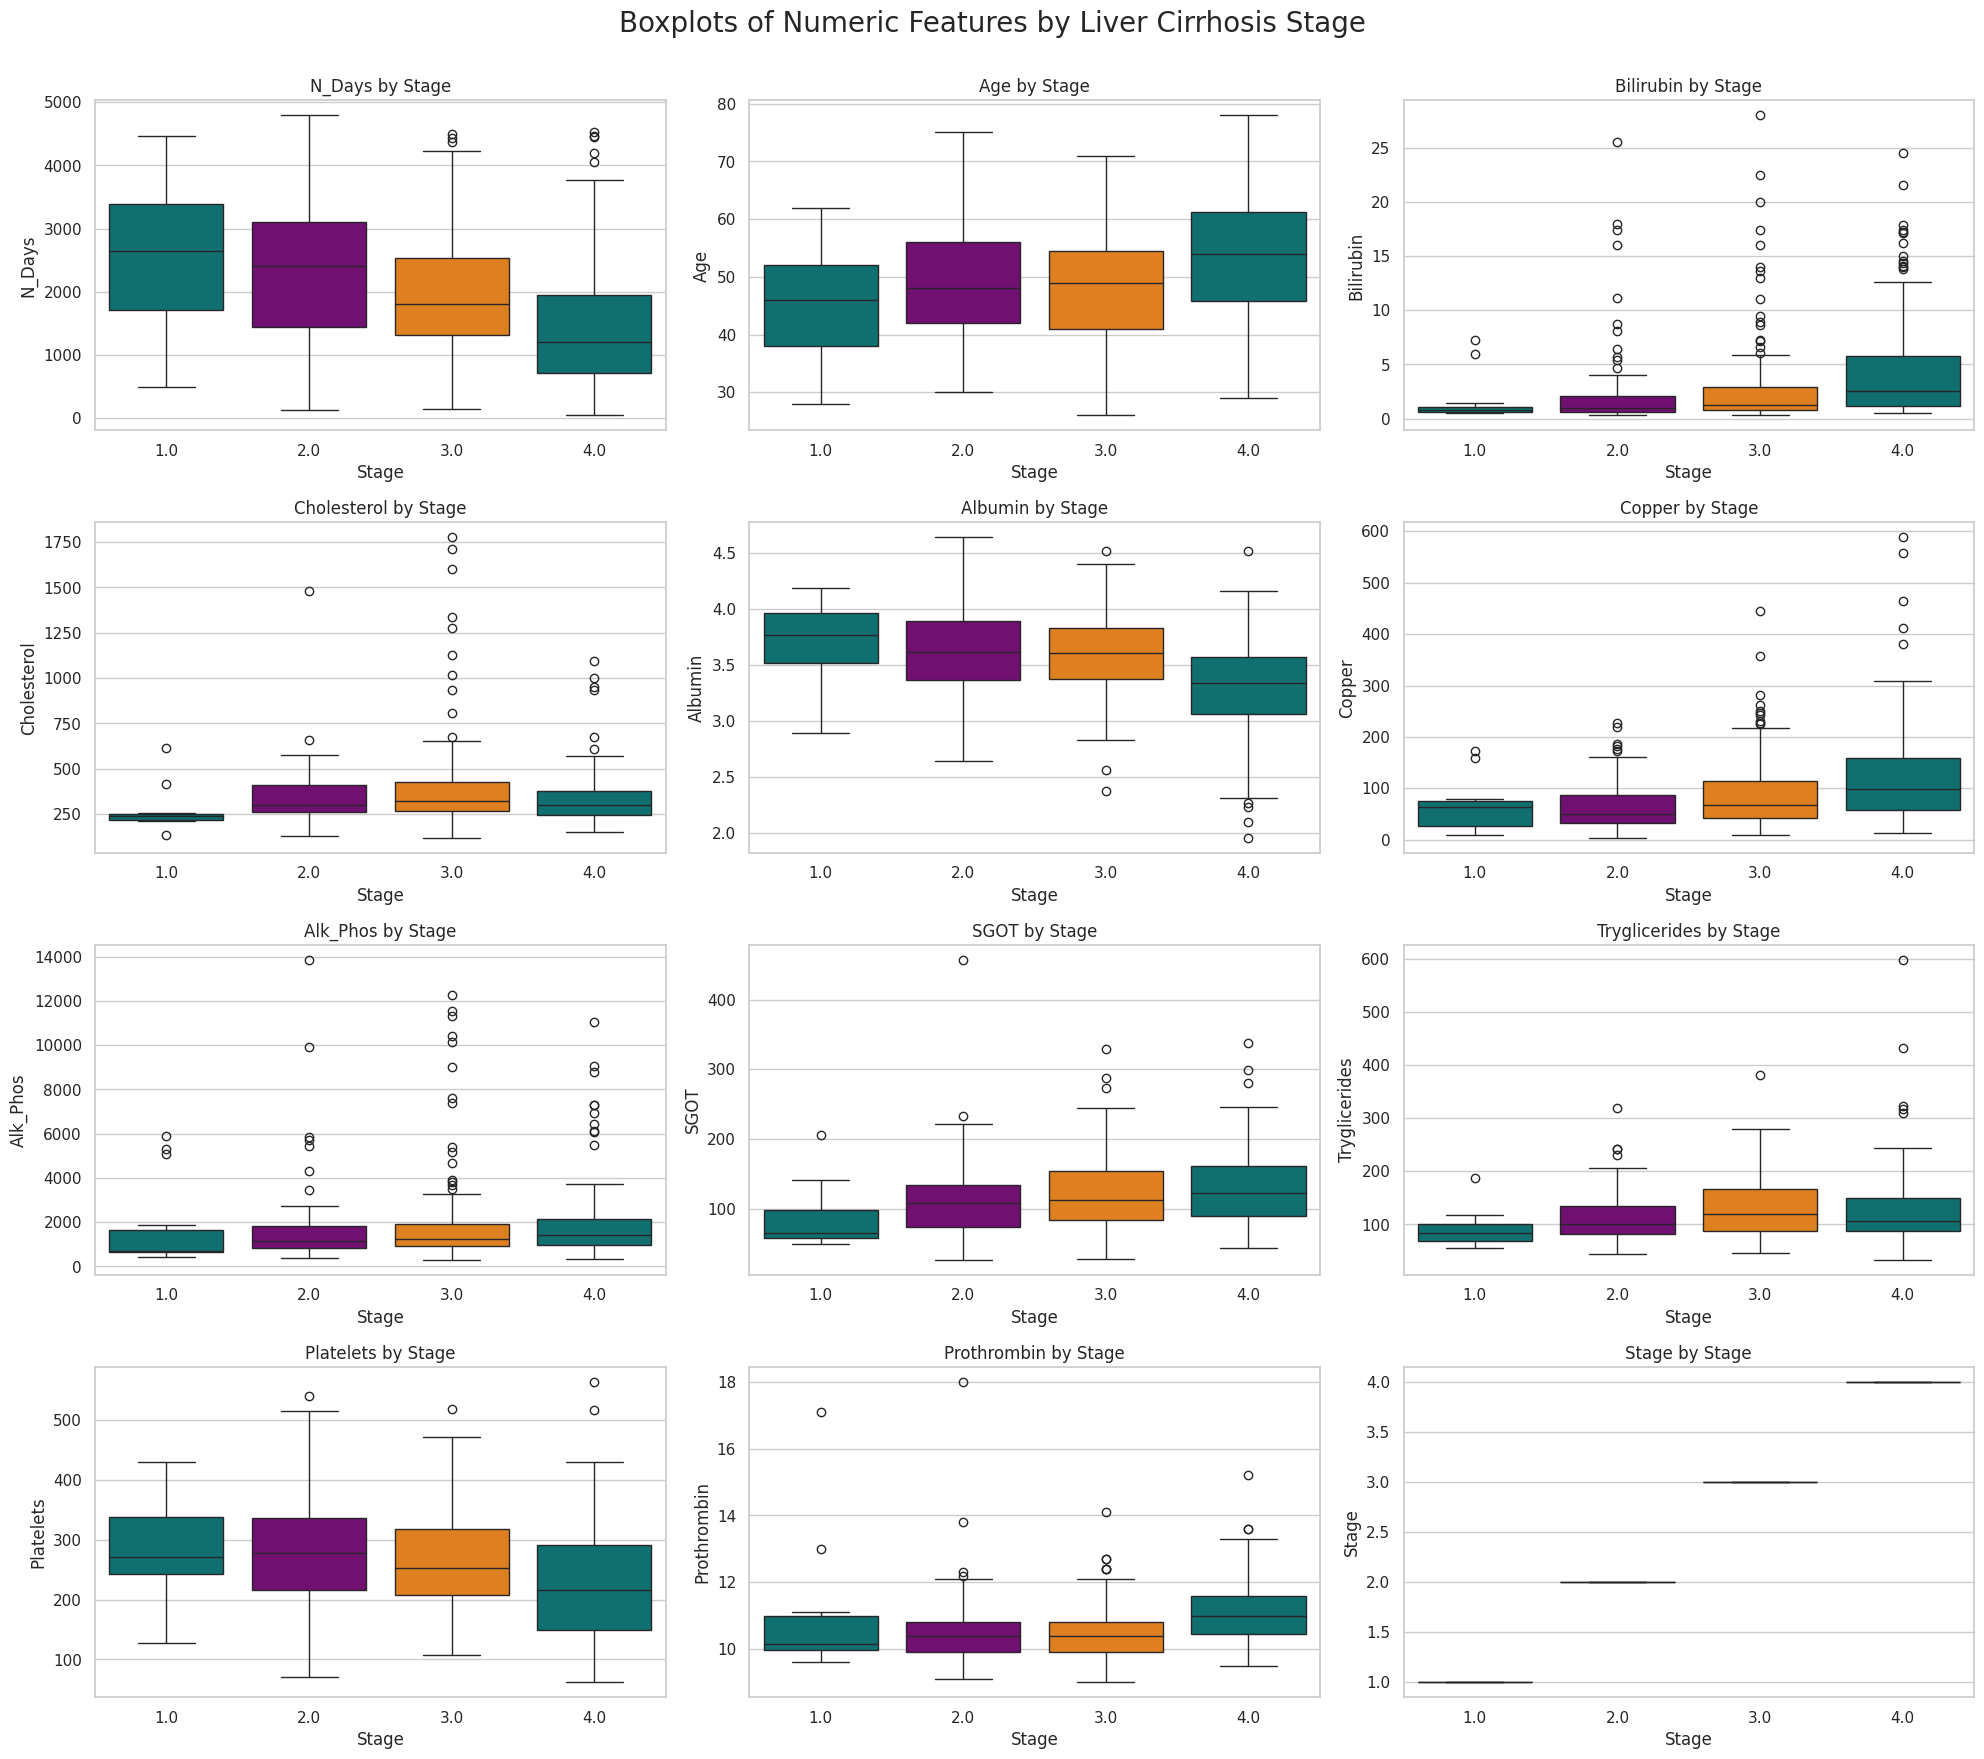

In [30]:
# Plot boxplots of numeric features grouped by 'Stage'
plt.figure(figsize=(20, 25))
for i, col in enumerate(df_num):
    plt.subplot(6, 3, i + 1)
    sns.boxplot(data=df_num, x='Stage', y=col, palette=[(0, 0.5, 0.5), (0.5, 0, 0.5), (1, 0.5, 0)])
    plt.title(f'{col} by Stage')
    plt.tight_layout()

plt.suptitle('Boxplots of Numeric Features by Liver Cirrhosis Stage', fontsize=20, y=1.02)
plt.show()

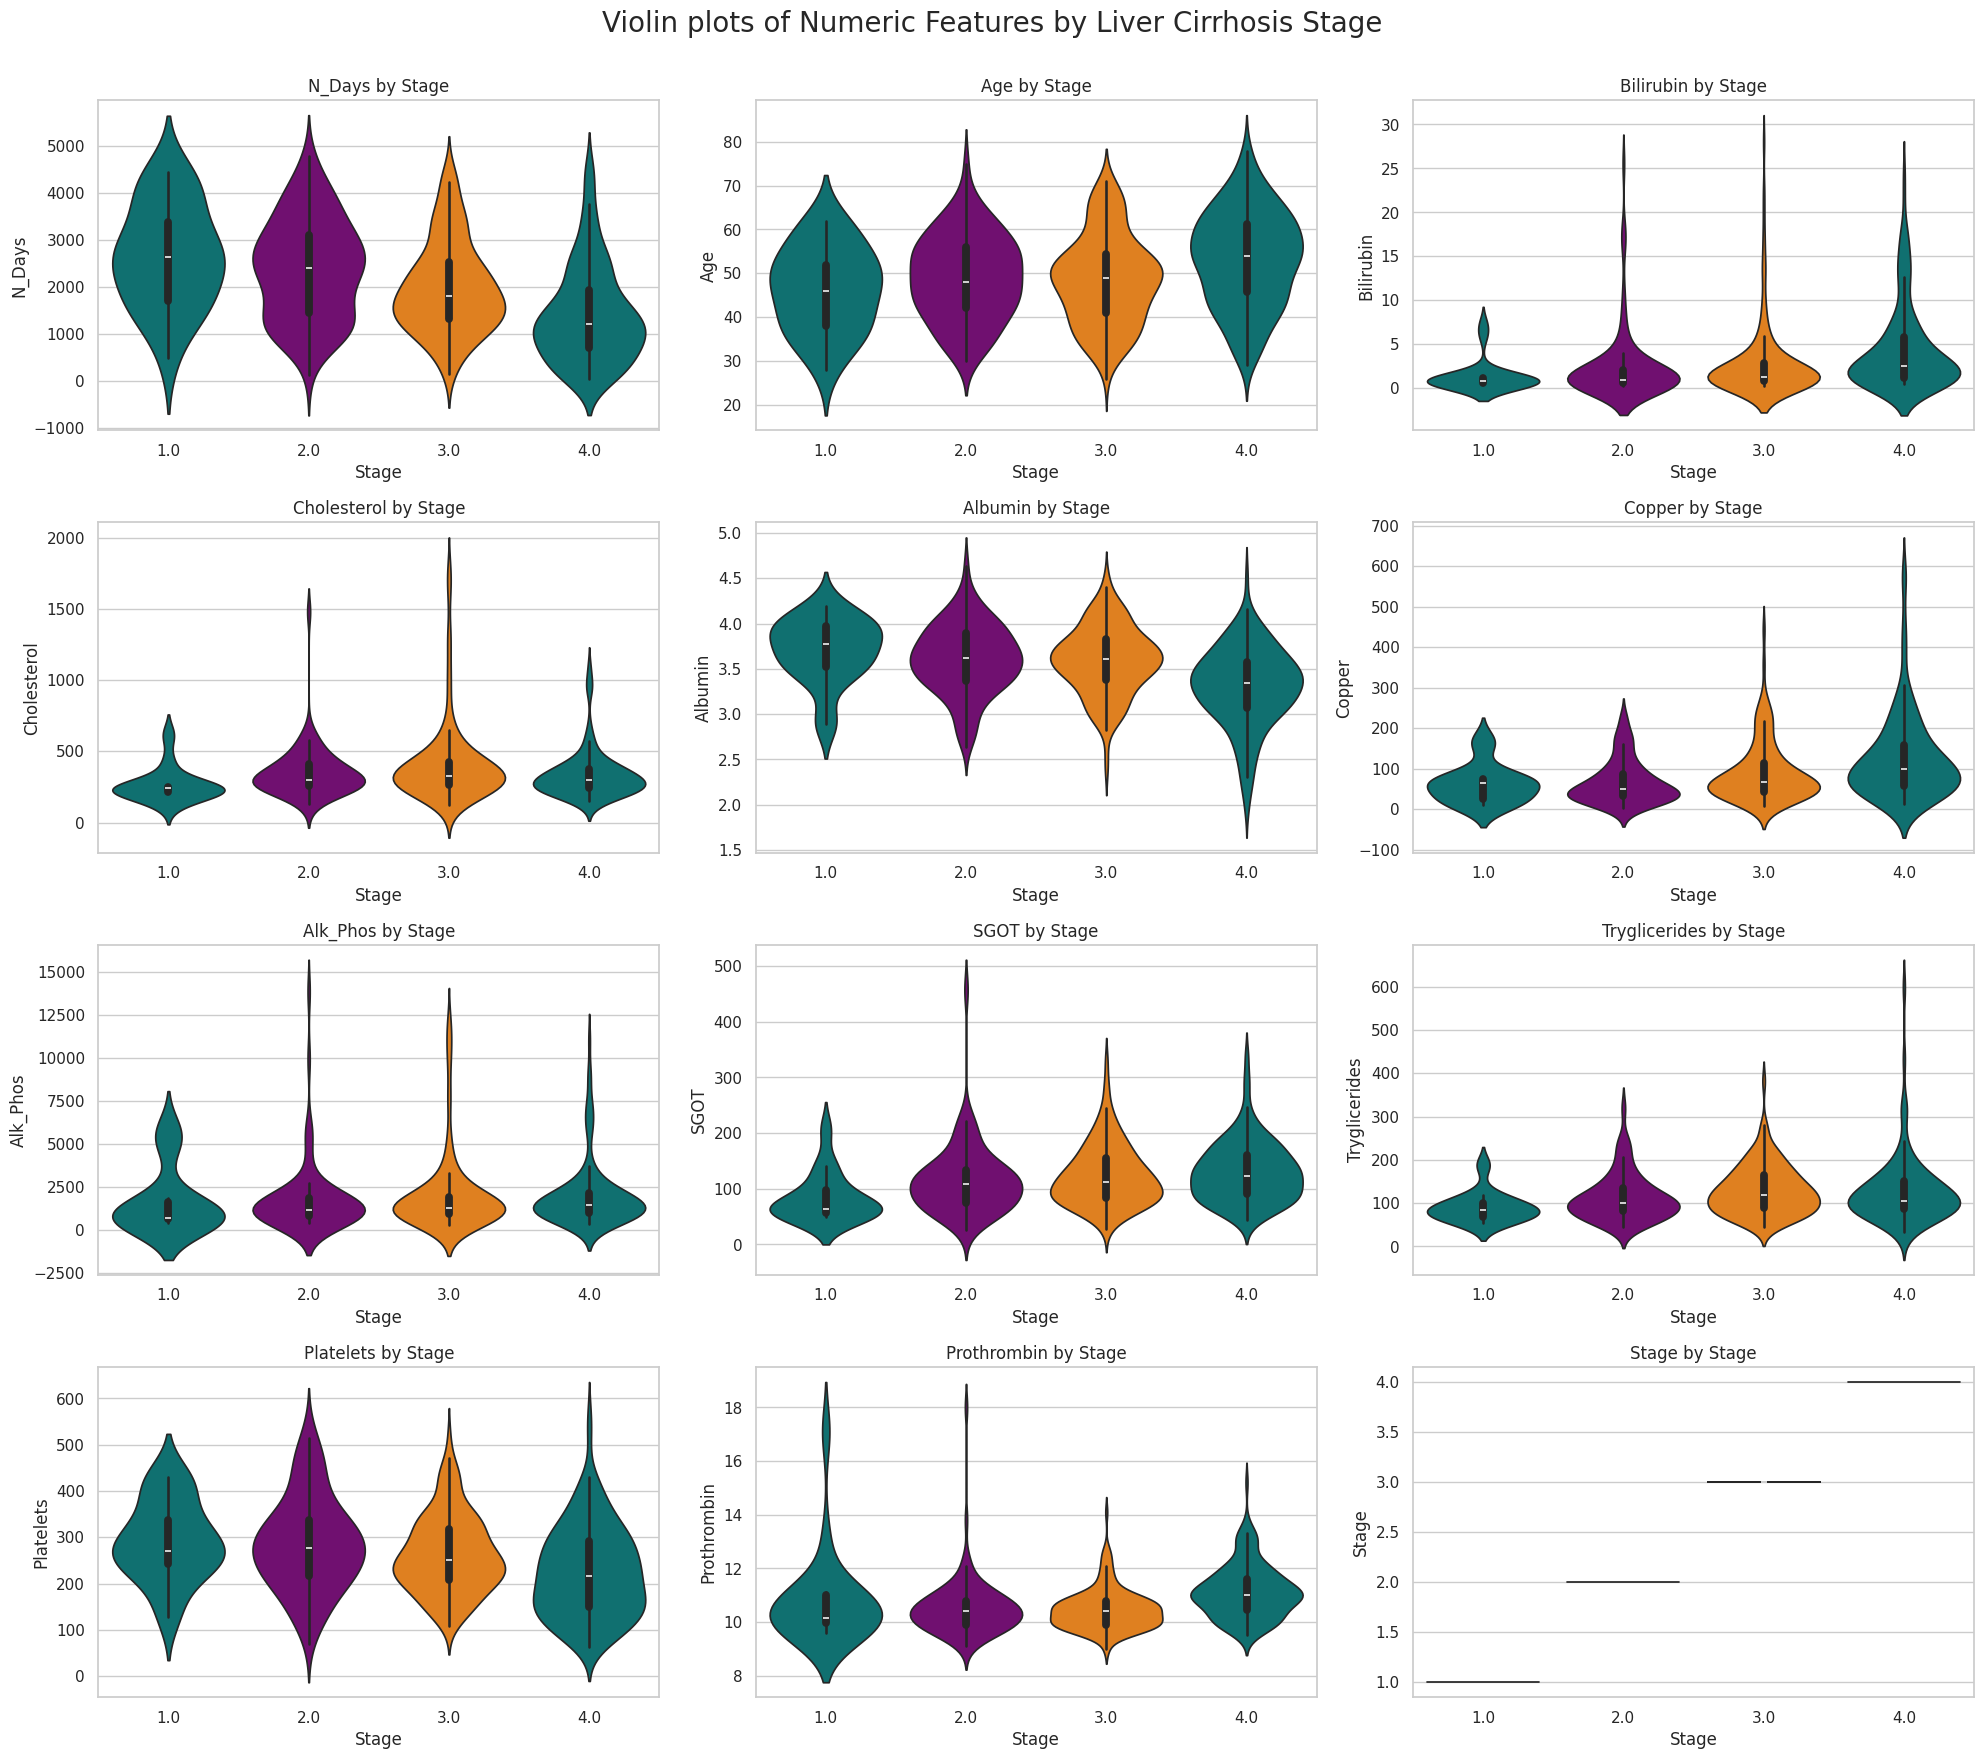

In [31]:
# Plot vioolin plots of numeric features grouped by 'Stage'
plt.figure(figsize=(20, 25))
for i, col in enumerate(df_num):
    plt.subplot(6, 3, i + 1)
    sns.violinplot(data=df_num, x='Stage', y=col, palette=[(0, 0.5, 0.5), (0.5, 0, 0.5), (1, 0.5, 0)])
    plt.title(f'{col} by Stage')
    plt.tight_layout()

plt.suptitle('Violin plots of Numeric Features by Liver Cirrhosis Stage', fontsize=20, y=1.02)
plt.show()


# Extracting Outliers from the dataset

In [32]:
df_num.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,58,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,56,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,70,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,54,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,38,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [33]:
df_num_copy = df_num.copy()
df_num_copy.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,58,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,56,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,70,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,54,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,38,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [34]:
# Identifying extreme values in the dataset
skewed_cols = ['Bilirubin', 'Copper', 'SGOT', 'Cholesterol', 'Alk_Phos', 'Tryglicerides', 'Prothrombin', 'Platelets']
outlier_mask = pd.DataFrame(False, index=df_num_copy.index, columns=skewed_cols)
for col in skewed_cols:
    Q1 = df_num_copy[col].quantile(0.25)
    Q3 = df_num_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_mask[col] = (df_num_copy[col] < lower_bound) | (df_num_copy[col] > upper_bound)
    # print(f"\nOutliers in {col}: {df_num_copy[outlier_mask[col]].shape[0]} rows")

In [35]:
# Create DataFrame with outliers (rows where any skewed column has an outlier)
outlier_rows = outlier_mask.any(axis=1)
df_outliers = df_num_copy[outlier_rows].copy()
# print(f"\nOutlier DataFrame Shape: {df_outliers.shape}")

In [36]:
df_outliers.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,58,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,56,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
3,1925,54,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
7,2466,53,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
9,51,70,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


In [37]:
df_outliers.describe()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,113.000000,113.00000,113.000000,86.000000,113.000000,94.000000,94.000000,94.000000,86.000000,110.000000,112.000000,112.000000
mean,1672.053097,50.79646,7.408850,497.720930,3.365133,154.308511,3640.059574,142.793404,166.732558,274.118182,11.338393,3.187500
std,1337.952900,9.88068,6.533547,366.619009,0.459938,115.827275,3240.034635,73.938616,86.943988,122.108294,1.437418,0.895748
min,41.000000,30.00000,0.300000,151.000000,2.100000,10.000000,559.000000,26.350000,49.000000,62.000000,9.500000,1.000000
25%,732.000000,44.00000,1.800000,259.250000,3.060000,73.250000,1154.500000,84.395000,108.750000,190.750000,10.400000,3.000000
50%,1302.000000,51.00000,5.700000,359.500000,3.400000,122.500000,2158.000000,128.955000,152.000000,274.000000,11.000000,3.000000
75%,2386.000000,58.00000,11.400000,595.500000,3.700000,208.500000,5421.650000,181.162500,194.750000,344.000000,11.925000,4.000000
max,4795.000000,78.00000,28.000000,1775.000000,4.220000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


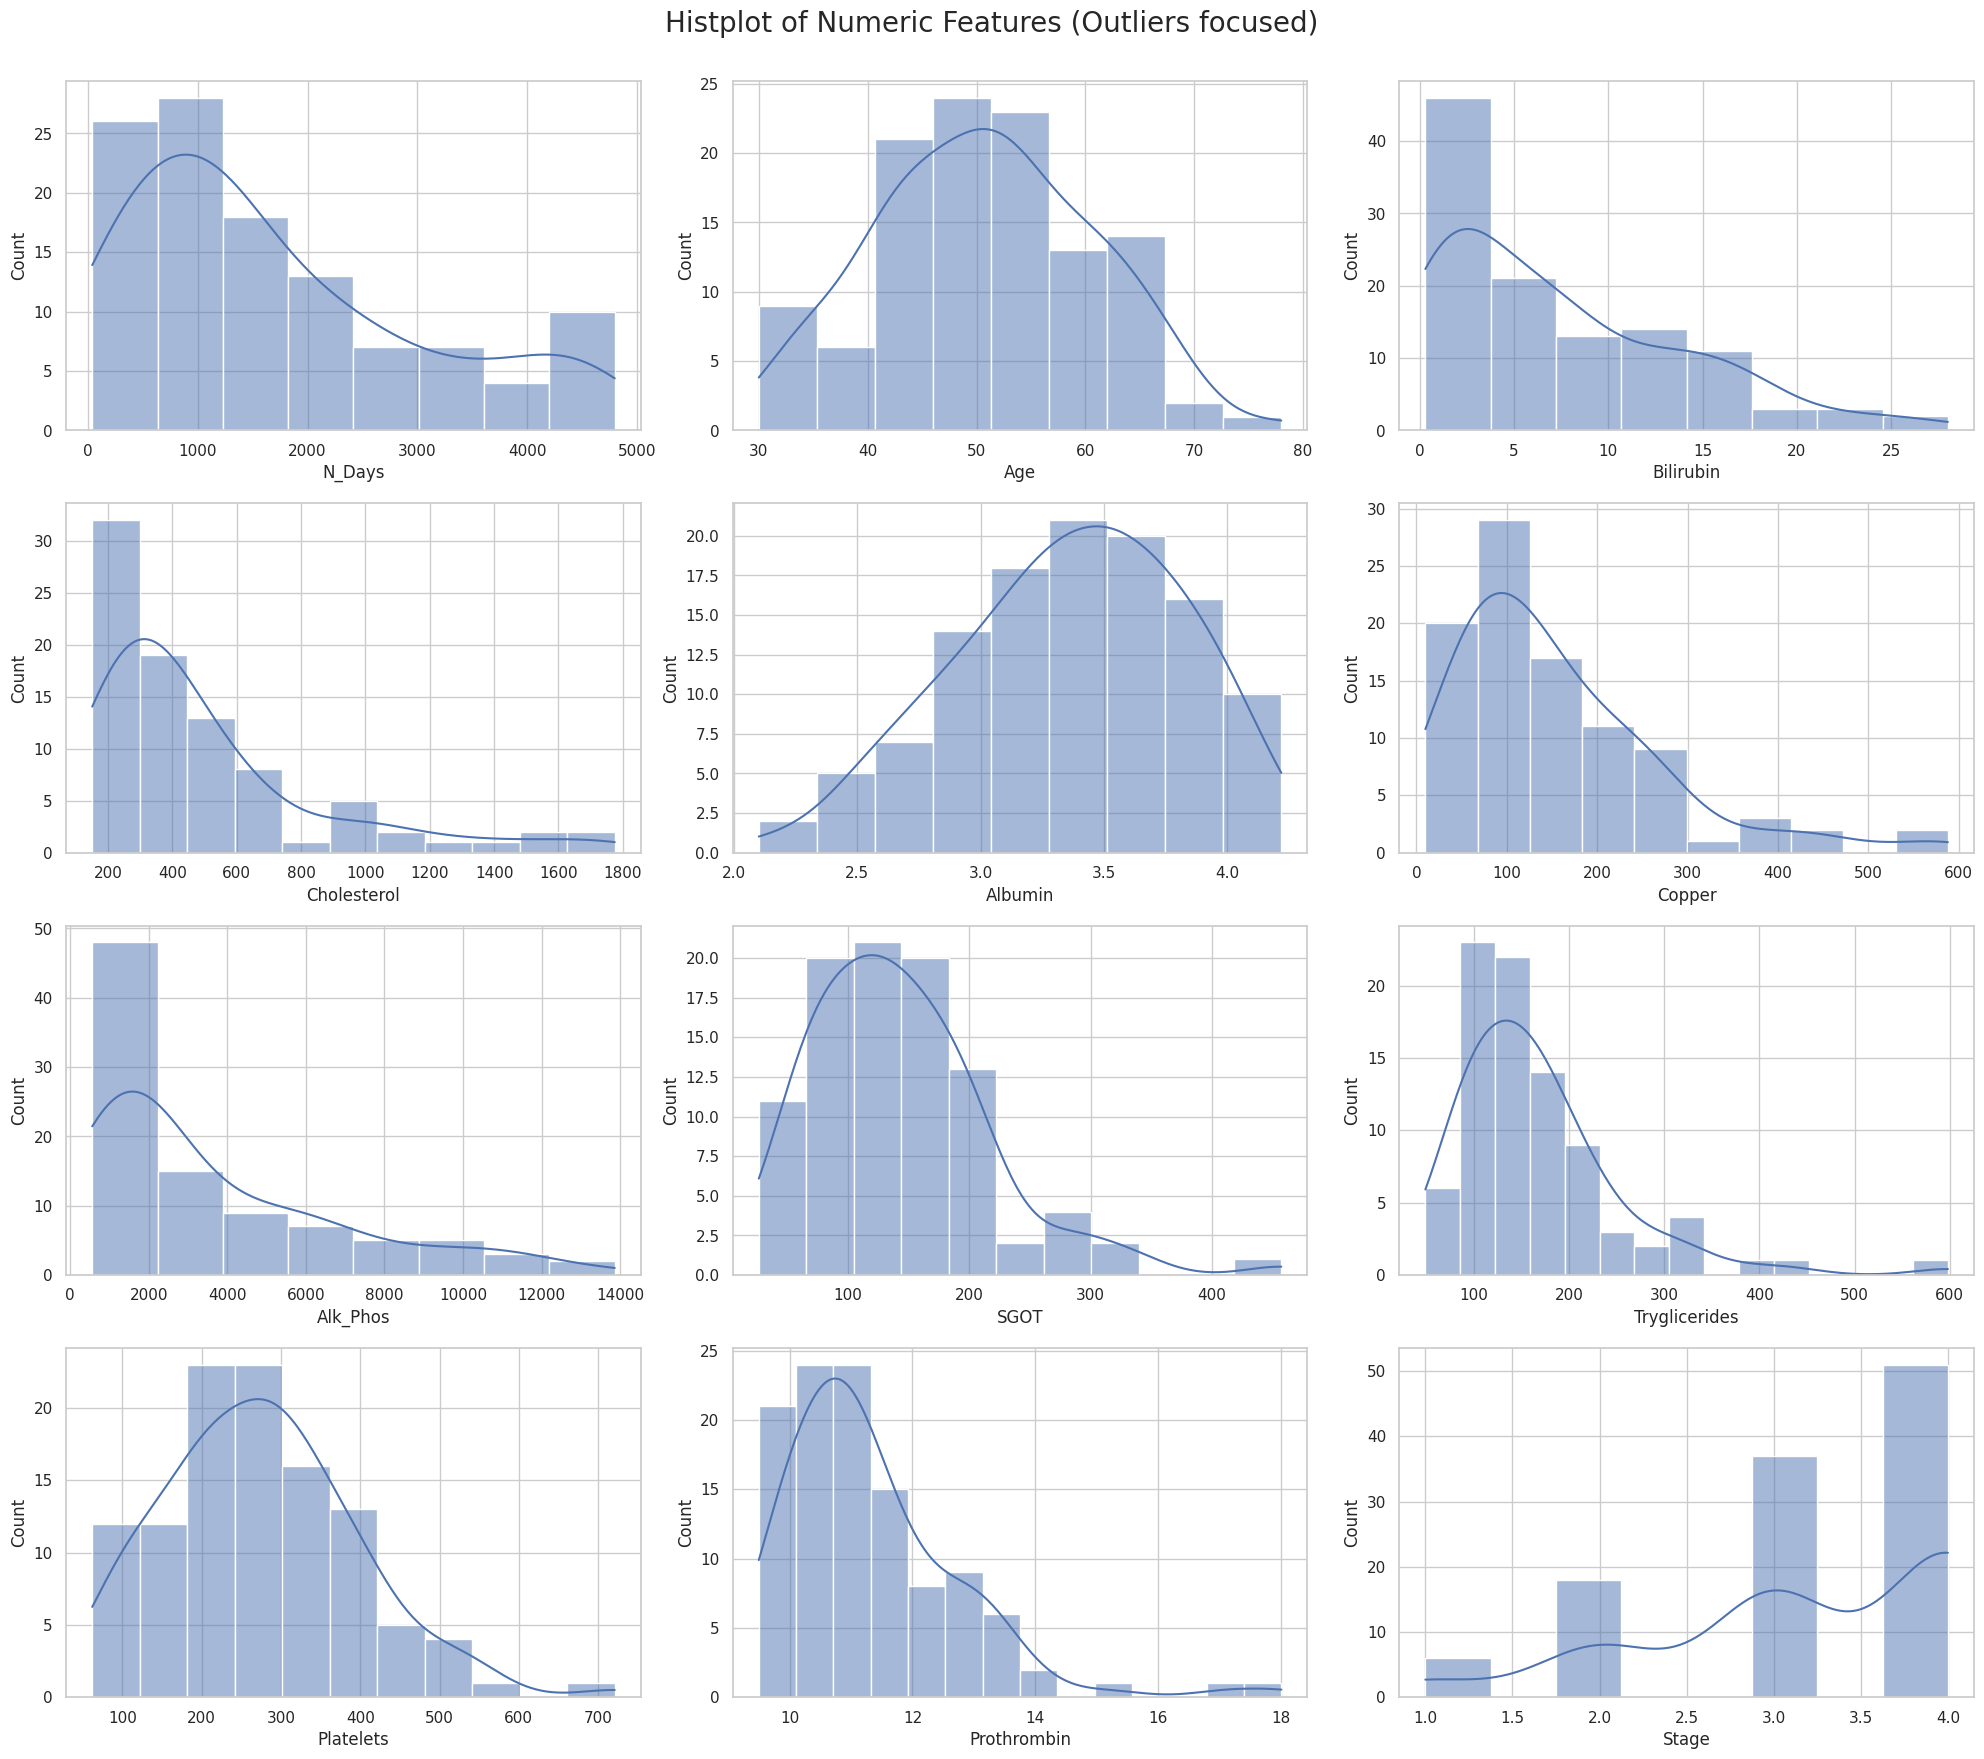

In [38]:
# Plot Histograms of numeric features
plt.figure(figsize=(20, 25))
for i, col in enumerate(df_outliers):
    plt.subplot(6, 3, i + 1)
    sns.histplot(data=df_outliers, x=col, palette=[(0, 0.5, 0.5), (0.5, 0, 0.5), (1, 0.5, 0)], kde=True)
    # plt.title(f'{col} by Stage')
    plt.tight_layout()

plt.suptitle('Histplot of Numeric Features (Outliers focused)', fontsize=20, y=1.02)
plt.show()

In [39]:
# Create copied DataFrame without outliers
df_no_outliers = df_num_copy[~outlier_rows].copy()
print(f"No-Outlier DataFrame Shape: {df_no_outliers.shape}")

No-Outlier DataFrame Shape: (305, 12)


In [40]:
df_no_outliers.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
2,1012,70,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
4,1504,38,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,2503,66,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,1832,55,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
8,2400,42,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0


In [41]:
df_no_outliers.describe()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,305.000000,305.000000,305.000000,198.000000,305.000000,216.000000,218.000000,218.000000,196.000000,297.000000,304.000000,300.000000
mean,2008.822951,50.108197,1.669180,313.823232,3.546459,72.990741,1267.995413,113.830275,106.260204,250.693603,10.508224,2.963333
std,991.778165,10.692384,1.408889,94.853101,0.401095,52.122574,603.054907,44.839421,41.233527,87.299831,0.698205,0.870545
min,41.000000,26.000000,0.300000,120.000000,1.960000,4.000000,289.000000,41.850000,33.000000,76.000000,9.000000,1.000000
25%,1236.000000,42.000000,0.700000,248.000000,3.350000,37.750000,816.250000,79.050000,76.000000,183.000000,10.000000,2.000000
50%,1882.000000,51.000000,1.100000,299.000000,3.570000,58.000000,1115.000000,107.725000,100.000000,246.000000,10.450000,3.000000
75%,2644.000000,58.000000,2.100000,372.750000,3.800000,91.750000,1625.000000,137.950000,128.000000,311.000000,11.000000,4.000000
max,4365.000000,76.000000,6.800000,604.000000,4.640000,243.000000,3472.000000,246.450000,242.000000,493.000000,12.700000,4.000000


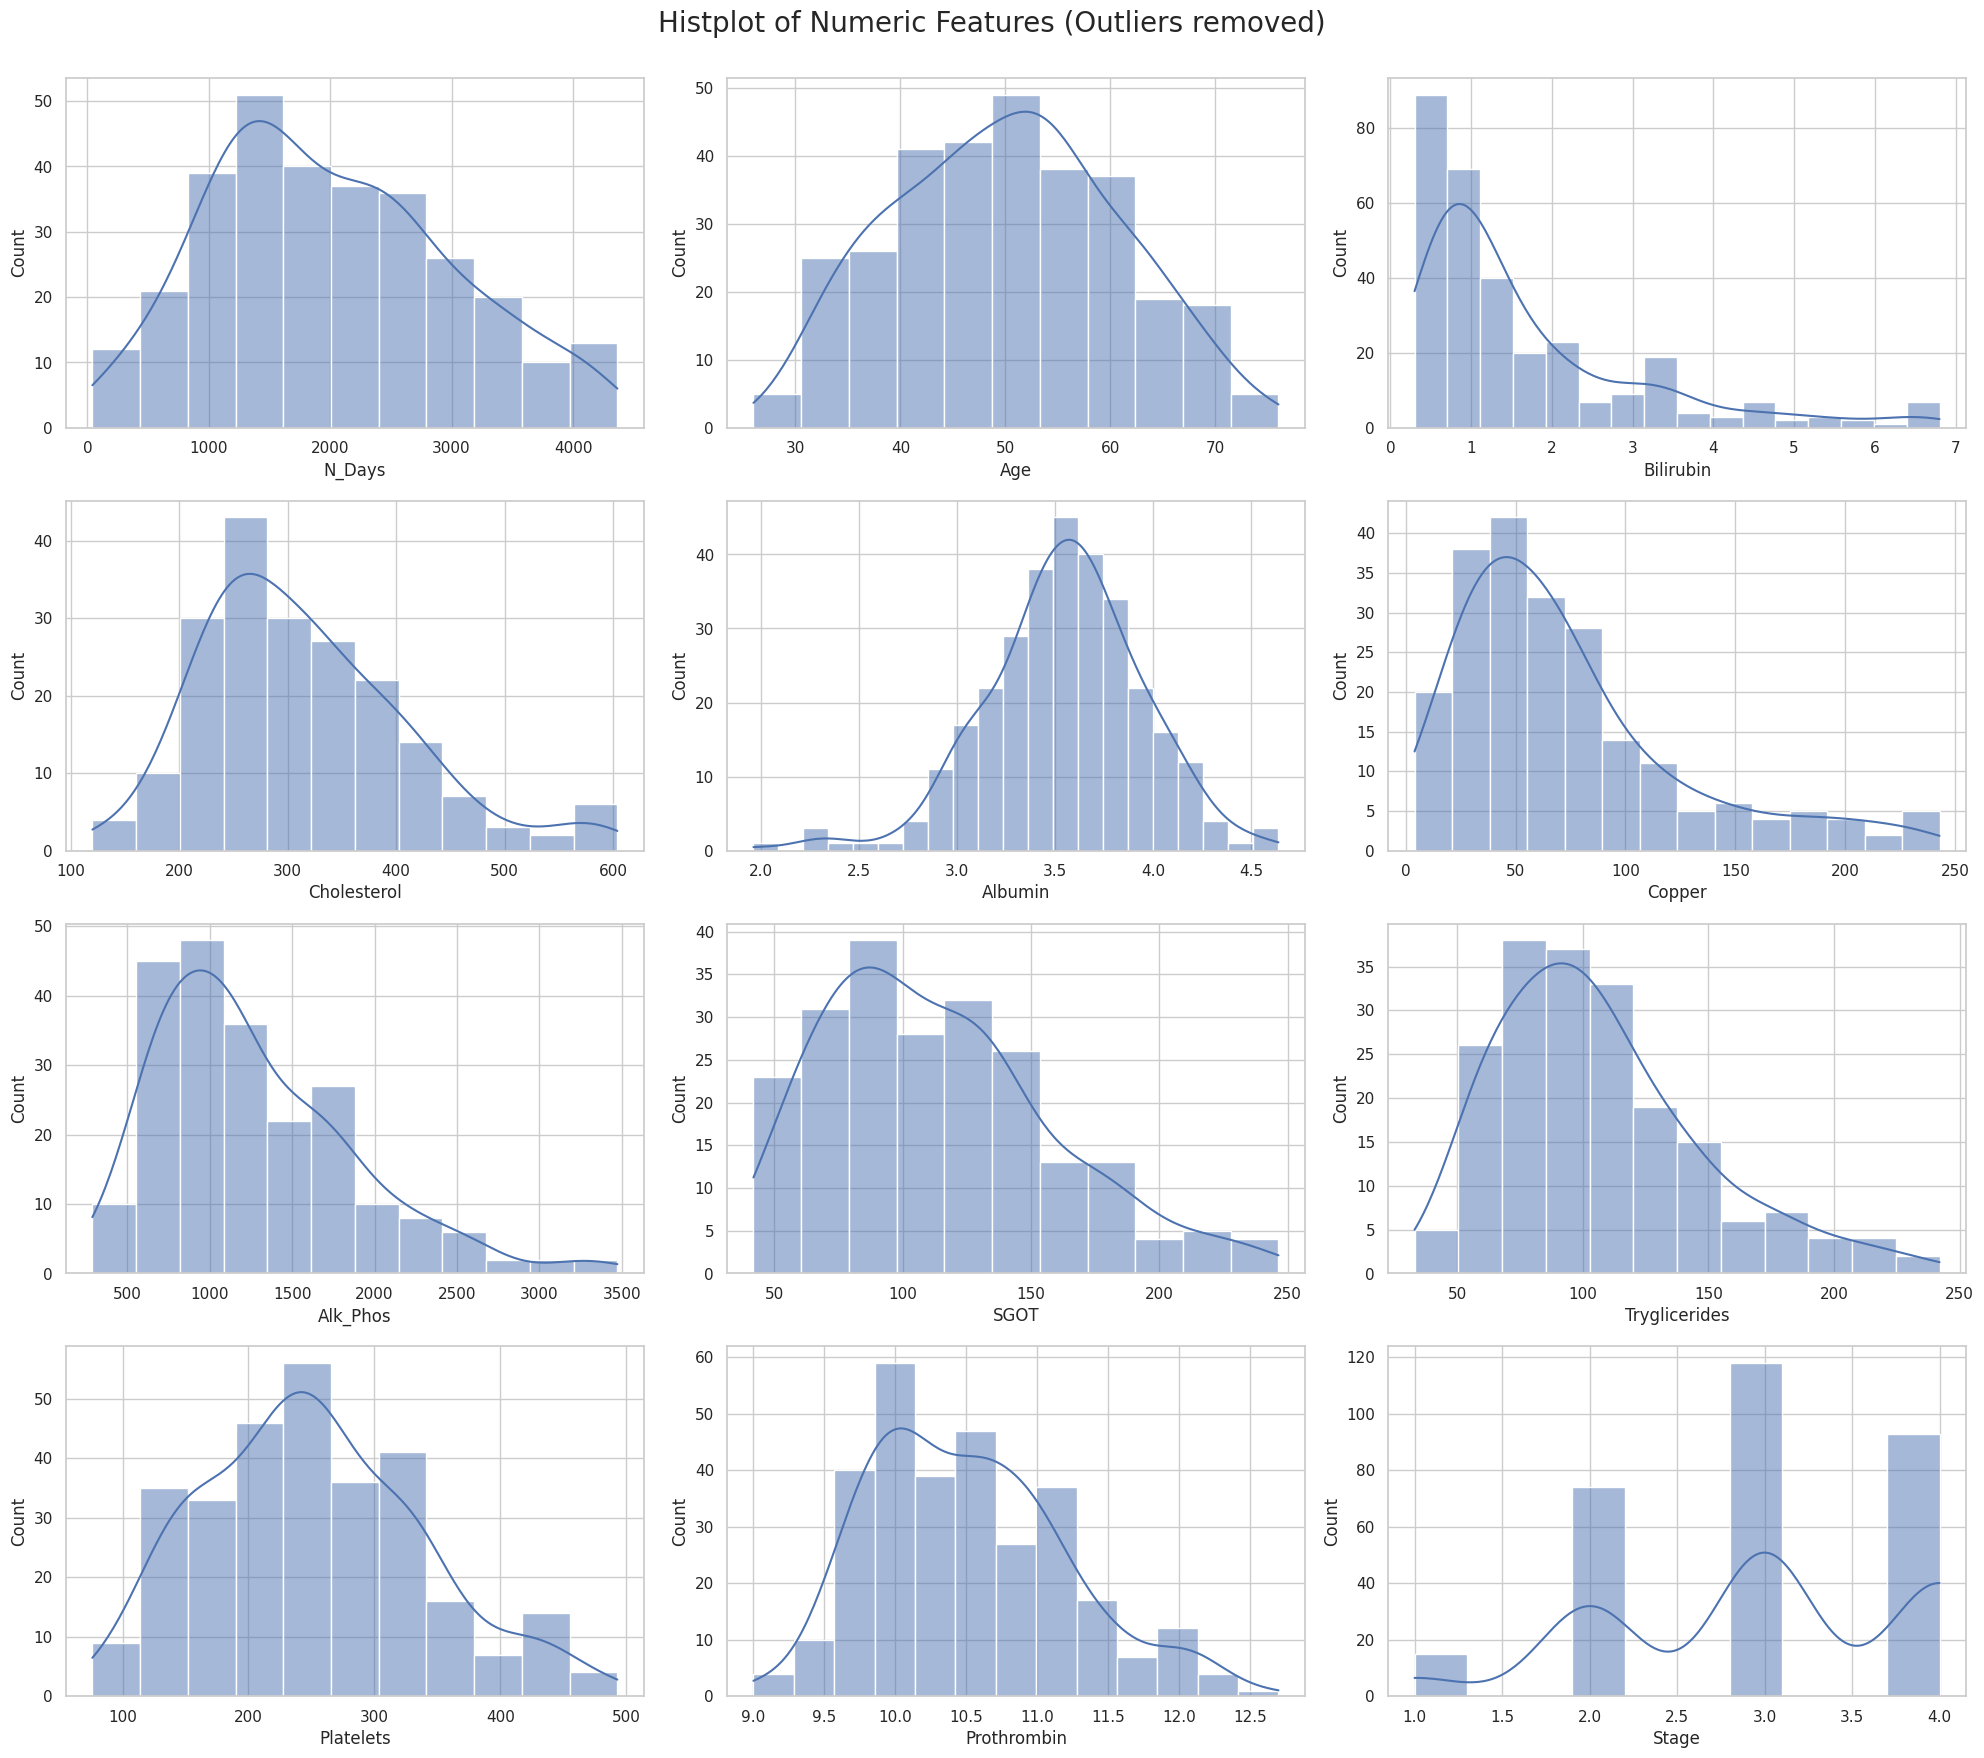

In [42]:
# Plot Histograms of numeric features
plt.figure(figsize=(20, 25))
for i, col in enumerate(df_no_outliers):
    plt.subplot(6, 3, i + 1)
    sns.histplot(data=df_no_outliers, x=col, palette='viridis', kde=True)
    # plt.title(f'{col} by Stage')
    plt.tight_layout()

plt.suptitle('Histplot of Numeric Features (Outliers removed)', fontsize=20, y=1.02)
plt.show()

## Handling of missing values

In [43]:
df_cleaned = data_copy.copy()

In [44]:
df_cleaned.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,58,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,56,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,70,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,54,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,38,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [45]:
df_cleaned.isnull().sum()

N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

In [46]:
cat_df.columns

Index(['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema'], dtype='object')

## Missing Values imputation
Imputing ```Mode``` for categorical values and ```KNN``` for Numerical values. KNN used ```n_neighbours=5```

In [47]:
# --- Imputation ---
# Categorical: Mode
cat_cols = cat_df.columns
num_cols = df_num.columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df_cleaned[cat_cols] = cat_imputer.fit_transform(df_cleaned[cat_cols])

# Numerical: KNN
knn_imputer = KNNImputer(n_neighbors=5)
df_cleaned[num_cols] = knn_imputer.fit_transform(df_cleaned[num_cols])

# --- Validation of Imputation ---
print("\nMissing Values After Imputation:")
print(df_cleaned.isnull().sum())


Missing Values After Imputation:
N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64


In [48]:
data_copy.describe()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,1917.782297,50.294258,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,1104.672992,10.471934,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,41.000000,26.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,1092.750000,42.000000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,1730.000000,51.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,2613.500000,58.000000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,4795.000000,78.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [49]:
df_cleaned.describe()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1917.782297,50.294258,3.220813,368.222010,3.497440,100.992823,1920.948612,123.719402,123.217703,257.104785,10.734306,3.025837
std,1104.672992,10.471934,4.407506,203.375349,0.424972,79.323167,1896.990669,50.758939,56.177268,97.282711,1.020935,0.879122
min,41.000000,26.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,1092.750000,42.000000,0.800000,259.250000,3.242500,49.000000,976.750000,88.809500,90.000000,190.000000,10.000000,2.000000
50%,1730.000000,51.000000,1.400000,317.000000,3.530000,78.500000,1381.500000,119.350000,112.800000,251.000000,10.600000,3.000000
75%,2613.500000,58.000000,3.400000,400.000000,3.770000,128.450000,2008.700000,148.127500,144.150000,316.750000,11.100000,4.000000
max,4795.000000,78.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


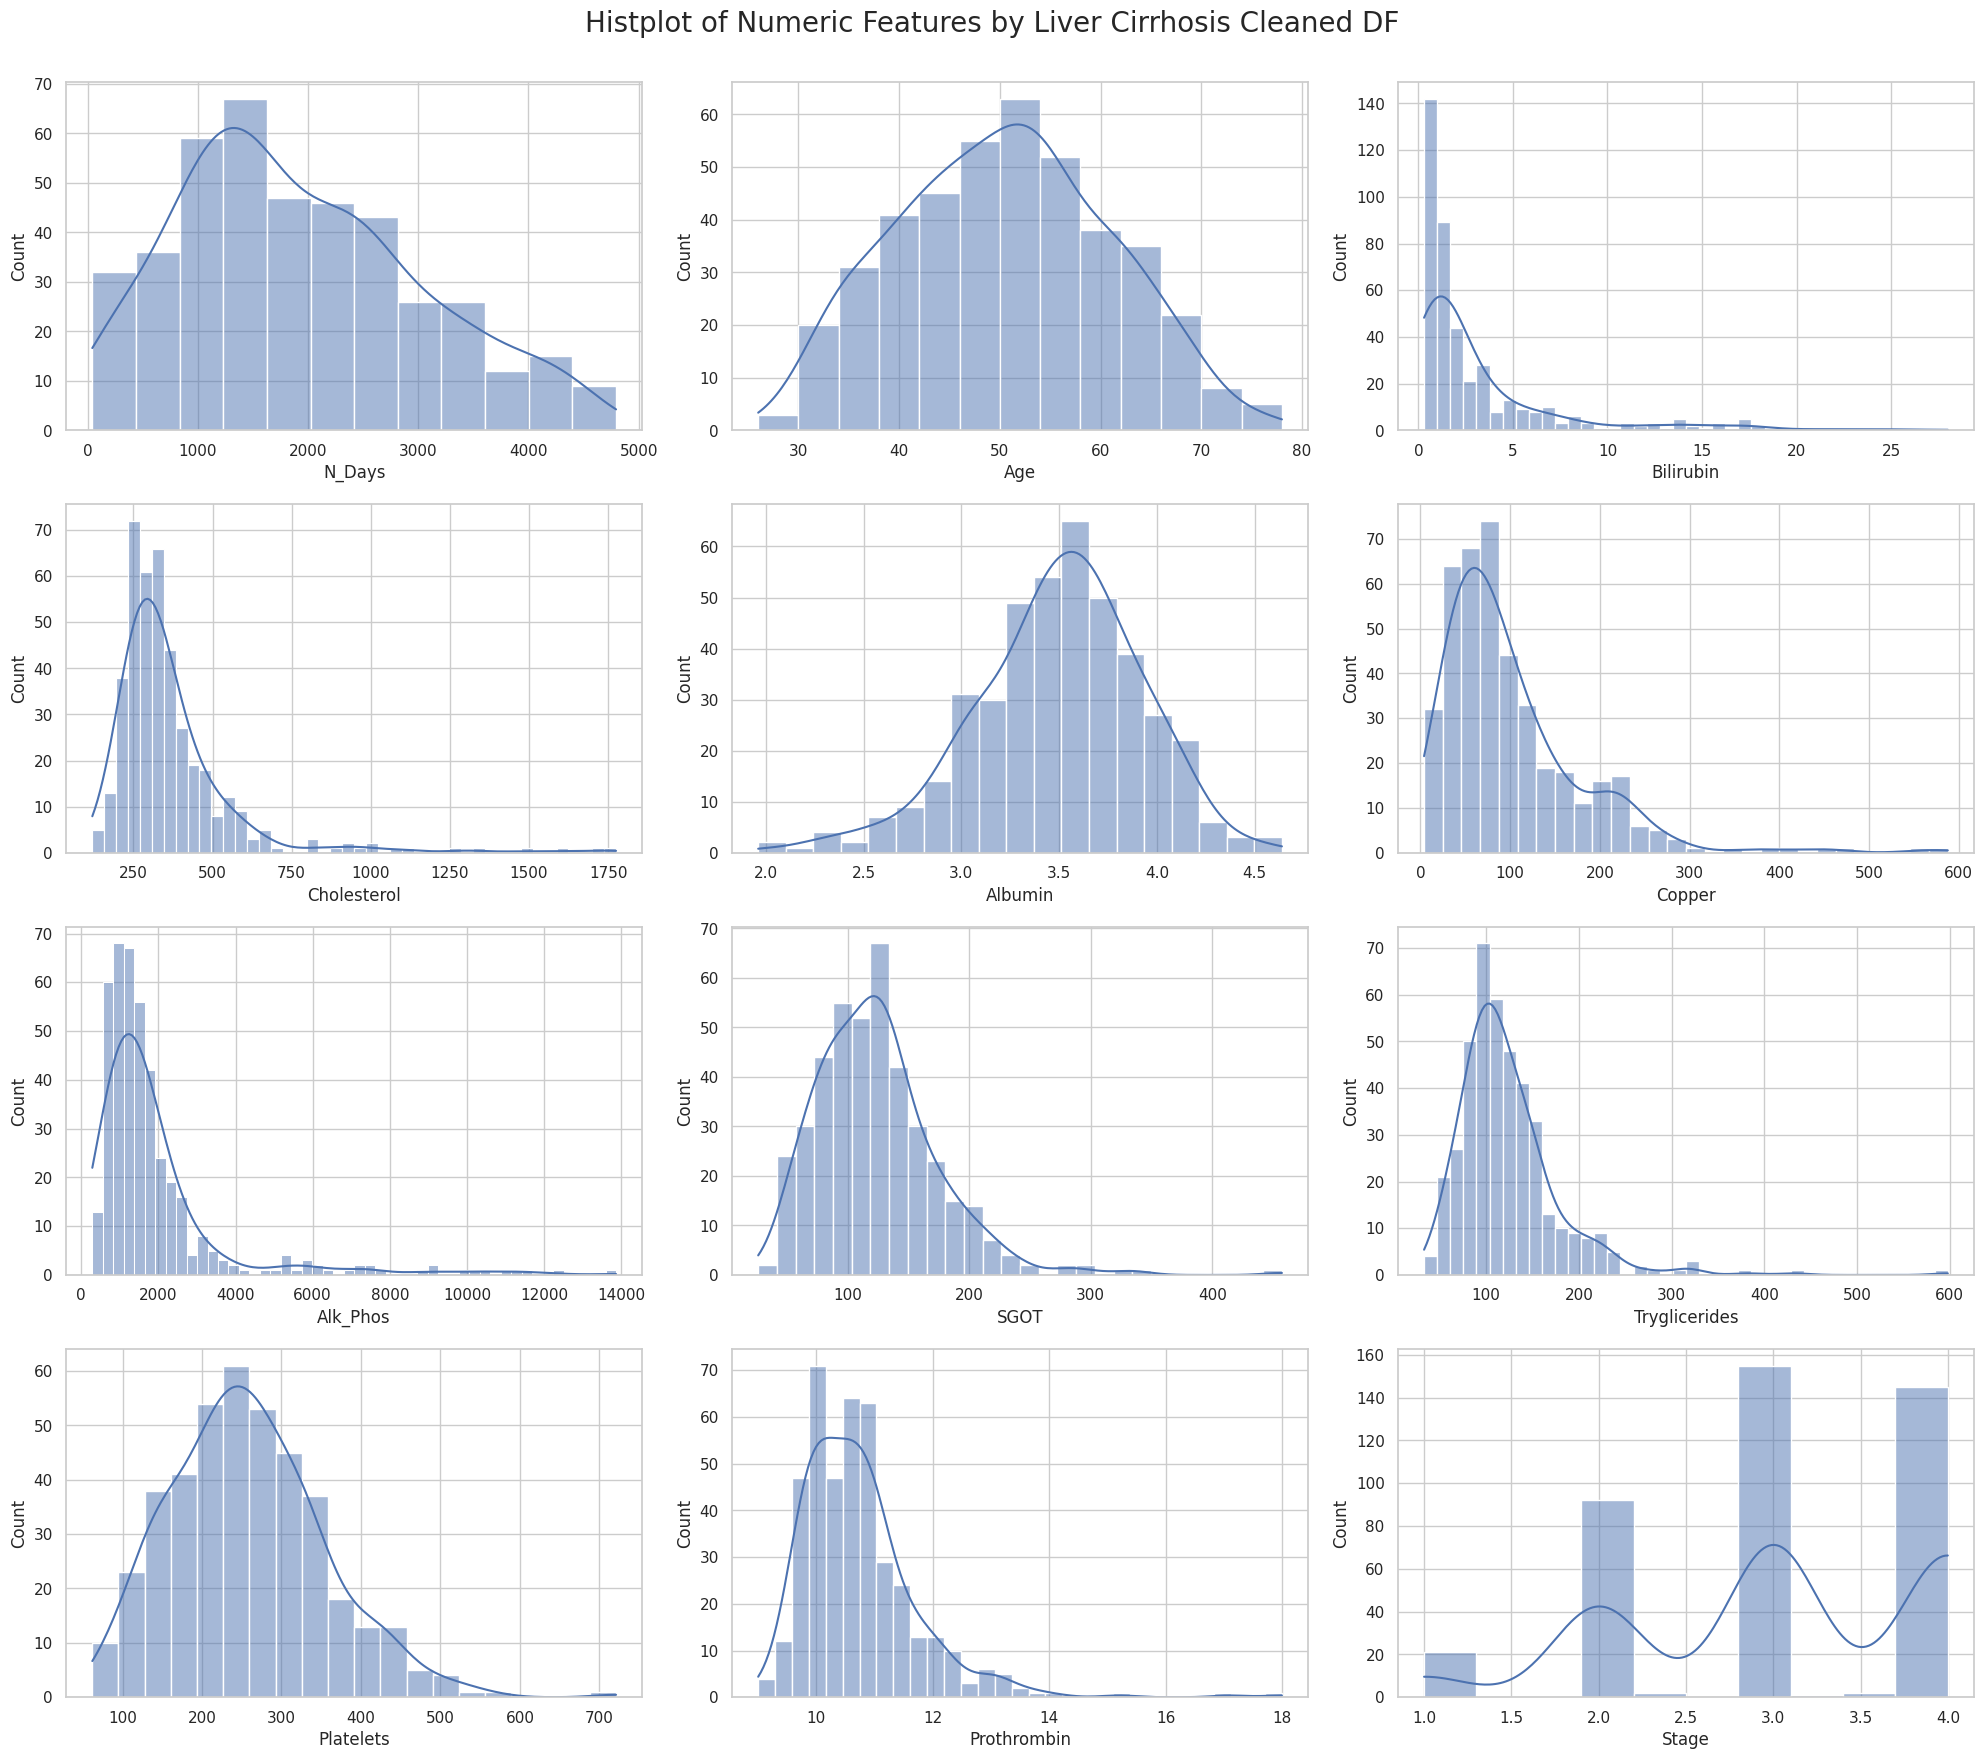

In [50]:
df_cleaned_num = df_cleaned.select_dtypes(include=['int64', 'float64'])
# Plot Histograms of numeric features
plt.figure(figsize=(20, 25))
for i, col in enumerate(df_cleaned_num):
    plt.subplot(6, 3, i + 1)
    sns.histplot(data=df_cleaned_num, x=col, palette='viridis', kde=True)
    # plt.title(f'{col} by Stage')
    plt.tight_layout()

plt.suptitle('Histplot of Numeric Features by Liver Cirrhosis Cleaned DF', fontsize=20, y=1.02)
plt.show()

## Outlier extraction for cleaned_df


Bilirubin: P1=0.40, P99=21.33
Outliers in Bilirubin: 8 rows

Copper: P1=11.00, P99=406.56
Outliers in Copper: 9 rows

SGOT: P1=43.67, P99=286.73
Outliers in SGOT: 10 rows

Cholesterol: P1=153.89, P99=1325.80
Outliers in Cholesterol: 10 rows

Alk_Phos: P1=415.53, P99=10936.13
Outliers in Alk_Phos: 10 rows

Tryglicerides: P1=49.17, P99=318.83
Outliers in Tryglicerides: 10 rows

Prothrombin: P1=9.32, P99=13.77
Outliers in Prothrombin: 10 rows

Platelets: P1=79.17, P99=516.49
Outliers in Platelets: 10 rows

Outlier DataFrame Shape: (66, 19)
No-Outlier DataFrame Shape: (352, 19)

Outliers DataFrame Descriptive Statistics:
       Bilirubin      Copper        SGOT  Cholesterol      Alk_Phos  \
count  66.000000   66.000000   66.000000    66.000000     66.000000   
mean    5.365152  130.563636  130.197515   441.039394   2769.268485   
std     7.354695  128.862192   83.622998   373.034143   3218.406851   
min     0.300000    4.000000   26.350000   120.000000    289.000000   
25%     0.700000   

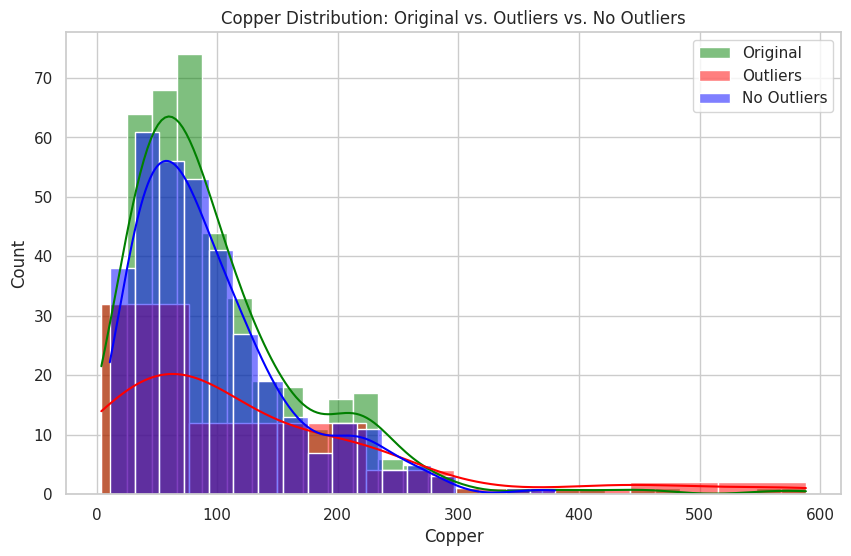

In [51]:
df = df_cleaned.copy()

# Define columns
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
cat_cols = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']
skewed_cols = ['Bilirubin', 'Copper', 'SGOT', 'Cholesterol', 'Alk_Phos', 'Tryglicerides', 'Prothrombin', 'Platelets']

# --- Identify Outliers (Percentile-Based Method) ---
outlier_mask = pd.DataFrame(False, index=df.index, columns=skewed_cols)
for col in skewed_cols:
    P1 = df[col].quantile(0.01)  # 1st percentile
    P99 = df[col].quantile(0.99) # 99th percentile
    print(f"\n{col}: P1={P1:.2f}, P99={P99:.2f}")
    outlier_mask[col] = (df[col] < P1) | (df[col] > P99)
    print(f"Outliers in {col}: {df[outlier_mask[col]].shape[0]} rows")

# Create DataFrames
df_outliers = df[outlier_mask.any(axis=1)].copy()
df_no_outliers = df[~outlier_mask.any(axis=1)].copy()
print(f"\nOutlier DataFrame Shape: {df_outliers.shape}")
print(f"No-Outlier DataFrame Shape: {df_no_outliers.shape}")

# --- Verify Outliers ---
print("\nOutliers DataFrame Descriptive Statistics:")
print(df_outliers[skewed_cols].describe())
print("\nNo-Outliers DataFrame Descriptive Statistics:")
print(df_no_outliers[skewed_cols].describe())

# --- Visualize Copper Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Copper'], kde=True, color='green', label='Original', alpha=0.5)
sns.histplot(df_outliers['Copper'], kde=True, color='red', label='Outliers', alpha=0.5)
sns.histplot(df_no_outliers['Copper'], kde=True, color='blue', label='No Outliers', alpha=0.5)
plt.title('Copper Distribution: Original vs. Outliers vs. No Outliers')
plt.legend()
plt.show()

## GAN Training

This first training was done with df dataset. The shape and desc of the dataset seen below.

In [52]:
df.shape

(418, 19)

In [53]:
df.isnull().sum()

N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64

2026-01-19 04:20:35.778558: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Epoch 0, D Loss: 0.5599595308303833, G Loss: 0.7232155799865723
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━

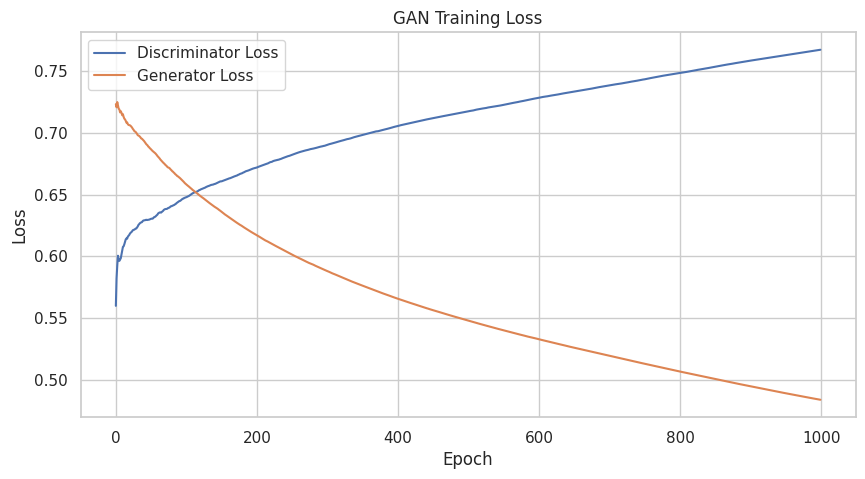

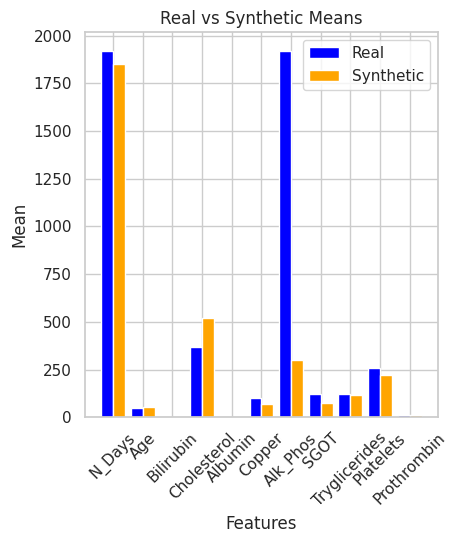

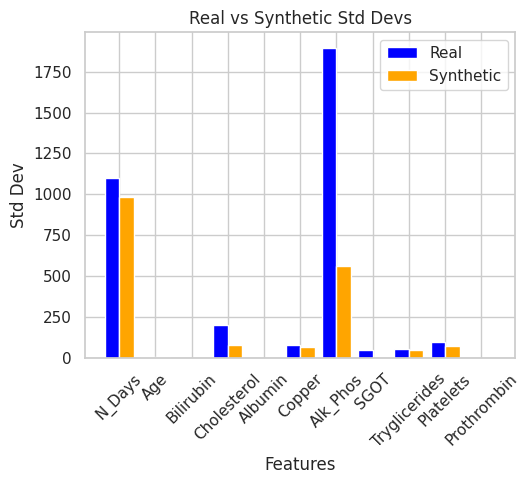


Proxy FID Score: 4494154.84

Real Data Stats (first 5 samples):
           N_Days        Age  Bilirubin  Cholesterol   Albumin      Copper  \
count     5.00000   5.000000   5.000000     5.000000  5.000000    5.000000   
mean   1868.20000  55.200000   4.440000   252.400000  3.258000  125.400000   
std    1577.25464  11.454257   5.693242    47.825725  0.680015   65.709969   
min     400.00000  38.000000   1.100000   176.000000  2.540000   54.000000   
25%    1012.00000  54.000000   1.400000   244.000000  2.600000   64.000000   
50%    1504.00000  56.000000   1.800000   261.000000  3.480000  143.000000   
75%    1925.00000  58.000000   3.400000   279.000000  3.530000  156.000000   
max    4500.00000  70.000000  14.500000   302.000000  4.140000  210.000000   

          Alk_Phos        SGOT  Tryglicerides   Platelets  Prothrombin  
count     5.000000    5.000000       5.000000    5.000000     5.000000  
mean   3284.320000  104.270000      95.800000  176.200000    11.200000  
std    3236.2

In [54]:
# Define columns
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
cat_cols = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']

# --- Preprocessing ---
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Prepare data
X = df[num_cols + cat_cols].values
feature_dim = X.shape[1]

# --- GAN Architecture ---
def build_generator(latent_dim, feature_dim):
    model = Sequential([
        Dense(128, input_dim=latent_dim),
        LeakyReLU(alpha=0.2),
        BatchNormalization(momentum=0.8),
        Dense(256),
        LeakyReLU(alpha=0.2),
        BatchNormalization(momentum=0.8),
        Dense(feature_dim, activation='tanh')
    ])
    return model

def build_discriminator(feature_dim):
    model = Sequential([
        Dense(256, input_dim=feature_dim),
        LeakyReLU(alpha=0.2),
        Dense(128),
        LeakyReLU(alpha=0.2),
        Dense(1, activation='sigmoid')
    ])
    return model

# Compile models
latent_dim = 100
generator = build_generator(latent_dim, feature_dim)
discriminator = build_discriminator(feature_dim)
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy', metrics=['accuracy'])

discriminator.trainable = False
gan_input = Input(shape=(latent_dim,))
generated_data = generator(gan_input)
gan_output = discriminator(generated_data)
gan = Model(gan_input, gan_output)
gan.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

# --- Training Parameters ---
epochs = 1000
batch_size = 32
sample_interval = 50

# --- Training History ---
d_losses = []
g_losses = []

# --- Training Loop ---
for epoch in range(epochs):
    # Generate random noise
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_data = generator.predict(noise)
    
    # Select real samples
    idx = np.random.randint(0, X.shape[0], batch_size)
    real_data = X[idx]
    
    # Labels
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))
    
    # Train Discriminator
    d_loss_real = discriminator.train_on_batch(real_data, real_labels)
    d_loss_fake = discriminator.train_on_batch(gen_data, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real_labels)
    
    # Store losses
    d_losses.append(d_loss[0])
    g_losses.append(g_loss)
    
    if epoch % sample_interval == 0:
        print(f"Epoch {epoch}, D Loss: {d_loss[0]}, G Loss: {g_loss}")
        # Generate and save sample
        noise = np.random.normal(0, 1, (100, latent_dim))
        synthetic_data = generator.predict(noise)
        np.save(f'synthetic_data_epoch_{epoch}.npy', synthetic_data)

# --- Plot Training Progress ---
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.title('GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Visualization: Real vs Synthetic Stats ---
synthetic_data = np.load('synthetic_data_epoch_950.npy')  # Load last saved data
synthetic_data_num = scaler.inverse_transform(synthetic_data[:, :len(num_cols)])
real_data_num = scaler.inverse_transform(X[:, :len(num_cols)])

real_means = np.mean(real_data_num, axis=0)
syn_means = np.mean(synthetic_data_num, axis=0)
real_stds = np.std(real_data_num, axis=0)
syn_stds = np.std(synthetic_data_num, axis=0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(np.arange(len(num_cols)) - 0.2, real_means, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_means, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Mean')
plt.title('Real vs Synthetic Means')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
plt.bar(np.arange(len(num_cols)) - 0.2, real_stds, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_stds, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Std Dev')
plt.title('Real vs Synthetic Std Devs')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# --- Evaluation: Proxy FID Score ---
def calculate_fid(real_data, synthetic_data):
    mu1, sigma1 = np.mean(real_data, axis=0), np.cov(real_data.T)
    mu2, sigma2 = np.mean(synthetic_data, axis=0), np.cov(synthetic_data.T)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return fid

fid_score = calculate_fid(real_data_num, synthetic_data_num)
print(f"\nProxy FID Score: {fid_score:.2f}")

# --- Statistical Comparison ---
print("\nReal Data Stats (first 5 samples):")
print(pd.DataFrame(real_data_num[:5], columns=num_cols).describe())
print("\nSynthetic Data Stats (first 5 samples):")
print(pd.DataFrame(synthetic_data_num[:5], columns=num_cols).describe())

# GAN Training using cleaned dataframe

In [55]:
df_cleaned.shape

(418, 19)

In [56]:
df_cleaned.isnull().sum()

N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64

In [ ]:
# Define columns
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
cat_cols = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']

# --- Preprocessing ---
le = LabelEncoder()
for col in cat_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

scaler = StandardScaler()
df_cleaned[num_cols] = scaler.fit_transform(df_cleaned[num_cols])

# Prepare data
X = df_cleaned[num_cols + cat_cols].values
feature_dim = X.shape[1]

# --- GAN Architecture ---
def build_generator(latent_dim, feature_dim):
    model = Sequential([
        Dense(128, input_dim=latent_dim),
        LeakyReLU(alpha=0.2),
        BatchNormalization(momentum=0.8),
        Dense(256),
        LeakyReLU(alpha=0.2),
        BatchNormalization(momentum=0.8),
        Dense(feature_dim, activation='tanh')
    ])
    return model

def build_discriminator(feature_dim):
    model = Sequential([
        Dense(256, input_dim=feature_dim),
        LeakyReLU(alpha=0.2),
        Dense(128),
        LeakyReLU(alpha=0.2),
        Dense(1, activation='sigmoid')
    ])
    return model

# Compile models
latent_dim = 100
generator = build_generator(latent_dim, feature_dim)
discriminator = build_discriminator(feature_dim)
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy', metrics=['accuracy'])

discriminator.trainable = False
gan_input = Input(shape=(latent_dim,))
generated_data = generator(gan_input)
gan_output = discriminator(generated_data)
gan = Model(gan_input, gan_output)
gan.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

# --- Training Parameters ---
epochs = 1000
batch_size = 32
sample_interval = 50

# --- Training History ---
d_losses = []
g_losses = []

# --- Training Loop ---
for epoch in range(epochs):
    # Generate random noise
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_data = generator.predict(noise)
    
    # Select real samples
    idx = np.random.randint(0, X.shape[0], batch_size)
    real_data = X[idx]
    
    # Labels
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))
    
    # Train Discriminator
    d_loss_real = discriminator.train_on_batch(real_data, real_labels)
    d_loss_fake = discriminator.train_on_batch(gen_data, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real_labels)
    
    # Store losses
    d_losses.append(d_loss[0])
    g_losses.append(g_loss)
    
    if epoch % sample_interval == 0:
        print(f"Epoch {epoch}, D Loss: {d_loss[0]}, G Loss: {g_loss}")
        # Generate and save sample
        noise = np.random.normal(0, 1, (100, latent_dim))
        synthetic_data = generator.predict(noise)
        np.save(f'synthetic_data_epoch_{epoch}.npy', synthetic_data)

# --- Plot Training Progress ---
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.title('GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Visualization: Real vs Synthetic Stats ---
synthetic_data = np.load('synthetic_data_epoch_950.npy')  # Load last saved data
synthetic_data_num = scaler.inverse_transform(synthetic_data[:, :len(num_cols)])
real_data_num = scaler.inverse_transform(X[:, :len(num_cols)])

real_means = np.mean(real_data_num, axis=0)
syn_means = np.mean(synthetic_data_num, axis=0)
real_stds = np.std(real_data_num, axis=0)
syn_stds = np.std(synthetic_data_num, axis=0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(np.arange(len(num_cols)) - 0.2, real_means, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_means, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Mean')
plt.title('Real vs Synthetic Means')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
plt.bar(np.arange(len(num_cols)) - 0.2, real_stds, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_stds, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Std Dev')
plt.title('Real vs Synthetic Std Devs')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# --- Evaluation: Proxy FID Score ---
def calculate_fid(real_data, synthetic_data):
    mu1, sigma1 = np.mean(real_data, axis=0), np.cov(real_data.T)
    mu2, sigma2 = np.mean(synthetic_data, axis=0), np.cov(synthetic_data.T)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return fid

fid_score = calculate_fid(real_data_num, synthetic_data_num)
print(f"\nProxy FID Score: {fid_score:.2f}")

# --- Statistical Comparison ---
print("\nReal Data Stats (first 5 samples):")
print(pd.DataFrame(real_data_num[:5], columns=num_cols).describe())
print("\nSynthetic Data Stats (first 5 samples):")
print(pd.DataFrame(synthetic_data_num[:5], columns=num_cols).describe())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


## Implementing CTGAN

Training CTGAN on 418 samples with 19 features...


Gen. (-1.74) | Discrim. (1.51): 100%|██████████| 300/300 [05:12<00:00,  1.04s/it] 


Synthetic data saved to 'synthetic_data_ctgan.csv' with 1000 samples.

Proxy FID Score: 6.45

Real Data Stats (first 5 samples):
         N_Days       Age  Bilirubin  Cholesterol   Albumin    Copper  \
count  5.000000  5.000000   5.000000     5.000000  5.000000  5.000000   
mean  -0.044938  0.469027   0.276947    -0.570181 -0.564101  0.308062   
std    1.429513  1.095116   1.293263     0.235442  1.602059  0.829376   
min   -1.375612 -1.175427  -0.481759    -0.946291 -2.255651 -0.593132   
25%   -0.820938  0.354298  -0.413611    -0.611534 -2.114296 -0.466915   
50%   -0.375023  0.545513  -0.322748    -0.527844 -0.041088  0.530205   
75%    0.006542  0.736729   0.040704    -0.439232  0.076708  0.694288   
max    2.340341  1.884022   2.562152    -0.326005  1.513818  1.375863   

       Alk_Phos      SGOT  Tryglicerides  Platelets  Prothrombin  
count  5.000000  5.000000       5.000000   5.000000     5.000000  
mean   0.719563 -0.383631      -0.488642  -0.832643     0.456691  
std    1.708

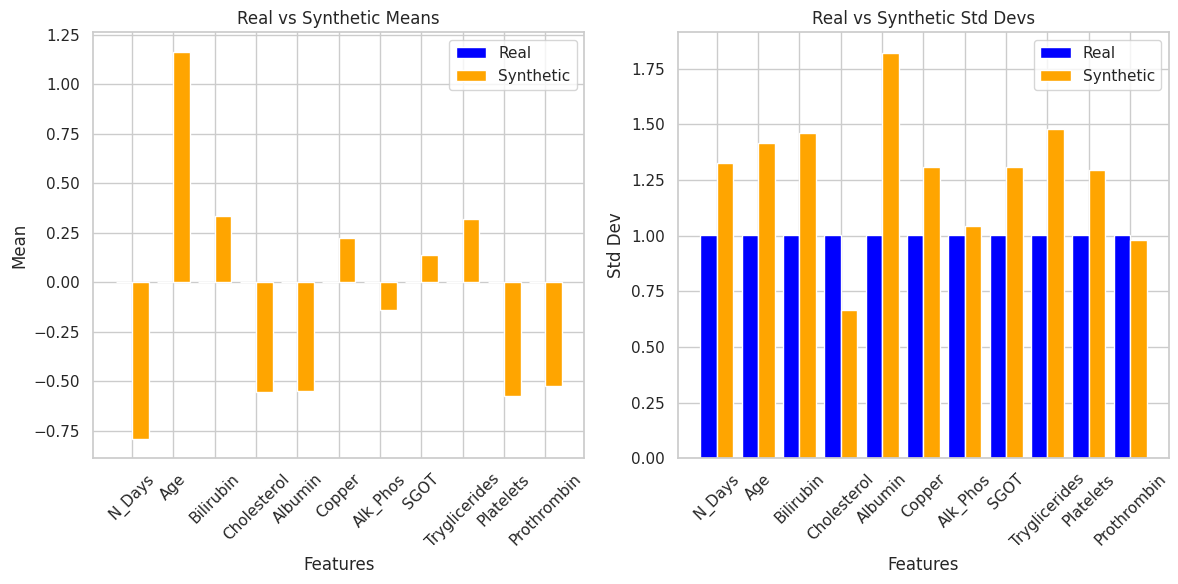

In [ ]:
# Assume df_cleaned is your imputed dataset
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 
            'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
cat_cols = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 
            'Edema', 'Stage']

# Preprocess the data
le = LabelEncoder()
for col in cat_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# Prepare data for CTGAN (raw form) and scaling for FID
data = df_cleaned[num_cols + cat_cols].copy()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[num_cols])  # Scale numerical columns for FID

# Initialize and train CTGAN with batch_size divisible by pac (default 10)
ctgan = CTGAN(epochs=300, batch_size=30, verbose=True)
print(f"Training CTGAN on {data.shape[0]} samples with {len(num_cols + cat_cols)} features...")
ctgan.fit(data, discrete_columns=cat_cols)

# Generate synthetic data
n_samples = 1000
synthetic_data = ctgan.sample(n_samples)

# Save the synthetic data
synthetic_data.to_csv('../data/gan/synthetic_data_ctgan.csv', index=False)
print(f"Synthetic data saved to 'synthetic_data_ctgan.csv' with {n_samples} samples.")

# Preprocess synthetic data for comparison
synthetic_data[num_cols] = scaler.transform(synthetic_data[num_cols])  # Apply the same scaling
synthetic_data_scaled = synthetic_data[num_cols].values

# Calculate FID score
def calculate_fid(real_data, synthetic_data):
    mu1, sigma1 = np.mean(real_data, axis=0), np.cov(real_data.T)
    mu2, sigma2 = np.mean(synthetic_data, axis=0), np.cov(synthetic_data.T)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))  # Changed np.sqrtm to scipy.linalg.sqrtm
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return fid

fid_score = calculate_fid(data_scaled, synthetic_data_scaled)
print(f"\nProxy FID Score: {fid_score:.2f}")

# Statistical Comparison
print("\nReal Data Stats (first 5 samples):")
print(pd.DataFrame(data_scaled[:5], columns=num_cols).describe())
print("\nSynthetic Data Stats (first 5 samples):")
print(pd.DataFrame(synthetic_data_scaled[:5], columns=num_cols).describe())

# Visualize some statistics
real_means = data[num_cols].mean()
syn_means = synthetic_data[num_cols].mean()
real_stds = data[num_cols].std()
syn_stds = synthetic_data[num_cols].std()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(np.arange(len(num_cols)) - 0.2, real_means, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_means, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Mean')
plt.title('Real vs Synthetic Means')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(np.arange(len(num_cols)) - 0.2, real_stds, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_stds, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Std Dev')
plt.title('Real vs Synthetic Std Devs')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Splitting Data into 2 sub groups

Loading first group

In [ ]:
first_group = pd.read_csv('first_group.csv')

In [ ]:
first_group_copy = first_group.copy()

In [ ]:
first_group_copy.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
first_group_copy.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,58,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,56,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,70,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,54,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,38,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [ ]:
first_group_copy.shape

(312, 19)

In [ ]:
first_group_copy.isnull().sum()

N_Days            0
Status            0
Drug              0
Age               0
Sex               0
Ascites           0
Hepatomegaly      0
Spiders           0
Edema             0
Bilirubin         0
Cholesterol      28
Albumin           0
Copper            2
Alk_Phos          0
SGOT              0
Tryglicerides    30
Platelets         4
Prothrombin       0
Stage             0
dtype: int64

In [ ]:
first_group_num = first_group_copy.select_dtypes(include=['int64', 'float64'])
first_group_cat = first_group_copy.select_dtypes(include=['object'])

In [ ]:
# --- Imputation ---
# Categorical: Mode
cat_cols = first_group_cat.columns
num_cols = first_group_num.columns
cat_imputer = SimpleImputer(strategy='most_frequent')
first_group_copy[cat_cols] = cat_imputer.fit_transform(first_group_copy[cat_cols])

# Numerical: KNN
knn_imputer = KNNImputer(n_neighbors=5)
first_group_copy[num_cols] = knn_imputer.fit_transform(first_group_copy[num_cols])

# --- Validation of Imputation ---
print("\nMissing Values After Imputation:")
print(first_group_copy.isnull().sum())


Missing Values After Imputation:
N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
Epoch 0, D Loss: 0.6726698279380798, G Loss: 0.6748741865158081
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━

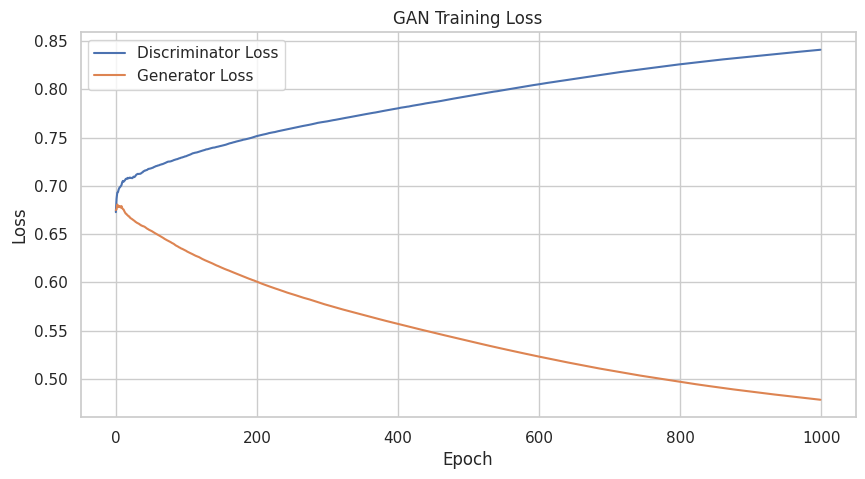

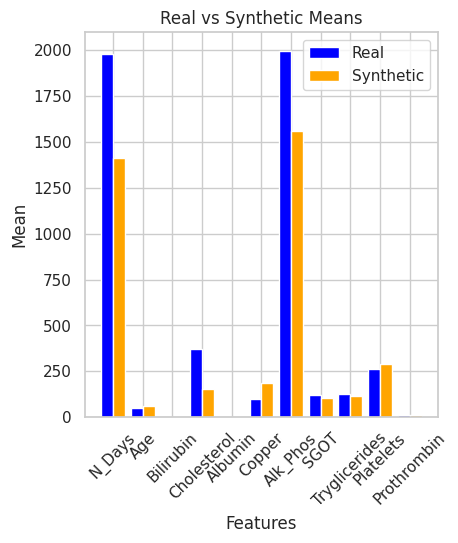

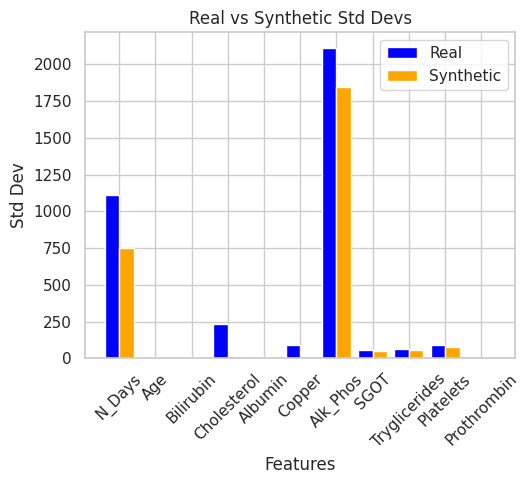


Proxy FID Score: 842946.94

Real Data Stats (first 5 samples):
           N_Days        Age  Bilirubin  Cholesterol   Albumin      Copper  \
count     5.00000   5.000000   5.000000     5.000000  5.000000    5.000000   
mean   1868.20000  55.200000   4.440000   252.400000  3.258000  125.400000   
std    1577.25464  11.454257   5.693242    47.825725  0.680015   65.709969   
min     400.00000  38.000000   1.100000   176.000000  2.540000   54.000000   
25%    1012.00000  54.000000   1.400000   244.000000  2.600000   64.000000   
50%    1504.00000  56.000000   1.800000   261.000000  3.480000  143.000000   
75%    1925.00000  58.000000   3.400000   279.000000  3.530000  156.000000   
max    4500.00000  70.000000  14.500000   302.000000  4.140000  210.000000   

          Alk_Phos        SGOT  Tryglicerides   Platelets  Prothrombin  
count     5.000000    5.000000       5.000000    5.000000     5.000000  
mean   3284.320000  104.270000      95.800000  176.200000    11.200000  
std    3236.26

In [ ]:
# Define columns
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
cat_cols = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']

# --- Preprocessing ---
le = LabelEncoder()
for col in cat_cols:
    first_group_copy[col] = le.fit_transform(first_group_copy[col].astype(str))

scaler = StandardScaler()
first_group_copy[num_cols] = scaler.fit_transform(first_group_copy[num_cols])

# Prepare data
X = first_group_copy[num_cols + cat_cols].values
feature_dim = X.shape[1]

# --- GAN Architecture ---
def build_generator(latent_dim, feature_dim):
    model = Sequential([
        Dense(128, input_dim=latent_dim),
        LeakyReLU(alpha=0.2),
        BatchNormalization(momentum=0.8),
        Dense(256),
        LeakyReLU(alpha=0.2),
        BatchNormalization(momentum=0.8),
        Dense(feature_dim, activation='tanh')
    ])
    return model

def build_discriminator(feature_dim):
    model = Sequential([
        Dense(256, input_dim=feature_dim),
        LeakyReLU(alpha=0.2),
        Dense(128),
        LeakyReLU(alpha=0.2),
        Dense(1, activation='sigmoid')
    ])
    return model

# Compile models
latent_dim = 100
generator = build_generator(latent_dim, feature_dim)
discriminator = build_discriminator(feature_dim)
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy', metrics=['accuracy'])

discriminator.trainable = False
gan_input = Input(shape=(latent_dim,))
generated_data = generator(gan_input)
gan_output = discriminator(generated_data)
gan = Model(gan_input, gan_output)
gan.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

# --- Training Parameters ---
epochs = 1000
batch_size = 32
sample_interval = 50

# --- Training History ---
d_losses = []
g_losses = []

# --- Training Loop ---
for epoch in range(epochs):
    # Generate random noise
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_data = generator.predict(noise)
    
    # Select real samples
    idx = np.random.randint(0, X.shape[0], batch_size)
    real_data = X[idx]
    
    # Labels
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))
    
    # Train Discriminator
    d_loss_real = discriminator.train_on_batch(real_data, real_labels)
    d_loss_fake = discriminator.train_on_batch(gen_data, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real_labels)
    
    # Store losses
    d_losses.append(d_loss[0])
    g_losses.append(g_loss)
    
    if epoch % sample_interval == 0:
        print(f"Epoch {epoch}, D Loss: {d_loss[0]}, G Loss: {g_loss}")
        # Generate and save sample
        noise = np.random.normal(0, 1, (100, latent_dim))
        synthetic_data = generator.predict(noise)
        np.save(f'synthetic_data_epoch_{epoch}.npy', synthetic_data)

# --- Plot Training Progress ---
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.title('GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Visualization: Real vs Synthetic Stats ---
synthetic_data = np.load('synthetic_data_epoch_950.npy')  # Load last saved data
synthetic_data_num = scaler.inverse_transform(synthetic_data[:, :len(num_cols)])
real_data_num = scaler.inverse_transform(X[:, :len(num_cols)])

real_means = np.mean(real_data_num, axis=0)
syn_means = np.mean(synthetic_data_num, axis=0)
real_stds = np.std(real_data_num, axis=0)
syn_stds = np.std(synthetic_data_num, axis=0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(np.arange(len(num_cols)) - 0.2, real_means, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_means, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Mean')
plt.title('Real vs Synthetic Means')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
plt.bar(np.arange(len(num_cols)) - 0.2, real_stds, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_stds, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Std Dev')
plt.title('Real vs Synthetic Std Devs')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# --- Evaluation: Proxy FID Score ---
def calculate_fid(real_data, synthetic_data):
    mu1, sigma1 = np.mean(real_data, axis=0), np.cov(real_data.T)
    mu2, sigma2 = np.mean(synthetic_data, axis=0), np.cov(synthetic_data.T)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return fid

fid_score = calculate_fid(real_data_num, synthetic_data_num)
print(f"\nProxy FID Score: {fid_score:.2f}")

# --- Statistical Comparison ---
print("\nReal Data Stats (first 5 samples):")
print(pd.DataFrame(real_data_num[:5], columns=num_cols).describe())
print("\nSynthetic Data Stats (first 5 samples):")
print(pd.DataFrame(synthetic_data_num[:5], columns=num_cols).describe())

# Implementing CTGAN on first group

Training CTGAN on 276 samples with 19 features...


Gen. (-2.14) | Discrim. (-0.33): 100%|██████████| 300/300 [03:43<00:00,  1.34it/s]


Synthetic data saved to 'synthetic_data_ctgan.csv' with 1000 samples.

Proxy FID Score: 6.59

Real Data Stats (first 5 samples):
         N_Days       Age  Bilirubin  Cholesterol   Albumin    Copper  \
count  5.000000  5.000000   5.000000     5.000000  5.000000  5.000000   
mean  -0.099937  0.564536   0.240882    -0.507166 -0.640536  0.279562   
std    1.420485  1.092769   1.239620     0.204067  1.682977  0.745783   
min   -1.422207 -1.076394  -0.486355    -0.833157 -2.417524 -0.530800   
25%   -0.871036  0.450053  -0.421034    -0.543008 -2.269029 -0.417304   
50%   -0.427938  0.640859  -0.333940    -0.470471 -0.091105  0.479316   
75%   -0.048783  0.831664   0.014437    -0.393667  0.032640  0.626861   
max    2.270278  1.976499   2.431300    -0.295529  1.542337  1.239740   

       Alk_Phos      SGOT  Tryglicerides  Platelets  Prothrombin  
count  5.000000  5.000000       5.000000   5.000000     5.000000  
mean   0.609814 -0.350587      -0.447778  -0.920522     0.461499  
std    1.532

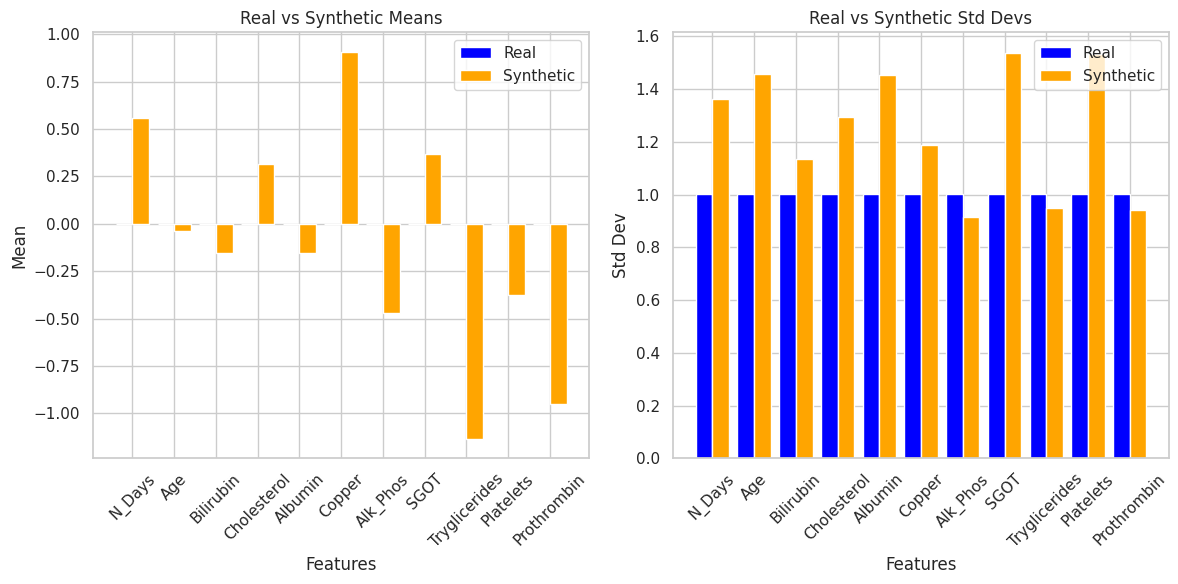

In [ ]:
# Assume df_cleaned is your imputed dataset
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 
            'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
cat_cols = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 
            'Edema', 'Stage']

# Preprocess the data
le = LabelEncoder()
for col in cat_cols:
    first_group_copy[col] = le.fit_transform(first_group_copy[col].astype(str))

# Prepare data for CTGAN (raw form) and scaling for FID
data = first_group_copy[num_cols + cat_cols].copy()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[num_cols])  # Scale numerical columns for FID

# Initialize and train CTGAN with batch_size divisible by pac (default 10)
ctgan = CTGAN(epochs=300, batch_size=30, verbose=True)
print(f"Training CTGAN on {data.shape[0]} samples with {len(num_cols + cat_cols)} features...")
ctgan.fit(data, discrete_columns=cat_cols)

# Generate synthetic data
n_samples = 1000
synthetic_data = ctgan.sample(n_samples)

# Save the synthetic data
synthetic_data.to_csv('../data/gan/synthetic_data_ctgan_group1.csv', index=False)
print(f"Synthetic data saved to 'synthetic_data_ctgan.csv' with {n_samples} samples.")

# Preprocess synthetic data for comparison
synthetic_data[num_cols] = scaler.transform(synthetic_data[num_cols])  # Apply the same scaling
synthetic_data_scaled = synthetic_data[num_cols].values

# Calculate FID score
def calculate_fid(real_data, synthetic_data):
    mu1, sigma1 = np.mean(real_data, axis=0), np.cov(real_data.T)
    mu2, sigma2 = np.mean(synthetic_data, axis=0), np.cov(synthetic_data.T)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))  # Changed np.sqrtm to scipy.linalg.sqrtm
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return fid

fid_score = calculate_fid(data_scaled, synthetic_data_scaled)
print(f"\nProxy FID Score: {fid_score:.2f}")

# Statistical Comparison
print("\nReal Data Stats (first 5 samples):")
print(pd.DataFrame(data_scaled[:5], columns=num_cols).describe())
print("\nSynthetic Data Stats (first 5 samples):")
print(pd.DataFrame(synthetic_data_scaled[:5], columns=num_cols).describe())

# Visualize some statistics
real_means = data[num_cols].mean()
syn_means = synthetic_data[num_cols].mean()
real_stds = data[num_cols].std()
syn_stds = synthetic_data[num_cols].std()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(np.arange(len(num_cols)) - 0.2, real_means, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_means, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Mean')
plt.title('Real vs Synthetic Means')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(np.arange(len(num_cols)) - 0.2, real_stds, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_stds, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Std Dev')
plt.title('Real vs Synthetic Std Devs')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
second_group = pd.read_csv("second_group.csv")

In [ ]:
second_group_copy = second_group.copy()

In [ ]:
second_group_copy.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
second_group_copy.isnull().sum()

N_Days         0
Status         0
Age            0
Sex            0
Edema          0
Bilirubin      0
Albumin        0
Platelets      7
Prothrombin    2
Stage          6
dtype: int64

# Dropping NAs

In [ ]:
second_group_copy.drop(columns=['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides'], inplace=True)

In [ ]:
second_group_copy.head()

,N_Days,Status,Age,Sex,Edema,Bilirubin,Albumin,Platelets,Prothrombin,Stage
0,4062,C,60,F,N,0.7,3.65,378.0,11.0,NaN
1,3561,D,64,F,S,1.4,3.04,331.0,12.1,4.0
2,2844,C,54,F,N,0.7,4.03,226.0,9.8,4.0
3,2071,D,75,F,S,0.7,3.96,NaN,11.3,4.0
4,3030,C,62,F,N,0.8,2.48,273.0,10.0,NaN


In [ ]:
second_group_copy.shape

(106, 10)

In [ ]:
second_group_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N_Days       106 non-null    int64  
 1   Status       106 non-null    object 
 2   Age          106 non-null    int64  
 3   Sex          106 non-null    object 
 4   Edema        106 non-null    object 
 5   Bilirubin    106 non-null    float64
 6   Albumin      106 non-null    float64
 7   Platelets    99 non-null     float64
 8   Prothrombin  104 non-null    float64
 9   Stage        100 non-null    float64
dtypes: float64(5), int64(2), object(3)
memory usage: 8.4+ KB


In [ ]:
second_group_num = second_group_copy.select_dtypes(include=['int64', 'float64'])


In [ ]:
# --- Imputation ---
num_cols = second_group_num.columns

# Numerical: KNN
knn_imputer = KNNImputer(n_neighbors=5)
second_group_copy[num_cols] = knn_imputer.fit_transform(second_group_copy[num_cols])

# --- Validation of Imputation ---
print("\nMissing Values After Imputation:")
print(second_group_copy.isnull().sum())


Missing Values After Imputation:
N_Days         0
Status         0
Age            0
Sex            0
Edema          0
Bilirubin      0
Albumin        0
Platelets      0
Prothrombin    0
Stage          0
dtype: int64


# GAN Training Second Group

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
Epoch 0, D Loss: 0.7258380055427551, G Loss: 0.7935380935668945
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━

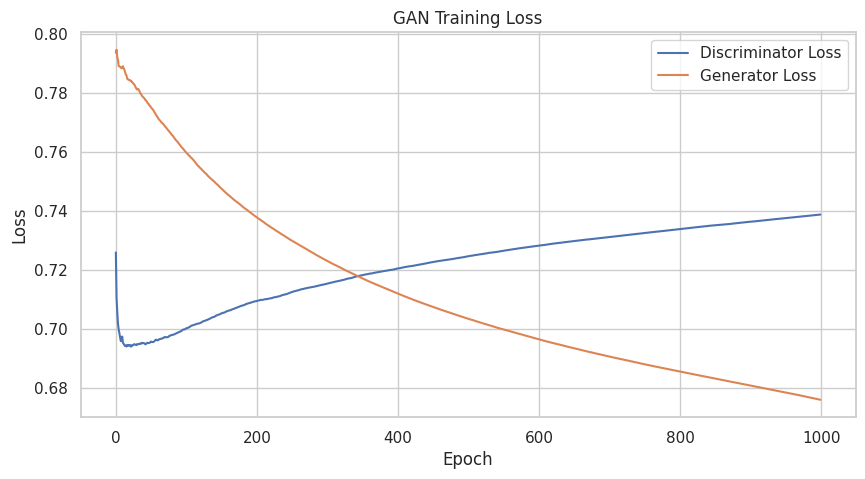

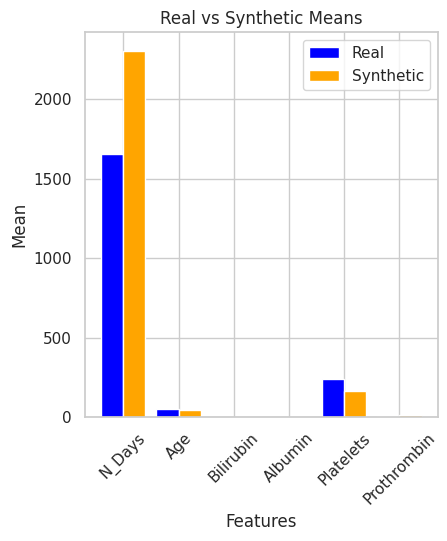

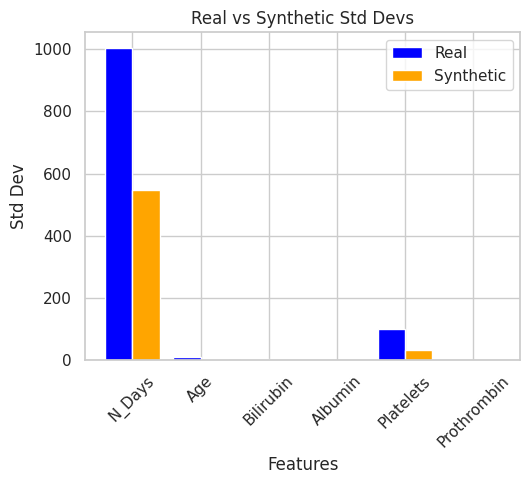


Proxy FID Score: 644693.52

Real Data Stats (first 5 samples):
            N_Days        Age  Bilirubin  Albumin   Platelets  Prothrombin
count     5.000000   5.000000   5.000000  5.00000    5.000000     5.000000
mean   3113.600000  63.000000   0.860000  3.43200  285.760000    10.840000
std     752.714621   7.681146   0.304959  0.66028   68.023437     0.950263
min    2071.000000  54.000000   0.700000  2.48000  220.800000     9.800000
25%    2844.000000  60.000000   0.700000  3.04000  226.000000    10.000000
50%    3030.000000  62.000000   0.700000  3.65000  273.000000    11.000000
75%    3561.000000  64.000000   0.800000  3.96000  331.000000    11.300000
max    4062.000000  75.000000   1.400000  4.03000  378.000000    12.100000

Synthetic Data Stats (first 5 samples):
            N_Days        Age  Bilirubin   Albumin   Platelets  Prothrombin
count     5.000000   5.000000   5.000000  5.000000    5.000000     5.000000
mean   2522.892334  43.530640   4.437806  3.108422  152.959091    11

In [ ]:
# Define columns
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Albumin', 'Platelets', 'Prothrombin']
cat_cols = ['Status', 'Sex', 'Edema', 'Stage']

# --- Preprocessing ---
le = LabelEncoder()
for col in cat_cols:
    second_group_copy[col] = le.fit_transform(second_group_copy[col].astype(str))

scaler = StandardScaler()
second_group_copy[num_cols] = scaler.fit_transform(second_group_copy[num_cols])

# Prepare data
X = second_group_copy[num_cols + cat_cols].values
feature_dim = X.shape[1]

# --- GAN Architecture ---
def build_generator(latent_dim, feature_dim):
    model = Sequential([
        Dense(128, input_dim=latent_dim),
        LeakyReLU(alpha=0.2),
        BatchNormalization(momentum=0.8),
        Dense(256),
        LeakyReLU(alpha=0.2),
        BatchNormalization(momentum=0.8),
        Dense(feature_dim, activation='tanh')
    ])
    return model

def build_discriminator(feature_dim):
    model = Sequential([
        Dense(256, input_dim=feature_dim),
        LeakyReLU(alpha=0.2),
        Dense(128),
        LeakyReLU(alpha=0.2),
        Dense(1, activation='sigmoid')
    ])
    return model

# Compile models
latent_dim = 100
generator = build_generator(latent_dim, feature_dim)
discriminator = build_discriminator(feature_dim)
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy', metrics=['accuracy'])

discriminator.trainable = False
gan_input = Input(shape=(latent_dim,))
generated_data = generator(gan_input)
gan_output = discriminator(generated_data)
gan = Model(gan_input, gan_output)
gan.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

# --- Training Parameters ---
epochs = 1000
batch_size = 32
sample_interval = 50

# --- Training History ---
d_losses = []
g_losses = []

# --- Training Loop ---
for epoch in range(epochs):
    # Generate random noise
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_data = generator.predict(noise)
    
    # Select real samples
    idx = np.random.randint(0, X.shape[0], batch_size)
    real_data = X[idx]
    
    # Labels
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))
    
    # Train Discriminator
    d_loss_real = discriminator.train_on_batch(real_data, real_labels)
    d_loss_fake = discriminator.train_on_batch(gen_data, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real_labels)
    
    # Store losses
    d_losses.append(d_loss[0])
    g_losses.append(g_loss)
    
    if epoch % sample_interval == 0:
        print(f"Epoch {epoch}, D Loss: {d_loss[0]}, G Loss: {g_loss}")
        # Generate and save sample
        noise = np.random.normal(0, 1, (100, latent_dim))
        synthetic_data = generator.predict(noise)
        np.save(f'synthetic_data_epoch_{epoch}.npy', synthetic_data)

# --- Plot Training Progress ---
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.title('GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Visualization: Real vs Synthetic Stats ---
synthetic_data = np.load('synthetic_data_epoch_950.npy')  # Load last saved data
synthetic_data_num = scaler.inverse_transform(synthetic_data[:, :len(num_cols)])
real_data_num = scaler.inverse_transform(X[:, :len(num_cols)])

real_means = np.mean(real_data_num, axis=0)
syn_means = np.mean(synthetic_data_num, axis=0)
real_stds = np.std(real_data_num, axis=0)
syn_stds = np.std(synthetic_data_num, axis=0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(np.arange(len(num_cols)) - 0.2, real_means, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_means, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Mean')
plt.title('Real vs Synthetic Means')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
plt.bar(np.arange(len(num_cols)) - 0.2, real_stds, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_stds, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Std Dev')
plt.title('Real vs Synthetic Std Devs')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# --- Evaluation: Proxy FID Score ---
def calculate_fid(real_data, synthetic_data):
    mu1, sigma1 = np.mean(real_data, axis=0), np.cov(real_data.T)
    mu2, sigma2 = np.mean(synthetic_data, axis=0), np.cov(synthetic_data.T)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return fid

fid_score = calculate_fid(real_data_num, synthetic_data_num)
print(f"\nProxy FID Score: {fid_score:.2f}")

# --- Statistical Comparison ---
print("\nReal Data Stats (first 5 samples):")
print(pd.DataFrame(real_data_num[:5], columns=num_cols).describe())
print("\nSynthetic Data Stats (first 5 samples):")
print(pd.DataFrame(synthetic_data_num[:5], columns=num_cols).describe())

# Implementing CTGAN on Second Group

Training CTGAN on 106 samples with 10 features...


Gen. (-0.96) | Discrim. (0.05): 100%|██████████| 300/300 [00:58<00:00,  5.15it/s] 


Synthetic data saved to 'synthetic_data_ctgan.csv' with 1000 samples.

Proxy FID Score: 6.23

Real Data Stats (first 5 samples):
         N_Days       Age  Bilirubin   Albumin  Platelets  Prothrombin
count  5.000000  5.000000   5.000000  5.000000   5.000000     5.000000
mean   1.451044  1.057594  -0.560903  0.002224   0.437703     0.083081
std    0.749872  0.784954   0.075788  1.525728   0.669910     0.890274
min    0.412380  0.137863  -0.600667 -2.197589  -0.202037    -0.891265
25%    1.182462  0.751017  -0.600667 -0.903582  -0.150826    -0.703891
50%    1.367759  0.955401  -0.600667  0.505962   0.312040     0.232980
75%    1.896754  1.159786  -0.575815  1.222288   0.883237     0.514042
max    2.395862  2.283901  -0.426703  1.384039   1.346103     1.263539

Synthetic Data Stats (first 5 samples):
         N_Days       Age  Bilirubin   Albumin  Platelets  Prothrombin
count  5.000000  5.000000   5.000000  5.000000   5.000000     5.000000
mean  -1.098537 -0.788646  -0.028822  1.253546   

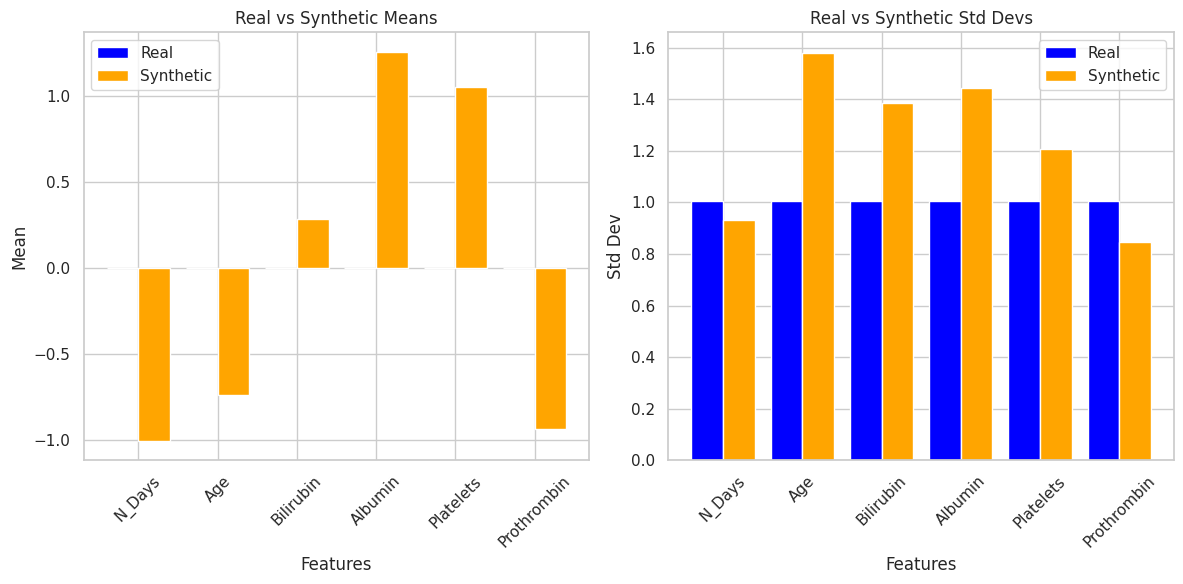

In [ ]:
# Define columns
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Albumin', 'Platelets', 'Prothrombin']
cat_cols = ['Status', 'Sex', 'Edema', 'Stage']

# Preprocess the data
le = LabelEncoder()
for col in cat_cols:
    second_group_copy[col] = le.fit_transform(second_group_copy[col].astype(str))

# Prepare data for CTGAN (raw form) and scaling for FID
data = second_group_copy[num_cols + cat_cols].copy()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[num_cols])  # Scale numerical columns for FID

# Initialize and train CTGAN with batch_size divisible by pac (default 10)
ctgan = CTGAN(epochs=300, batch_size=30, verbose=True)
print(f"Training CTGAN on {data.shape[0]} samples with {len(num_cols + cat_cols)} features...")
ctgan.fit(data, discrete_columns=cat_cols)

# Generate synthetic data
n_samples = 1000
synthetic_data = ctgan.sample(n_samples)

# Save the synthetic data
synthetic_data.to_csv('../data/gan/synthetic_data_ctgan_group2.csv', index=False)
print(f"Synthetic data saved to 'synthetic_data_ctgan.csv' with {n_samples} samples.")

# Preprocess synthetic data for comparison
synthetic_data[num_cols] = scaler.transform(synthetic_data[num_cols])  # Apply the same scaling
synthetic_data_scaled = synthetic_data[num_cols].values

# Calculate FID score
def calculate_fid(real_data, synthetic_data):
    mu1, sigma1 = np.mean(real_data, axis=0), np.cov(real_data.T)
    mu2, sigma2 = np.mean(synthetic_data, axis=0), np.cov(synthetic_data.T)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))  # Changed np.sqrtm to scipy.linalg.sqrtm
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return fid

fid_score = calculate_fid(data_scaled, synthetic_data_scaled)
print(f"\nProxy FID Score: {fid_score:.2f}")

# Statistical Comparison
print("\nReal Data Stats (first 5 samples):")
print(pd.DataFrame(data_scaled[:5], columns=num_cols).describe())
print("\nSynthetic Data Stats (first 5 samples):")
print(pd.DataFrame(synthetic_data_scaled[:5], columns=num_cols).describe())

# Visualize some statistics
real_means = data[num_cols].mean()
syn_means = synthetic_data[num_cols].mean()
real_stds = data[num_cols].std()
syn_stds = synthetic_data[num_cols].std()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(np.arange(len(num_cols)) - 0.2, real_means, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_means, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Mean')
plt.title('Real vs Synthetic Means')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(np.arange(len(num_cols)) - 0.2, real_stds, 0.4, label='Real', color='blue')
plt.bar(np.arange(len(num_cols)) + 0.2, syn_stds, 0.4, label='Synthetic', color='orange')
plt.xlabel('Features')
plt.ylabel('Std Dev')
plt.title('Real vs Synthetic Std Devs')
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()